In [ ]:
!pip install uncertainties
!pip install adjustText

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 2.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from scipy.odr import ODR, Model, RealData
import matplotlib.pyplot as plt
import numpy as np
from scipy import optimize
from numpy import linalg, tan,sqrt, pi,cos,sin,exp
from numpy import linspace, array,zeros,arange,append,nan
import uncertainties as unc
from uncertainties import unumpy as unp
from matplotlib.font_manager import FontProperties
from adjustText import adjust_text

In [ ]:
def Absorbancia(I, I_0):
  return -np.log10(I/I_0)

In [ ]:
def ajustar_gaussiana(data, rango_x, beta0, guardar=False, graficar=True, label='Datos Experimentales'):
    """Realiza el ajuste de dos gaussianas para un archivo de datos dado."""

    # Leer datos
    x = data['Longitud de onda'].values[rango_x[0]:rango_x[1]]
    y = data['A'].values[rango_x[0]:rango_x[1]]
    #errx = np.full_like(x, 0.1)
    #erry = np.where(y <= 0.5, 0.002, np.where(y <= 1.0, 0.003, 0.006))

    # Normalizar la gaussiana
    min_abs = np.min(y)
    y = y - min_abs
    max_abs = np.max(y)
    y = y/max_abs

    # Definir modelo
    def gaussiana(params, x):
        A, mu, sigma = params
        return  A * np.exp(-((x - mu) / sigma)**2 / 2)

    # Configurar y ejecutar ODR
    data = RealData(x, y)
    model = Model(gaussiana)
    odr_instance = ODR(data, model, beta0=beta0)
    output = odr_instance.run()

    # Resultados
    params = output.beta
    param_errors = output.sd_beta

    print("\nParámetros ajustados y sus incertezas:")
    param_names = ['A', 'mu', 'sigma']
    for name, value, error in zip(param_names, params, param_errors):
        print(f"{name}: {value:.4f} ± {error:.4f}")

    if graficar==True:
    # Graficar resultados
      x_fit = np.linspace(min(x), max(x), 100)
      y_fit = gaussiana(params, x_fit)

      plt.figure(figsize=(10, 6))
      plt.errorbar(x, y,
                 fmt='o', capsize=5, label=label)
      plt.plot(x_fit, y_fit, 'r-', label='Ajuste de la gaussiana')
      plt.xticks(fontsize=17)
      plt.yticks(fontsize=17)
      plt.xlabel('Longitud de onda (nm)', size=20)
      plt.ylabel('Absorbancia (a.u.)', size=20)
      plt.legend(fontsize=21, loc="lower right")
      plt.grid(True)
      if guardar==True:
        plt.savefig('Ajuste_gaussiana.pdf', dpi=300)

      plt.show()


    return params, param_errors

In [ ]:
#Obtener datos del csv

datos1 = pd.read_csv('data_series_1.csv')
datos2 = pd.read_csv('data_series_2.csv')
datos_ref = pd.read_csv('references.csv')
datos_ref.drop(3, inplace=True)
datos_ref.reset_index(inplace=True)

df_NaCl = pd.DataFrame()
df_KCl = pd.DataFrame()
df_KBr = pd.DataFrame()
df_KI = pd.DataFrame()

for df in (df_NaCl, df_KCl, df_KBr, df_KI):
  df['Longitud de onda'] = datos1['Wavelength']

df_NaCl['A'] = Absorbancia(datos1['I(NaCl)'], datos1['I(0)'])
df_KCl['A'] = Absorbancia(datos1['I(KCl)'], datos1['I(0)'])
df_KBr['A'] = Absorbancia(datos2['I(KBr)'], datos2['I(0)'])
df_KI['A'] = Absorbancia(datos2['I(KI)'], datos2['I(0)'])

df_Li = datos_ref[:4]
df_Na = datos_ref[4:8]
df_K = datos_ref[8:]

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)



Parámetros ajustados y sus incertezas:
A: 0.8352 ± 0.0046
mu: 460.4317 ± 0.2775
sigma: 43.4784 ± 0.2848


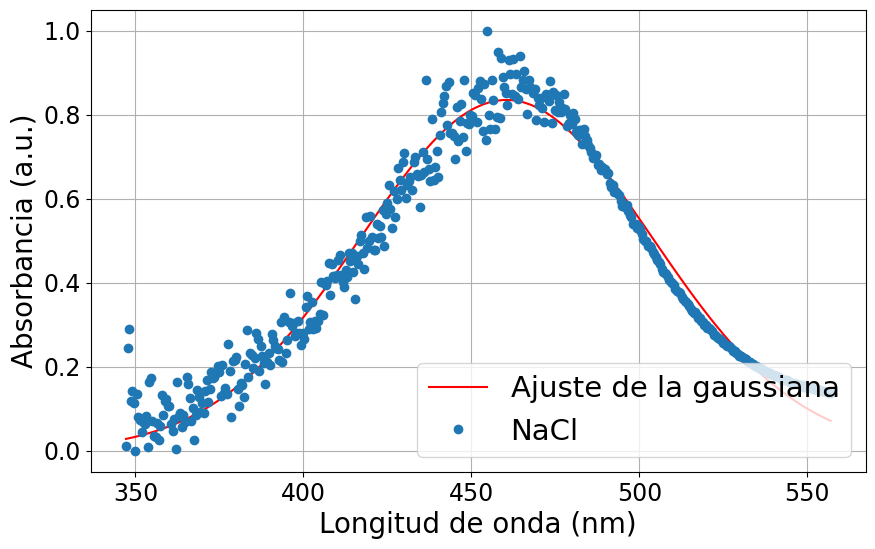


Parámetros ajustados y sus incertezas:
A: 0.9743 ± 0.0043
mu: 503.7874 ± 0.0701
sigma: 13.6520 ± 0.0716


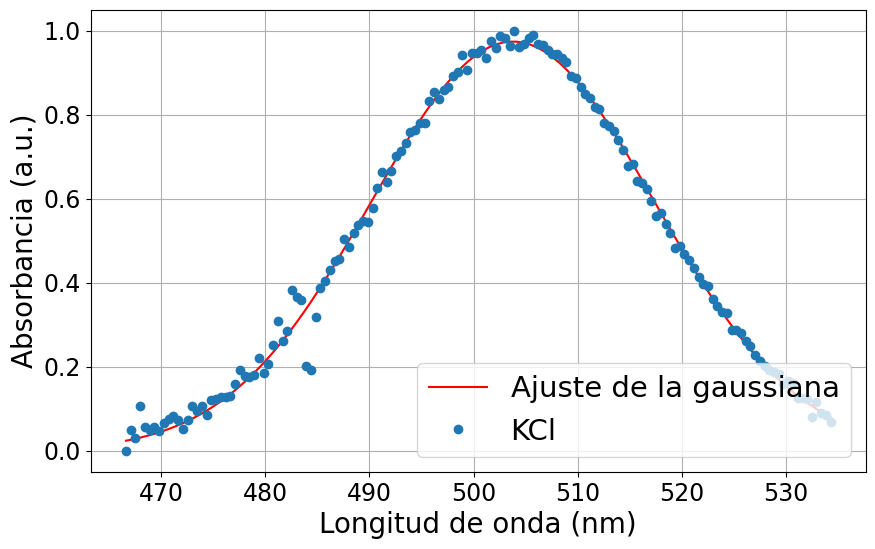


Parámetros ajustados y sus incertezas:
A: 0.9956 ± 0.0019
mu: 618.8280 ± 0.1060
sigma: 47.4207 ± 0.1080


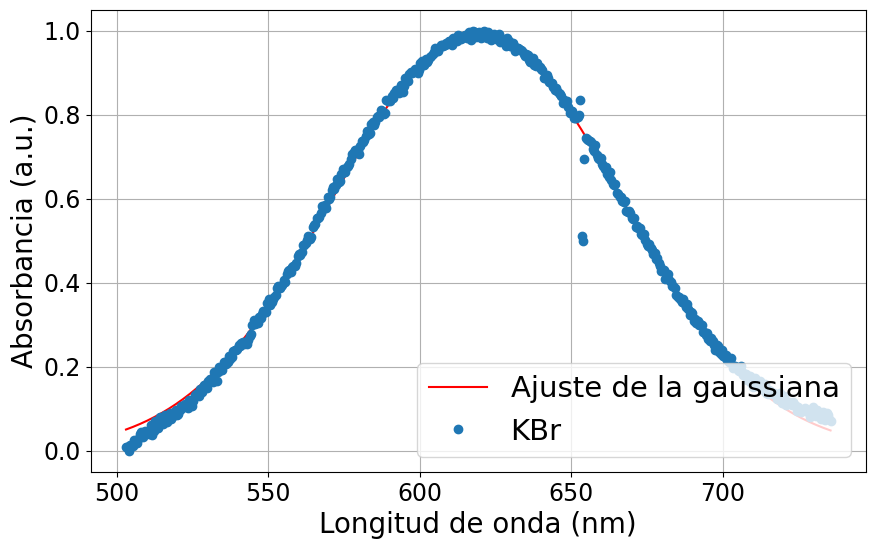


Parámetros ajustados y sus incertezas:
A: 1.0023 ± 0.0034
mu: 683.4305 ± 0.1915
sigma: 49.3659 ± 0.2024


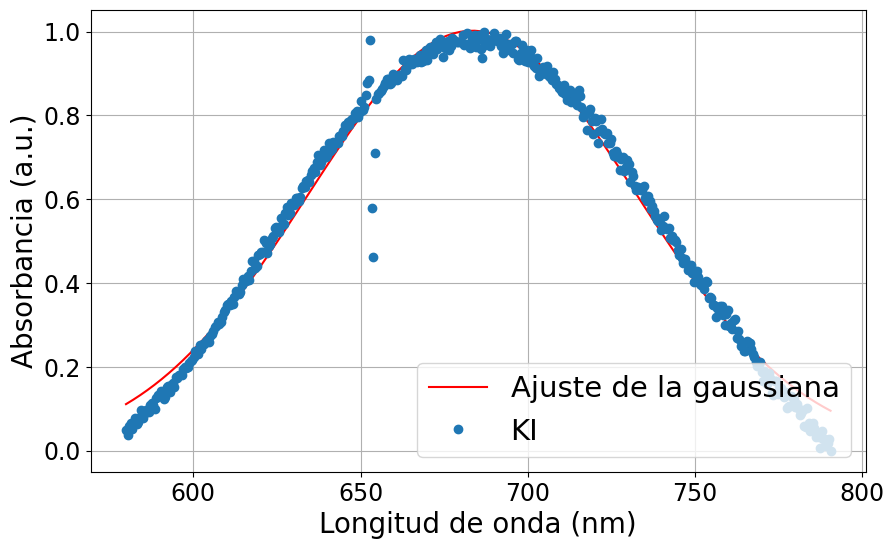

In [ ]:
#Ajustar los espectros medidos

(NaCl, err_NaCl) = ajustar_gaussiana(df_NaCl, (340, 800), (1,460,10), False, label='NaCl' )
(KCl, err_KCl) = ajustar_gaussiana(df_KCl, (600, 750), (1,510,10), True, label='KCl')
(KBr, err_KBr) = ajustar_gaussiana(df_KBr, (680, 1200), (1,625,10), False, label='KBr')
(KI, err_KI) = ajustar_gaussiana(df_KI, (850, 1325), (1,685,10), False,label='KI')

lambda_NaCl = NaCl[1]
lambda_KCl = KCl[1]
lambda_KBr = KBr[1]
lambda_KI = KI[1]

In [ ]:
hbar = 6.582*(10**(-16)) #en eV s
h = 2*np.pi*hbar
c = 2.997*(10**8) #en m/s
mc2 = 0.511*(10**6) #en eV
m = mc2/(c**2)

#Constantes de Red

a_NaCl = 5.64*(10**(-10)) #en m
a_KCl = 6.29*(10**(-10))
a_KBr = 6.60*(10**(-10))
a_KI = 7.07*(10**(-10))

Parámetros obtenidos
-------------------------------------------
n= 1.76+/-0.07 C = 0.99+/-0.04


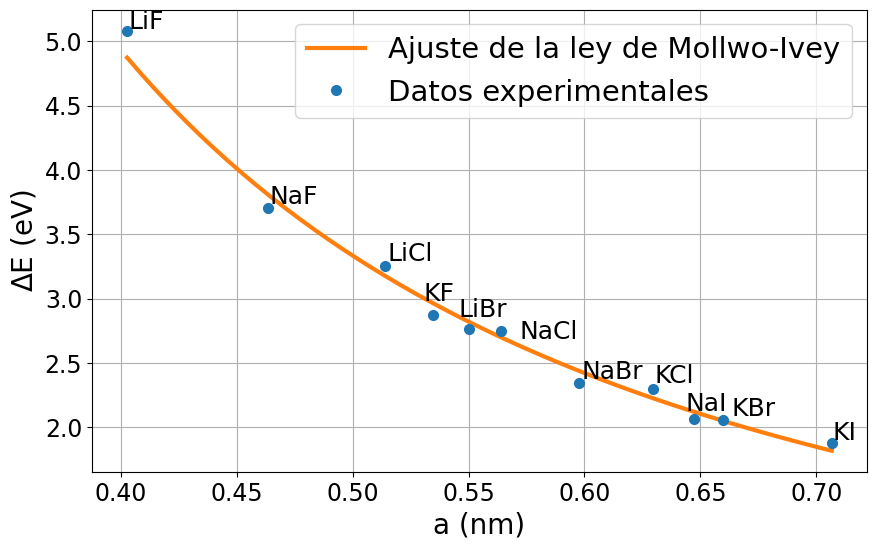

In [ ]:
#Verificar Ley de Mollwo-Ivey (todo junto)

a_ref = datos_ref['a [nm]']
E_ref_unc = unp.uarray(datos_ref['E [eV]'].values, np.full(len(datos_ref['E [eV]']), 0.001))
E_ref = datos_ref['E [eV]']
lambda_ref = h*c*(10**9)/E_ref_unc

def Mollow(params, a):
  n, C = params
  return C*a**(-n)

data = RealData(a_ref, E_ref)
model = Model(Mollow)
odr = ODR(data, model, beta0=(1.5, 1))
out = odr.run()
n = unc.ufloat(out.beta[0], out.sd_beta[0])
C = unc.ufloat(out.beta[1], out.sd_beta[1])

plt.figure(figsize=(10, 6))
plt.errorbar(a_ref, E_ref, fmt='o', ms=7, label='Datos experimentales')
plt.plot(np.linspace(min(a_ref), max(a_ref)), Mollow(out.beta, np.linspace(min(a_ref), max(a_ref))), '-', linewidth=3, label='Ajuste de la ley de Mollwo-Ivey')

texts = []
for i in range(len(a_ref)):
  texts.append(plt.text(a_ref[i], E_ref[i], datos_ref['Sample'][i], fontsize=18))

adjust_text(texts, ha=100)

#plt.title('Ajuste de la Ley de Mollwo-Ivey')
plt.xticks(fontsize=17)
plt.yticks(fontsize=17)
plt.xlabel('a (nm)', size = 20)
plt.ylabel(r'$\Delta$E (eV)', size=20)
plt.legend(fontsize=21)
plt.grid(True)
plt.savefig('Mollwo-Ivey.pdf', dpi=300)

print('Parámetros obtenidos')
print('-------------------------------------------')
print('n=', n, 'C =', C)

# Pozo cúbico infinito
$\Delta E = \frac{3 h^2}{8ma^2}$

$a$ es el lado del cubo, es decir la cte de red (no será $\hbar$ en vez de $h$?)

# Pozo esférico infinito

$\Delta E = 10,315 \frac{\hbar^2}{2ma^2}$

$a$ es el radio de la esfera, en este caso la cte de red/2

<>:40: SyntaxWarning: invalid escape sequence '\s'
<>:40: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-3651956740.py:40: SyntaxWarning: invalid escape sequence '\s'
  plt.errorbar(x*(10**10), saltoo1(x), fmt='bo-', linewidth=3, ms=8, alpha=0.8, label='Pozo esférico ($R=a/\sqrt{2}$)')



Parámetros ajustados y sus incertezas:
A: 0.8352 ± 0.0046
mu: 460.4317 ± 0.2775
sigma: 43.4784 ± 0.2848

Parámetros ajustados y sus incertezas:
A: 0.9743 ± 0.0043
mu: 503.7874 ± 0.0701
sigma: 13.6520 ± 0.0716

Parámetros ajustados y sus incertezas:
A: 0.9956 ± 0.0019
mu: 618.8280 ± 0.1060
sigma: 47.4207 ± 0.1080

Parámetros ajustados y sus incertezas:
A: 1.0023 ± 0.0034
mu: 683.4305 ± 0.1915
sigma: 49.3659 ± 0.2024


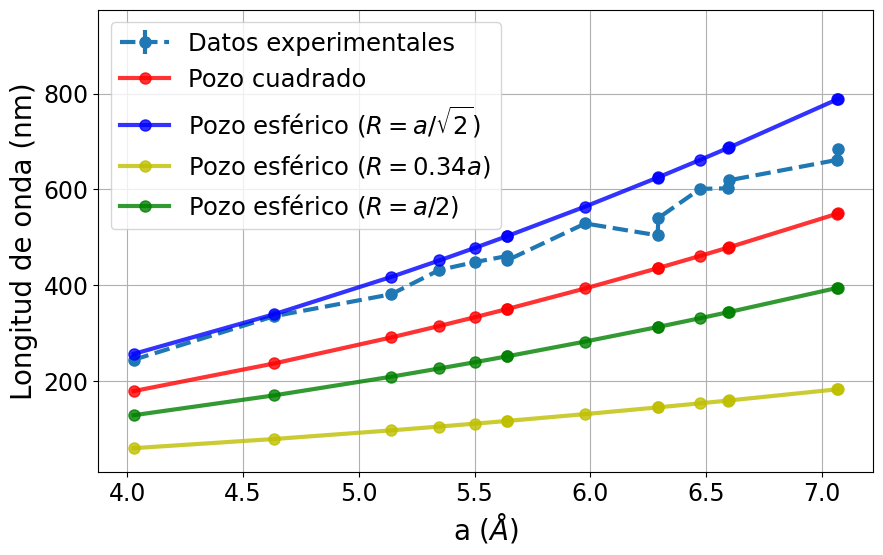

In [ ]:

def saltoc(a):
  return 8*m*c*(a)**2/(3*h)*(10**9)

def saltoe(a):
  return 8*(10**9)*m*c*((np.pi*(a/2))**2)/(10.315*h)

def saltoo1(a):
  return 8*(10**9)*m*c*((np.pi*(a/np.sqrt(2)))**2)/(10.315*h)

def saltoo2(a):
  return 8*(10**9)*m*c*((np.pi*a*0.34)**2)/(10.315*h)

(NaCl, err_NaCl) = ajustar_gaussiana(df_NaCl, (340, 800), (1,460,10), graficar=False ,label='NaCl')
(KCl, err_KCl) = ajustar_gaussiana(df_KCl, (600, 750), (1,510,10),graficar=False ,label='KCl')
(KBr, err_KBr) = ajustar_gaussiana(df_KBr, (680, 1200), (1,625,10), graficar=False,label='KBr')
(KI, err_KI) = ajustar_gaussiana(df_KI, (850, 1325), (1,685,10), graficar=False,label='KI')

lambda_NaCl = NaCl[1]
lambda_KCl = KCl[1]
lambda_KBr = KBr[1]
lambda_KI = KI[1]

lambda_NaCl_err = err_NaCl[1]
lambda_KCl_err = err_KCl[1]
lambda_KBr_err = err_KBr[1]
lambda_KI_err = err_KI[1]

lambdaC=np.concatenate((np.array((lambda_NaCl, lambda_KCl, lambda_KBr, lambda_KI)), unp.nominal_values(lambda_ref)))
err_lambdaC=np.concatenate((np.array((lambda_NaCl_err, lambda_KCl_err, lambda_KBr_err, lambda_KI_err)), unp.std_devs(lambda_ref)))
x = np.concatenate((np.array([a_NaCl,a_KCl,a_KBr,a_KI]), a_ref.values*10**(-9)))

indices = np.argsort(x)
x = x[indices]
lambdaC = lambdaC[indices]
err_lambdaC = err_lambdaC[indices]

plt.figure(figsize=(10, 6))
plt.errorbar(x*(10**10), lambdaC, yerr=err_lambdaC, fmt='o--', ms=8, capsize=0, linewidth=3, label='Datos experimentales')
plt.errorbar(x*(10**10), saltoc(x), fmt='ro-', linewidth=3, ms=8, alpha=0.8, label='Pozo cuadrado')
plt.errorbar(x*(10**10), saltoo1(x), fmt='bo-', linewidth=3, ms=8, alpha=0.8, label='Pozo esférico ($R=a/\sqrt{2}$)')
plt.errorbar(x*(10**10), saltoo2(x), fmt='yo-', linewidth=3, ms=8, alpha=0.8, label='Pozo esférico ($R=0.34a$)')
plt.errorbar(x*(10**10), saltoe(x), fmt='go-', linewidth=3, ms=8, alpha=0.8, label='Pozo esférico ($R=a/2$)')
plt.xticks(fontsize=17)
plt.yticks(fontsize=17)
plt.xlabel('a ($Å$)', size = 20)
plt.ylabel('Longitud de onda (nm)', size=20)
plt.legend(fontsize=17.5)
plt.ylim(10, 975)
plt.grid(True)
plt.savefig('Pozos_infinitos.pdf', dpi=300)

# Pozo esférico finito

In [ ]:
def negative_to_nan(v):
  if isinstance(v, float):
    return np.nan if v < 0 else v
  else:
    arr = v.copy()
    arr[arr < 0] = np.nan
    return arr

def lhs_l0(x):
    return negative_to_nan(-x*(1/np.tan(x)))

def rhs_l0(x, r_0):
    return np.sqrt(r_0**2 - x**2)

def lhs_l1(x, r_0):
    return (r_0**2 - x**2)*(negative_to_nan(x/np.tan(x)) - 1)

def rhs_l1(x, r_0):
    return (x**2)*(1 + np.sqrt(r_0**2 - x**2))

def f_l0(x, r_0):
    return lhs_l0(x) - rhs_l0(x, r_0)

def f_l1(x, r_0):
    return lhs_l1(x, r_0) - rhs_l1(x, r_0)


In [ ]:
#Encontrar las intersecciones

def sphWellSol(alpha, V_0, step, factor=0.5):  #dar alpha (constante de red) en nm

    a = factor*alpha
    a_m = a*(10**(-9))     #transformo a en metros
    r_0 = np.sqrt(2*m*V_0)*a_m/hbar

    l0_sol=array([],dtype=float) #array to store l=0 solutions
    l1_sol=array([],dtype=float)  #array to store l=1 solutions
    inc=arange(step,r_0,step) #array of "x"s to find solutions

    for i in range(len(inc)-1):
            if f_l0(inc[i], r_0)*f_l0(inc[i+1], r_0)<0: #have we bracketed a zero?

                #yes? then find it. Important! optimize.brentq expects the function it is finding
                #the zero of to only take "x" values, anything else, like theta0 gets sent in
                #as args.

                l0_sol=append(l0_sol,optimize.brentq(f_l0,inc[i],inc[i+1],args=r_0) )

    for i in range(len(inc)-1):
            if f_l1(inc[i], r_0)*f_l1(inc[i+1], r_0)<0: #have we bracketed a zero?

                #yes? then find it. Important! optimize.brentq expects the function it is finding
                #the zero of to only take "x" values, anything else, like theta0 gets sent in
                #as args.

                l1_sol=append(l1_sol,optimize.brentq(f_l1,inc[i],inc[i+1],args=r_0) )

    E_l0 = ((hbar*l0_sol)**2/(2*m*(a_m)**2)) - V_0  #Mirar el signo del V_0
    E_l1 = ((hbar*l1_sol)**2/(2*m*(a_m)**2)) - V_0

    return E_l0, E_l1

In [ ]:
# Calcular el delta de energia

def deltaE(a, V_0, step, factor):
    (arr1, arr2) = sphWellSol(a, V_0, step, factor=factor)
    if len(arr1) == 0 or len(arr2) == 0:
        return 0
    else:
      E1 = min(arr1)
      E2 = min(arr2)
    return E2 - E1

In [ ]:
# Es mucho mas eficiente agarrar un n chico y dejar que haga muchas iteraciones
def minimizador_con_tolerancia(func, intervalo, n, cifras, tolerancia):  # Funciona solo si el minimo de la función es 0 (además el arreglo para los arrays vacíos está adaptado para que R = 0.34a funcione)
  arr=np.linspace(intervalo[0], intervalo[1], n)
  step = (intervalo[1] - intervalo[0])/n
  arr_izq = []
  arr_der = []
  for x in arr:
    if func(x - step) > func(x) > func(x + step):
      arr_izq.append(x)
    elif func(x - step) < func(x) < func(x + step):
      arr_der.append(x)

  if len(arr_izq) != 0 and len(arr_der) != 0:
    V_inf = arr_izq[len(arr_izq) - 1]
    V_sup = arr_der[0]
    V = (V_inf + V_sup)/2
  elif len(arr_izq) == 0:
    V_inf = arr_der[0]
    V = V_inf
    V_sup = arr_der[1]
  elif len(arr_der) == 0:
    V_sup = arr_izq[len(arr_izq) - 1]
    V = V_sup
    V_inf = arr_izq[len(arr_izq) - 2]
  elif len(arr_izq) == 0 and len(arr_der) == 0:
    V_inf = intervalo[0]
    V_sup = intervalo[1]
    V = (V_inf + V_sup)/2

  if func(V_inf) - func(V) < 10**(-cifras) and func(V_sup) - func(V) < 10**(-cifras) and func(V) < tolerancia:
    return unc.ufloat(V, (V_sup - V_inf)/2)
  else:
    return minimizador_con_tolerancia(func, [V_inf, V_sup], n, cifras, tolerancia)

In [ ]:
# Diferencia entre el modelo teorico y los datos

def diff_energia(a, V_0, E, factor):
    return np.abs(deltaE(a, V_0, 10**(-3), factor) - E)

In [ ]:
# R = 1/2*a
f = 0.5

for i in range(len(datos_ref)):
  def func(V_0):
    return diff_energia(datos_ref['a [nm]'][i], V_0, datos_ref['E [eV]'][i], f)

  V_opt_unc = minimizador_con_tolerancia(func, [4,20], 25, 1, 10**(-3))
  V_opt = unp.nominal_values(V_opt_unc)
  V_opt_err = unp.std_devs(V_opt_unc)
  print(datos_ref['Sample'][i], V_opt, V_opt_err, deltaE(datos_ref['a [nm]'][i], V_opt, 10**(-3), f), datos_ref['E [eV]'][i])

LiF 12.166666666666666 0.05555555555555536 5.082142022186973 5.083
LiCl 8.180555555555555 0.004629629629629761 3.2560106949106284 3.256
LiBr 6.736111111111111 0.004629629629629761 2.7672297342953724 2.767
NaF 8.578703703703702 0.004629629629628873 3.7025232693114143 3.702
NaCl 7.041666666666666 0.004629629629629317 2.746037133336819 2.746
NaBr 5.712962962962963 0.004629629629629761 2.3454314139653634 2.345
NaI 5.222222222222222 0.05555555555555536 2.0637406634511133 2.063
KF 6.854166666666666 0.0023148148148148806 2.8729828633452406 2.873
KCl 6.259259259259259 0.004629629629629761 2.295129886900976 2.295
KBr 5.481481481481481 0.004629629629629317 2.059102513523459 2.059
KI 5.388888888888889 0.05555555555555536 1.8746127049583237 1.874


# Ignorar

Soluciones físicas l=0 (eV): [5.848807325367385, 9.391993132115914]
Soluciones físicas l=1 (eV): [9.391993132103842, 10.583554061586169]


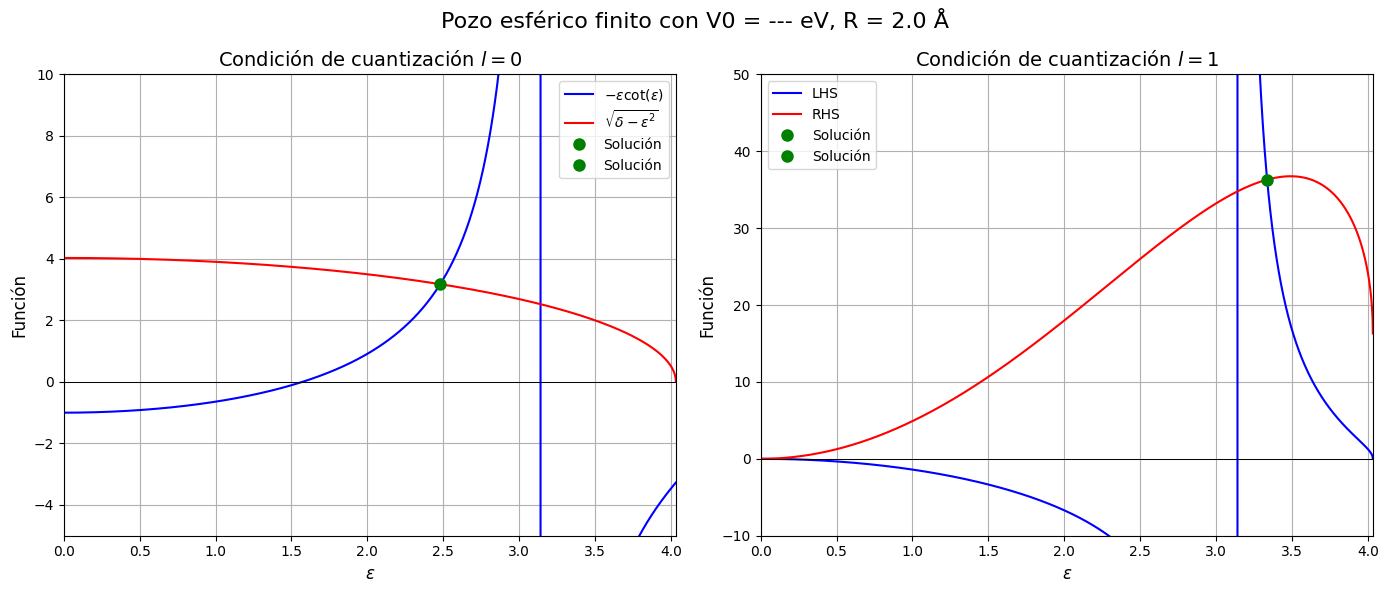

In [ ]:
# ============================================================
# Condiciones de cuantización para el pozo esférico finito
# Ejemplo: V0 = 5.7 eV, R = 2 Å
# Graficamos y resolvemos numéricamente las intersecciones
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# -----------------------------
# Constantes físicas (SI)
# -----------------------------
hbar = 1.054e-34   # J·s
me = 9.109e-31     # kg
eV = 1.602e-19     # J
R = 2e-10          # Radio efectivo del pozo (ejemplo: 2 Å)

# -----------------------------
# Parámetros del pozo
# -----------------------------
V0 = 15.462 * eV
delta = 2 * me * V0 * R**2 / hbar**2   # parámetro adimensional

# -----------------------------
# Definición de funciones
# -----------------------------
def f_l0(eps):   # LHS para l=0
    return -eps/np.tan(eps)

def rhs_l0(eps):  # RHS para l=0
    return np.sqrt(delta - eps**2)

def f_l1(eps):   # LHS para l=1
    return (eps/np.tan(eps) - 1) * np.sqrt(delta - eps**2) #Va ahí ese sqrt?

def rhs_l1(eps): # RHS para l=1
    return eps**2 * (1 + np.sqrt(delta - eps**2))

# -----------------------------
# Encontrar intersecciones
# -----------------------------
def find_roots(func1, func2, eps_max, n_points=1000):
    """Busca intersecciones entre func1 y func2"""
    eps_vals = np.linspace(1e-6, eps_max-1e-6, n_points)
    diff = func1(eps_vals) - func2(eps_vals)
    roots = []
    for i in range(len(eps_vals)-1):
        if np.isnan(diff[i]) or np.isnan(diff[i+1]):
            continue
        if diff[i]*diff[i+1] < 0:
            try:
                r = brentq(lambda x: func1(x)-func2(x), eps_vals[i], eps_vals[i+1])
                roots.append(r)
            except:
                pass
    return roots

eps_max = np.sqrt(delta)

roots_l0 = find_roots(f_l0, rhs_l0, eps_max)
roots_l1 = find_roots(f_l1, rhs_l1, eps_max)

# Convertir a energías (eV)
E_l0 = [hbar**2 * eps**2 / (2*me*R**2) / eV for eps in roots_l0]
E_l1 = [hbar**2 * eps**2 / (2*me*R**2) / eV for eps in roots_l1]

print("Soluciones físicas l=0 (eV):", E_l0)
print("Soluciones físicas l=1 (eV):", E_l1)

# -----------------------------
# Gráficas
# -----------------------------
eps_vals = np.linspace(1e-6, eps_max-1e-6, 2000)

fig, axs = plt.subplots(1, 2, figsize=(14,6))

# ---- l=0 ----
axs[0].plot(eps_vals, f_l0(eps_vals), label=r"$-\epsilon \cot(\epsilon)$", color="blue")
axs[0].plot(eps_vals, rhs_l0(eps_vals), label=r"$\sqrt{\delta - \epsilon^2}$", color="red")
# marcar intersecciones
for r in roots_l0:
    axs[0].plot(r, f_l0(r), "go", markersize=8, label="Solución")
axs[0].set_title(r"Condición de cuantización $l=0$", fontsize=14)
axs[0].set_xlabel(r"$\epsilon$", fontsize=12)
axs[0].set_ylabel("Función", fontsize=12)
axs[0].set_ylim(-5, 10)
axs[0].set_xlim(0, eps_max)
axs[0].axhline(0, color="black", linewidth=0.7)
axs[0].legend()
axs[0].grid(True)

# ---- l=1 ----
axs[1].plot(eps_vals, f_l1(eps_vals), label="LHS", color="blue")
axs[1].plot(eps_vals, rhs_l1(eps_vals), label="RHS", color="red")
for r in roots_l1:
    axs[1].plot(r, f_l1(r), "go", markersize=8, label="Solución")
axs[1].set_title(r"Condición de cuantización $l=1$", fontsize=14)
axs[1].set_xlabel(r"$\epsilon$", fontsize=12)
axs[1].set_ylabel("Función", fontsize=12)
axs[1].set_ylim(-10, 50)
axs[1].set_xlim(0, eps_max)
axs[1].axhline(0, color="black", linewidth=0.7)
axs[1].legend()
axs[1].grid(True)

plt.suptitle(f"Pozo esférico finito con V0 = --- eV, R = {R*1e10:.1f} Å", fontsize=16)
plt.tight_layout()
plt.show()


Usando lambda = 350 nm  => target ΔE = 3.542857 eV

Resultado aproximado (refinado):
V0_min (eV): 15.462263099219621
chi2_min: 9.293088674190074e-08
E0_best (eV): 5.848831143582109
E1_best (eV): 9.39199313211618
ΔE_best (eV): 3.543161988534071


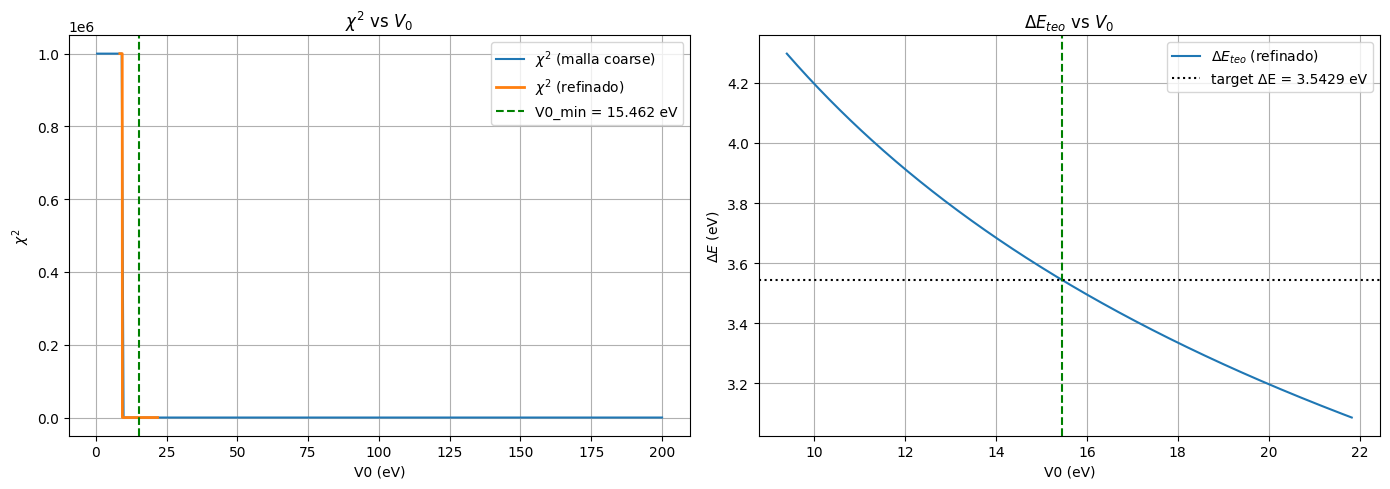


En V0_opt = 15.462263 eV:
E0 = 5.848831143582109 eV  (eps0 = 2.4791655661887164 )
E1 = 9.39199313211618 eV  (eps1 = 3.1415926535907976 )


In [ ]:
# ====================================================================
# Ajuste de V0 para un pozo esférico finito: encontrar V0 que reproduce
# el salto E1 - E0 dado (entrada: lambda en nm o energía en eV).
# Salida: chi2 vs V0 y V0_min que minimiza chi2.
# ====================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from math import isnan

# -----------------------------
# Constantes físicas (SI)
# -----------------------------
hbar = 1.054e-34   # J·s
me = 9.109e-31     # kg
eV = 1.602e-19     # J

# -----------------------------
# Parámetros por defecto
# -----------------------------
R = 2e-10        # radio del pozo en metros (ej: 2 Å)
# R: si querés darle un "lambda" distinto, el código acepta lambda_nm o target_eV (ver abajo).

# -----------------------------
# Funciones de cuantización (usamos eps = sqrt(2m E R^2 / ħ^2))
# -----------------------------
def f_l0(eps, delta):
    return -eps/np.tan(eps)

def rhs_l0(eps, delta):
    return np.sqrt(delta - eps**2)

def f_l1(eps, delta):
    return (eps/np.tan(eps) - 1) * np.sqrt(delta - eps**2)

def rhs_l1(eps, delta):
    return eps**2 * (1 + np.sqrt(delta - eps**2))

# -----------------------------
# Búsqueda de raíces por brentq en una malla de eps
# -----------------------------
def find_roots_between(func1, func2, delta, eps_max, n_points=2000):
    """Busca intersecciones func1(eps,delta)=func2(eps,delta) en (0, eps_max)"""
    eps_vals = np.linspace(1e-8, eps_max-1e-8, n_points)
    # Evaluar evitando NaNs
    with np.errstate(invalid='ignore', divide='ignore'):
        diff = func1(eps_vals, delta) - func2(eps_vals, delta)
    roots = []
    for i in range(len(eps_vals)-1):
        a, b = eps_vals[i], eps_vals[i+1]
        fa, fb = diff[i], diff[i+1]
        if np.isnan(fa) or np.isnan(fb):
            continue
        if fa * fb < 0:
            try:
                r = brentq(lambda x: func1(x, delta)-func2(x, delta), a, b, maxiter=200)
                # evitar duplicados muy cercanos
                if not any(abs(r - rr) < 1e-6 for rr in roots):
                    roots.append(r)
            except Exception:
                pass
    roots.sort()
    return roots

# -----------------------------
# Dado V0 y R calculo ΔE_teo (primera excitada l=1 minus fundamental l=0)
#  — si no existe l=1 o l=0 devuelve None
# -----------------------------
def deltaE_for_V0(V0_eV, R_m, find_all_eps=False):
    V0 = V0_eV * eV
    delta = 2 * me * V0 * R_m**2 / hbar**2
    if delta <= 0:
        return None  # sin sentido

    eps_max = np.sqrt(delta) * 0.999999  # levemente menor para evitar sqrt(0)
    # buscar primeras raíces (lowest eps) para l=0 y l=1
    roots_l0 = find_roots_between(f_l0, rhs_l0, delta, eps_max, n_points=3000)
    roots_l1 = find_roots_between(f_l1, rhs_l1, delta, eps_max, n_points=3000)

    if len(roots_l0) == 0 or len(roots_l1) == 0:
        # Si faltan raíces para cualquiera, no hay par (E0,E1) definido
        return None

    # Tomamos la primera raíz de cada una: ground (n=1,l=0) y primer p (n=1,l=1)
    eps0 = roots_l0[0]
    eps1 = roots_l1[0]

    E0 = (hbar**2 * eps0**2) / (2 * me * R_m**2) / eV  # en eV
    E1 = (hbar**2 * eps1**2) / (2 * me * R_m**2) / eV  # en eV

    if find_all_eps:
        return E0, E1, roots_l0, roots_l1, delta
    else:
        return E0, E1

# -----------------------------
# Función principal para barrer V0 y calcular chi2
# -----------------------------
def fit_V0_by_deltaE(target_E_eV,
                    R_m=R,
                    V0_min_eV=0.1,
                    V0_max_eV=100.0,
                    N=300):
    """
    Barrido en V0 (en eV) y cálculo de chi2 = (ΔE_teo - target_E_eV)^2.
    Devuelve arrays: V0s, chi2s y el V0_min (y valores asociados).
    """
    V0s = np.linspace(V0_min_eV, V0_max_eV, N)
    chi2s = np.zeros_like(V0s)
    deltaEs = np.full_like(V0s, np.nan, dtype=float)
    E0s = np.full_like(V0s, np.nan, dtype=float)
    E1s = np.full_like(V0s, np.nan, dtype=float)

    for i, V0 in enumerate(V0s):
        res = deltaE_for_V0(V0, R_m)
        if res is None:
            # penalizamos con un chi2 grande (no hay pares (E0,E1))
            chi2s[i] = 1e6
            deltaEs[i] = np.nan
        else:
            E0, E1 = res
            dE = E1 - E0
            deltaEs[i] = dE
            E0s[i] = E0
            E1s[i] = E1
            chi2s[i] = (dE - target_E_eV)**2

    # mínimo bruto en la malla
    idx_min = np.nanargmin(chi2s)
    V0_min_coarse = V0s[idx_min]

    # refinamiento local usando búsqueda con brentq sobre chi2'(V0) no trivial,
    # en lugar de eso hacemos un refinamiento con malla fina en entorno
    window = max((V0_max_eV - V0_min_eV)/N * 10, 0.5)  # ventana local
    vlow = max(V0_min_eV, V0_min_coarse - window)
    vhigh = min(V0_max_eV, V0_min_coarse + window)
    V0s_ref = np.linspace(vlow, vhigh, 400)
    chi2s_ref = np.zeros_like(V0s_ref)
    deltaEs_ref = np.full_like(V0s_ref, np.nan, dtype=float)
    E0s_ref = np.full_like(V0s_ref, np.nan, dtype=float)
    E1s_ref = np.full_like(V0s_ref, np.nan, dtype=float)
    for i, V0 in enumerate(V0s_ref):
        res = deltaE_for_V0(V0, R_m)
        if res is None:
            chi2s_ref[i] = 1e6
        else:
            E0, E1 = res
            dE = E1 - E0
            deltaEs_ref[i] = dE
            E0s_ref[i] = E0
            E1s_ref[i] = E1
            chi2s_ref[i] = (dE - target_E_eV)**2

    idx_min_ref = np.nanargmin(chi2s_ref)
    V0_min = V0s_ref[idx_min_ref]
    best = {
        "V0_min_eV": V0_min,
        "chi2_min": chi2s_ref[idx_min_ref],
        "E0_best_eV": E0s_ref[idx_min_ref],
        "E1_best_eV": E1s_ref[idx_min_ref],
        "dE_best_eV": deltaEs_ref[idx_min_ref]
    }

    # devolver todo para graficar
    return {
        "V0s": V0s,
        "chi2s": chi2s,
        "deltaEs": deltaEs,
        "E0s": E0s,
        "E1s": E1s,
        "V0s_ref": V0s_ref,
        "chi2s_ref": chi2s_ref,
        "deltaEs_ref": deltaEs_ref,
        "E0s_ref": E0s_ref,
        "E1s_ref": E1s_ref,
        "best": best
    }

# -----------------------------
# Ejemplo de uso:
# 1) si tenés una lambda (longitud de onda en nm), convertimos a energía
# 2) si ya tenés target_eV, usalo directamente
# -----------------------------
# EJEMPLO: uso con lambda en nm
lambda_nm = 350   # <- pone aquí un número en nm si querés (ej: 300)
target_eV = None   # <- o pon directamente la energía objetivo en eV (ej: 4.22)

# Elegir input: si lambda_nm no es None usamos eso, sino target_eV
if lambda_nm is not None:
    # E (eV) = 1240 / lambda(nm)
    target_E = 1240.0 / float(lambda_nm)
    print(f"Usando lambda = {lambda_nm} nm  => target ΔE = {target_E:.6f} eV")
elif target_eV is not None:
    target_E = float(target_eV)
    print(f"Usando target ΔE = {target_E:.6f} eV")
else:
    # valor por defecto para demo: 4.22 eV
    target_E = 4.22
    print(f"No se pasó lambda ni target_eV: uso demo target ΔE = {target_E:.6f} eV")

# Barrido e ajuste
res = fit_V0_by_deltaE(target_E, R_m=R, V0_min_eV=0.5, V0_max_eV=200.0, N=300)

print("\nResultado aproximado (refinado):")
print("V0_min (eV):", res["best"]["V0_min_eV"])
print("chi2_min:", res["best"]["chi2_min"])
print("E0_best (eV):", res["best"]["E0_best_eV"])
print("E1_best (eV):", res["best"]["E1_best_eV"])
print("ΔE_best (eV):", res["best"]["dE_best_eV"])

# -----------------------------
# Gráficas: chi2 vs V0 y ΔE_theo vs V0
# -----------------------------
fig, ax = plt.subplots(1, 2, figsize=(14,5))

ax[0].plot(res["V0s"], res["chi2s"], label=r"$\chi^2$ (malla coarse)")
ax[0].plot(res["V0s_ref"], res["chi2s_ref"], label=r"$\chi^2$ (refinado)", linewidth=2)
ax[0].axvline(res["best"]["V0_min_eV"], color='green', linestyle='--', label=f"V0_min = {res['best']['V0_min_eV']:.3f} eV")
ax[0].set_xlabel("V0 (eV)")
ax[0].set_ylabel(r"$\chi^2$")
ax[0].set_title(r"$\chi^2$ vs $V_0$")
ax[0].legend()
ax[0].grid(True)

ax[1].plot(res["V0s_ref"], res["deltaEs_ref"], label=r"$\Delta E_{teo}$ (refinado)")
ax[1].axhline(target_E, color='black', linestyle=':', label=f"target ΔE = {target_E:.4f} eV")
ax[1].axvline(res["best"]["V0_min_eV"], color='green', linestyle='--')
ax[1].set_xlabel("V0 (eV)")
ax[1].set_ylabel(r"$\Delta E$ (eV)")
ax[1].set_title(r"$\Delta E_{teo}$ vs $V_0$")
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

# -----------------------------
# Si querés además ver las funciones y las raíces en el V0_opt:
# -----------------------------
V0_opt = res["best"]["V0_min_eV"]
info = deltaE_for_V0(V0_opt, R, find_all_eps=True)
if info is not None:
    E0b, E1b, roots_l0, roots_l1, delta = info
    print("\nEn V0_opt = {:.6f} eV:".format(V0_opt))
    print("E0 =", E0b, "eV  (eps0 =", roots_l0[0], ")")
    print("E1 =", E1b, "eV  (eps1 =", roots_l1[0], ")")
else:
    print("En V0_opt no se pudieron obtener raíces (raro).")


Compuesto   a (nm)   E_exp (eV)  V0_fit (eV)    ΔE_theo (eV)
LiF      0.4028        5.083        9.460           4.204
LiCl     0.5140        3.256        6.117           2.532
LiBr     0.5502        2.767        5.448           2.192
LiI      0.6000        3.176        4.780           1.814
NaF      0.4634        3.702        7.454           3.126
NaCl     0.5640        2.746        4.780           2.152
NaBr     0.5978        2.345        4.780           1.832
NaI      0.6474        2.063        4.111           1.557
KF       0.5348        2.873        5.448           2.371
KCl      0.6294        2.295        4.111           1.683
KBr      0.6596        2.059        4.111           1.479
KI       0.7066        1.874        3.443           1.308


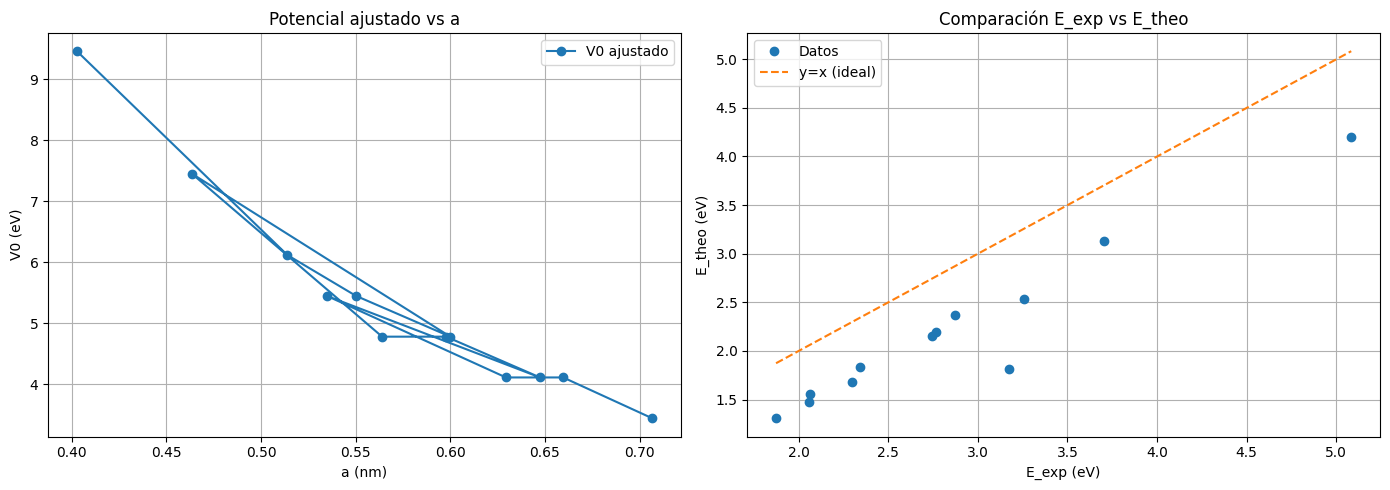

In [ ]:
# ============================================================
# Ajuste del pozo esférico finito para sales alcalinas
# Usamos datos de a (nm) y E_exp (eV) -> buscamos V0 óptimo
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# -----------------------------
# Constantes físicas (SI)
# -----------------------------
hbar = 1.054e-34   # J·s
me = 9.109e-31     # kg
eV = 1.602e-19     # J

# -----------------------------
# Funciones de cuantización
# -----------------------------
def f_l0(eps, delta):
    return -eps/np.tan(eps)

def rhs_l0(eps, delta):
    return np.sqrt(delta - eps**2)

def f_l1(eps, delta):
    return (eps/np.tan(eps) - 1) *(delta - eps**2)

def rhs_l1(eps, delta):
    return eps**2 * (1 + np.sqrt(delta - eps**2))

# -----------------------------
# Raíces entre LHS y RHS
# -----------------------------
def find_roots_between(func1, func2, delta, eps_max, n_points=2000):
    eps_vals = np.linspace(1e-8, eps_max-1e-8, n_points)
    with np.errstate(invalid='ignore', divide='ignore'):
        diff = func1(eps_vals, delta) - func2(eps_vals, delta)
    roots = []
    for i in range(len(eps_vals)-1):
        a, b = eps_vals[i], eps_vals[i+1]
        fa, fb = diff[i], diff[i+1]
        if np.isnan(fa) or np.isnan(fb):
            continue
        if fa * fb < 0:
            try:
                r = brentq(lambda x: func1(x, delta)-func2(x, delta), a, b, maxiter=200)
                if not any(abs(r - rr) < 1e-6 for rr in roots):
                    roots.append(r)
            except Exception:
                pass
    roots.sort()
    return roots

# -----------------------------
# Dado V0 y R, calcular ΔE
# -----------------------------
def deltaE_for_V0(V0_eV, R_m):
    V0 = V0_eV * eV
    delta = 2 * me * V0 * R_m**2 / hbar**2
    if delta <= 0:
        return None
    eps_max = np.sqrt(delta) * 0.999999
    roots_l0 = find_roots_between(f_l0, rhs_l0, delta, eps_max)
    roots_l1 = find_roots_between(f_l1, rhs_l1, delta, eps_max)
    if len(roots_l0) == 0 or len(roots_l1) == 0:
        return None
    eps0, eps1 = roots_l0[0], roots_l1[0]
    E0 = (hbar**2 * eps0**2) / (2 * me * R_m**2) / eV
    E1 = (hbar**2 * eps1**2) / (2 * me * R_m**2) / eV
    return E0, E1

# -----------------------------
# Barrido en V0 para ajustar ΔE
# -----------------------------
def fit_V0(target_E, R_m, V0_min=0.1, V0_max=200, N=300):
    V0s = np.linspace(V0_min, V0_max, N)
    chi2s = []
    deltaEs = []
    for V0 in V0s:
        res = deltaE_for_V0(V0, R_m)
        if res is None:
            chi2s.append(1e6)
            deltaEs.append(np.nan)
        else:
            E0, E1 = res
            dE = E1 - E0
            chi2s.append((dE - target_E)**2)
            deltaEs.append(dE)
    idx_min = np.nanargmin(chi2s)
    return V0s[idx_min], deltaEs[idx_min], chi2s[idx_min]

# -----------------------------
# Datos experimentales
# -----------------------------
data_all = [
    ("LiF", 0.4028, 5.083),
    ("LiCl", 0.514, 3.256),
    ("LiBr", 0.5502, 2.767),
    ("LiI", 0.600, 3.176),
    ("NaF", 0.4634, 3.702),
    ("NaCl", 0.564, 2.746),
    ("NaBr", 0.5978, 2.345),
    ("NaI", 0.6474, 2.063),
    ("KF", 0.5348, 2.873),
    ("KCl", 0.6294, 2.295),
    ("KBr", 0.6596, 2.059),
    ("KI", 0.7066, 1.874),
]

# -----------------------------
# Ajuste para todos los compuestos
# -----------------------------
results = []
for name, a_nm, E_exp in data_all:
    R = (a_nm * 1e-9) / 2.0  # radio efectivo en metros
    V0_fit, E_theo, chi2 = fit_V0(E_exp, R)
    results.append((name, a_nm, E_exp, V0_fit, E_theo))

# -----------------------------
# Mostrar resultados
# -----------------------------
print(f"{'Compuesto':<6} {'a (nm)':>8} {'E_exp (eV)':>12} {'V0_fit (eV)':>12} {'ΔE_theo (eV)':>15}")
for row in results:
    print(f"{row[0]:<6} {row[1]:8.4f} {row[2]:12.3f} {row[3]:12.3f} {row[4]:15.3f}")

# -----------------------------
# Gráficas
# -----------------------------
a_vals = [r[1] for r in results]
V0_vals = [r[3] for r in results]
E_exp_vals = [r[2] for r in results]
E_theo_vals = [r[4] for r in results]

fig, ax = plt.subplots(1, 2, figsize=(14,5))

# V0 vs a
ax[0].plot(a_vals, V0_vals, "o-", label="V0 ajustado")
ax[0].set_xlabel("a (nm)")
ax[0].set_ylabel("V0 (eV)")
ax[0].set_title("Potencial ajustado vs a")
ax[0].grid(True)
ax[0].legend()

# E_exp vs E_theo
ax[1].plot(E_exp_vals, E_theo_vals, "o", label="Datos")
ax[1].plot([min(E_exp_vals), max(E_exp_vals)],
           [min(E_exp_vals), max(E_exp_vals)], "--", label="y=x (ideal)")
ax[1].set_xlabel("E_exp (eV)")
ax[1].set_ylabel("E_theo (eV)")
ax[1].set_title("Comparación E_exp vs E_theo")
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.show()



LiF: a = 0.4028 nm -> R = 2.014 Å; E_exp = 5.083 eV
  V0_best = 9.2703 eV, E0 = 5.0252 eV, E1 = 9.2619 eV, ΔE = 4.2367 eV

LiCl: a = 0.5140 nm -> R = 2.570 Å; E_exp = 3.256 eV
  V0_best = 5.7077 eV, E0 = 3.0886 eV, E1 = 5.6879 eV, ΔE = 2.5993 eV

LiBr: a = 0.5502 nm -> R = 2.751 Å; E_exp = 2.767 eV
  V0_best = 4.9696 eV, E0 = 2.6935 eV, E1 = 4.9641 eV, ΔE = 2.2705 eV

LiI: a = 0.6000 nm -> R = 3.000 Å; E_exp = 3.176 eV
  V0_best = 4.1827 eV, E0 = 2.2656 eV, E1 = 4.1742 eV, ΔE = 1.9086 eV

NaF: a = 0.4634 nm -> R = 2.317 Å; E_exp = 3.702 eV
  V0_best = 7.0317 eV, E0 = 3.8016 eV, E1 = 6.9979 eV, ΔE = 3.1963 eV

NaCl: a = 0.5640 nm -> R = 2.820 Å; E_exp = 2.746 eV
  V0_best = 4.7646 eV, E0 = 2.5694 eV, E1 = 4.7241 eV, ΔE = 2.1547 eV

NaBr: a = 0.5978 nm -> R = 2.989 Å; E_exp = 2.345 eV
  V0_best = 4.2202 eV, E0 = 2.2835 eV, E1 = 4.2050 eV, ΔE = 1.9215 eV

NaI: a = 0.6474 nm -> R = 3.237 Å; E_exp = 2.063 eV
  V0_best = 3.6190 eV, E0 = 1.9505 eV, E1 = 3.5854 eV, ΔE = 1.6348 eV

KF: a = 0.5

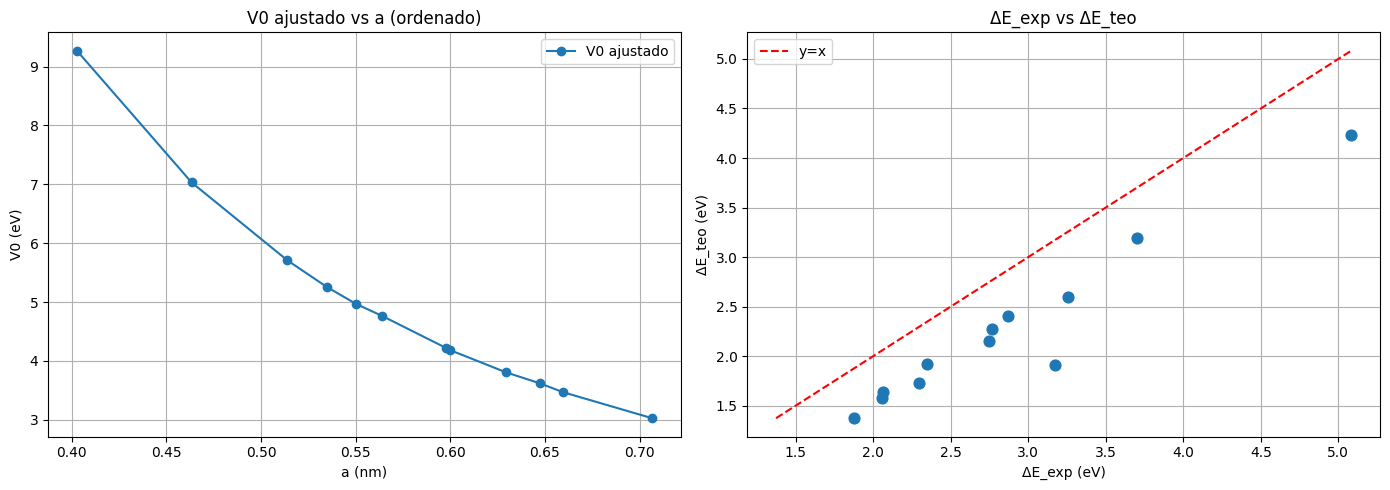


Chequear ajustes con discrepancia > 0.1 eV:

LiF tiene ΔE_exp=5.083 eV, ΔE_teo=4.237 eV, err=0.846 eV -> gráfico diagnóstico


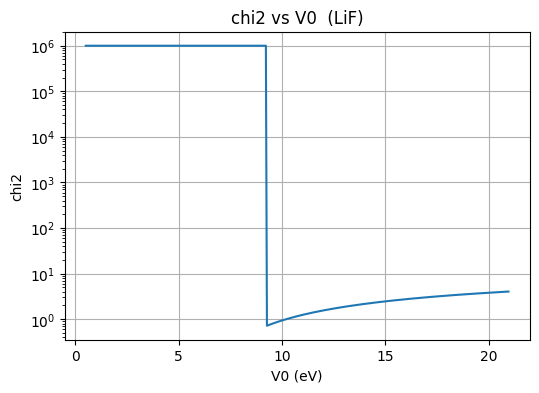

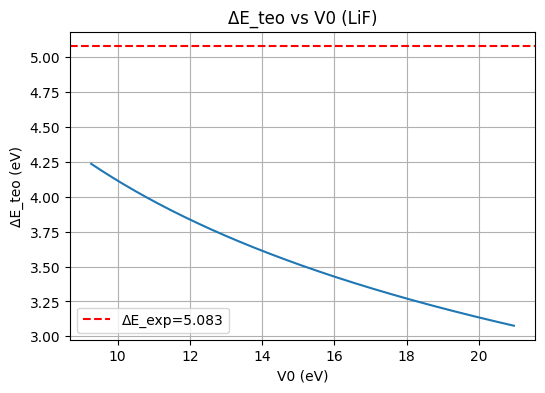


NaF tiene ΔE_exp=3.702 eV, ΔE_teo=3.196 eV, err=0.506 eV -> gráfico diagnóstico


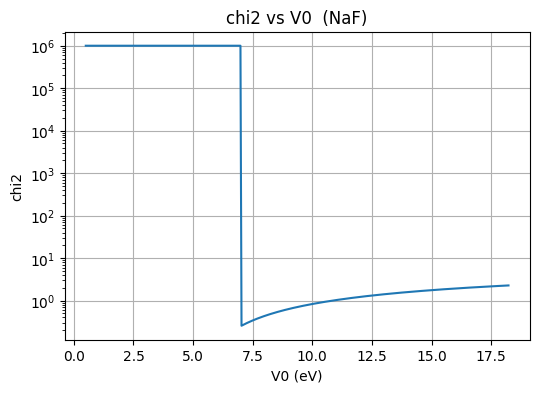

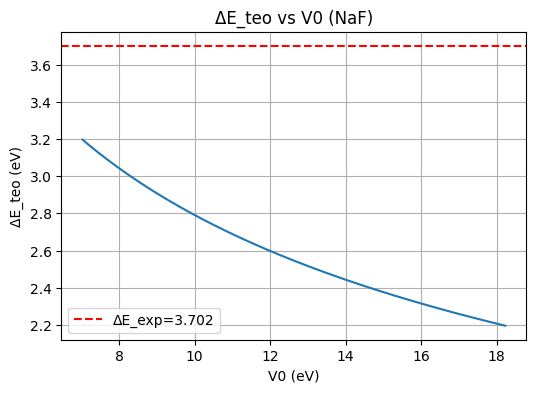


LiCl tiene ΔE_exp=3.256 eV, ΔE_teo=2.599 eV, err=0.657 eV -> gráfico diagnóstico


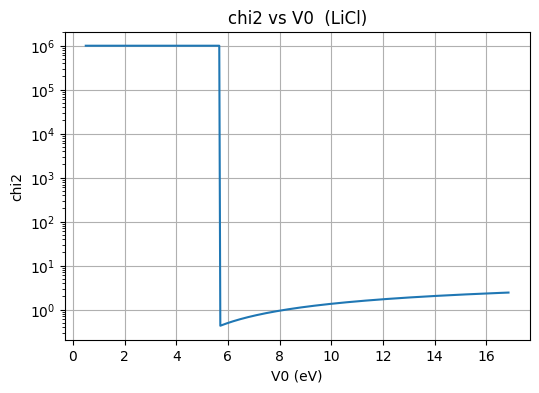

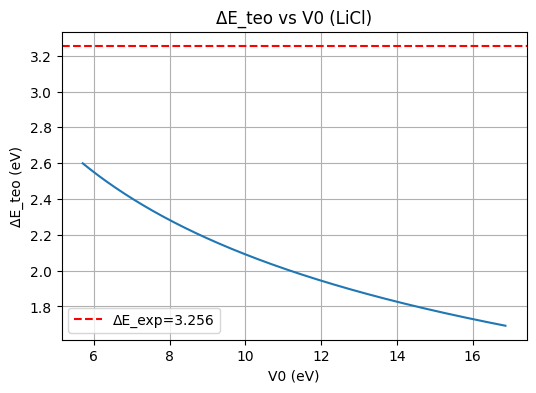


KF tiene ΔE_exp=2.873 eV, ΔE_teo=2.404 eV, err=0.469 eV -> gráfico diagnóstico


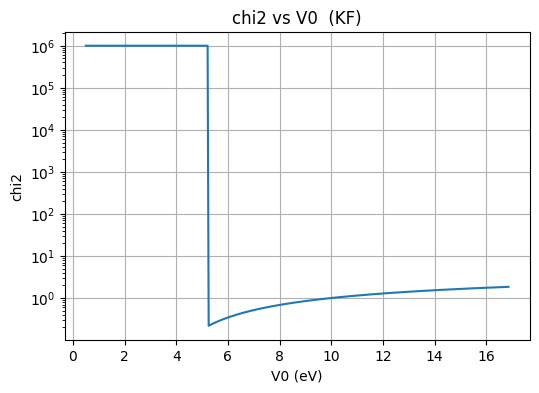

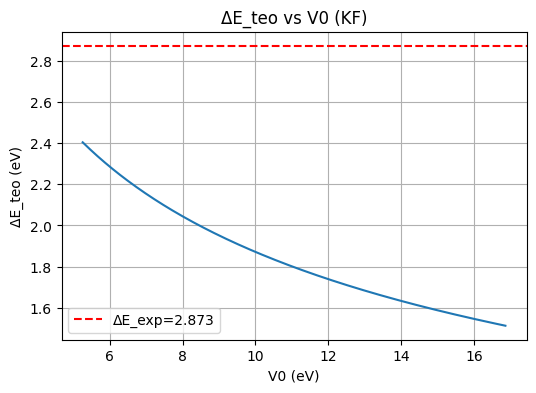


LiBr tiene ΔE_exp=2.767 eV, ΔE_teo=2.271 eV, err=0.496 eV -> gráfico diagnóstico


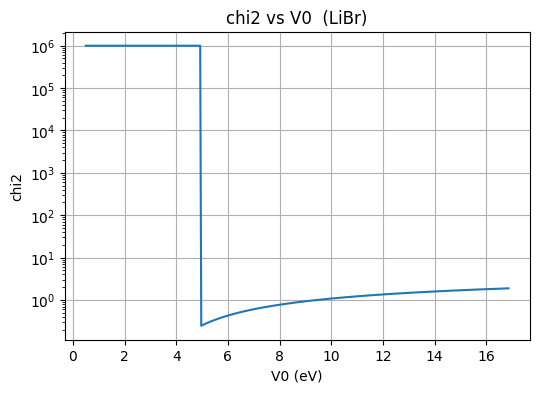

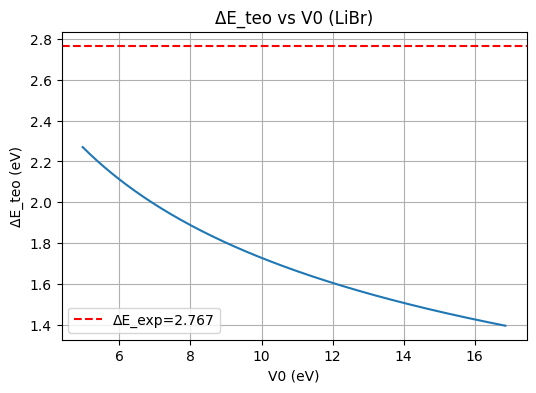


NaCl tiene ΔE_exp=2.746 eV, ΔE_teo=2.155 eV, err=0.591 eV -> gráfico diagnóstico


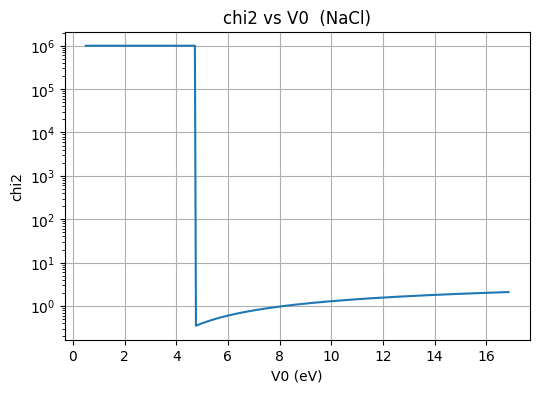

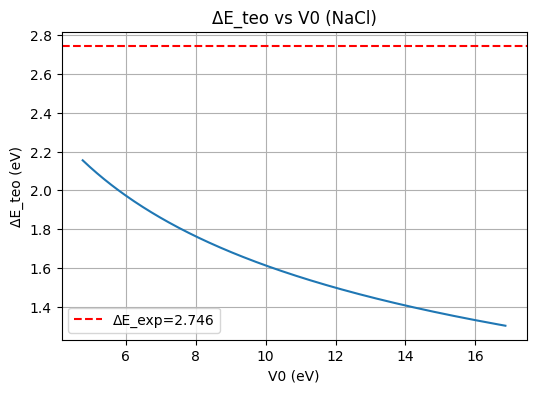


NaBr tiene ΔE_exp=2.345 eV, ΔE_teo=1.922 eV, err=0.423 eV -> gráfico diagnóstico


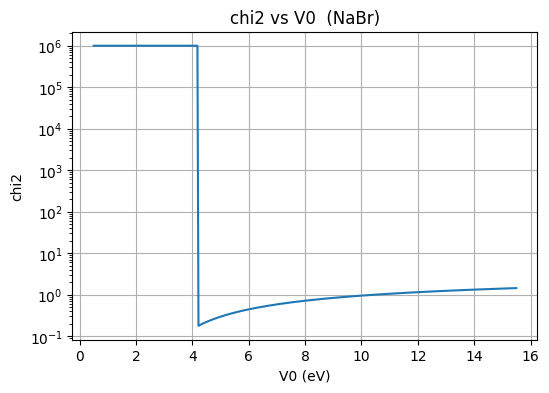

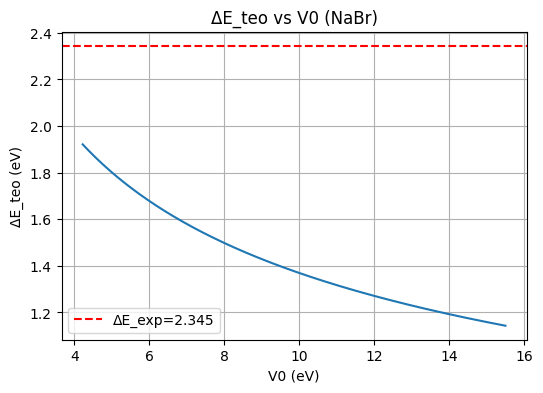


LiI tiene ΔE_exp=3.176 eV, ΔE_teo=1.909 eV, err=1.267 eV -> gráfico diagnóstico


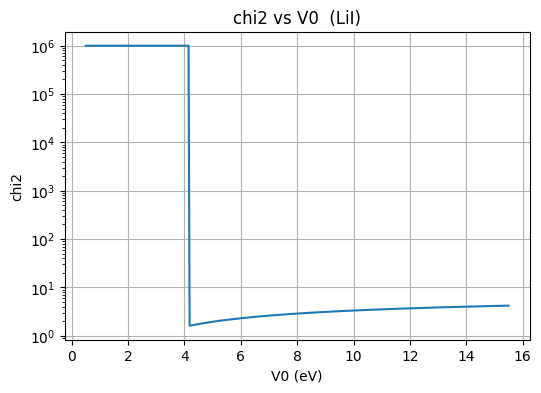

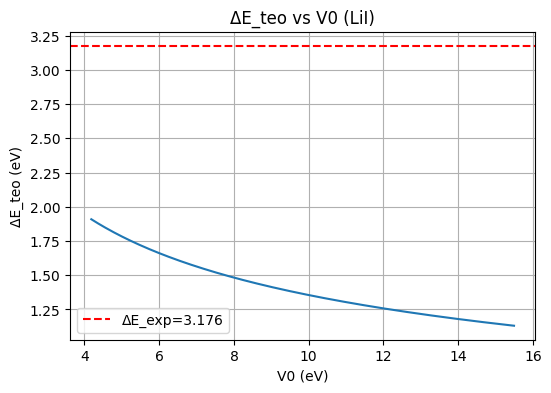


KCl tiene ΔE_exp=2.295 eV, ΔE_teo=1.733 eV, err=0.562 eV -> gráfico diagnóstico


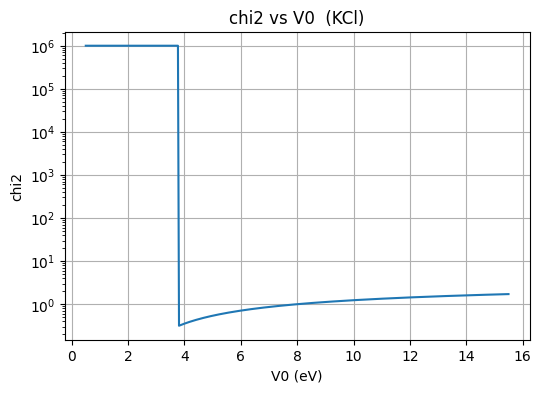

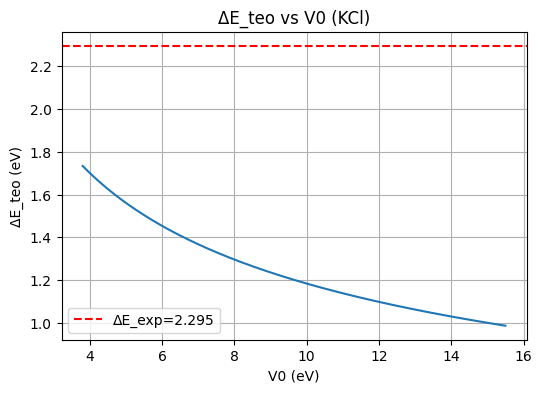


NaI tiene ΔE_exp=2.063 eV, ΔE_teo=1.635 eV, err=0.428 eV -> gráfico diagnóstico


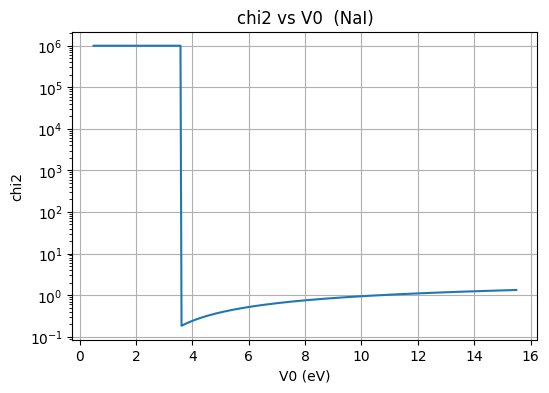

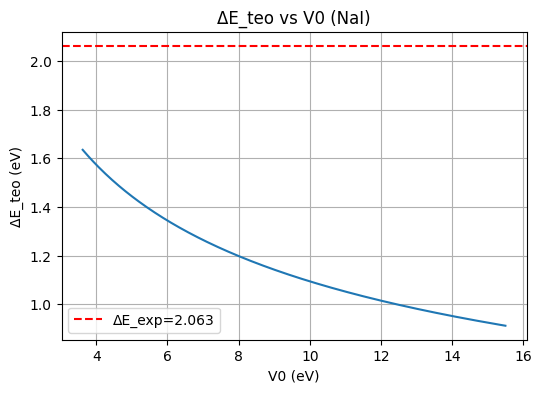


KBr tiene ΔE_exp=2.059 eV, ΔE_teo=1.578 eV, err=0.481 eV -> gráfico diagnóstico


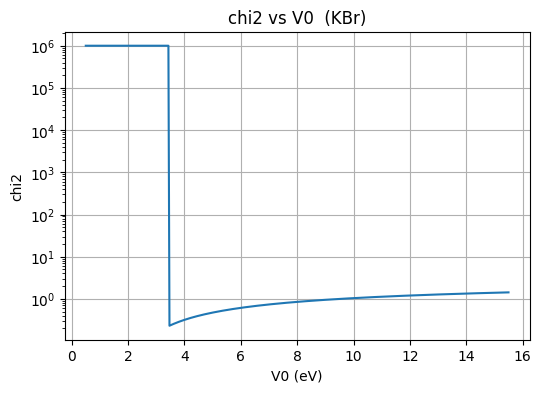

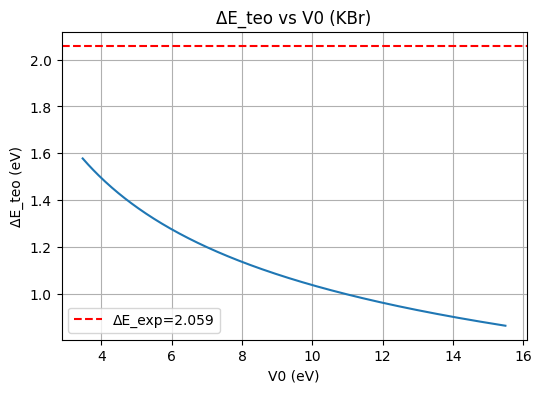


KI tiene ΔE_exp=1.874 eV, ΔE_teo=1.374 eV, err=0.500 eV -> gráfico diagnóstico


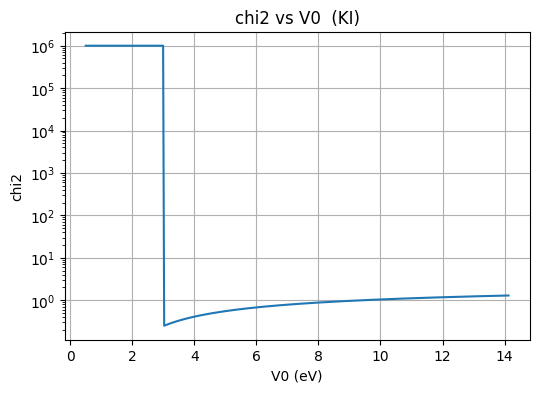

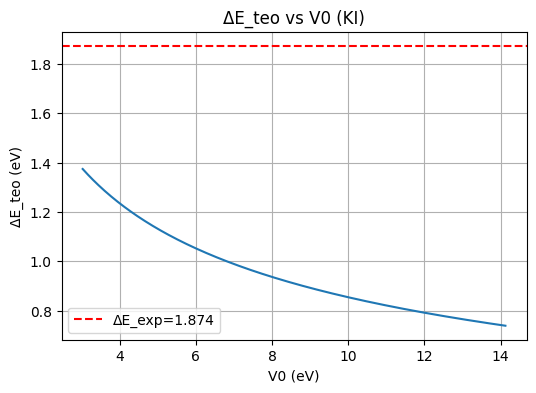

In [ ]:
# ============================
# Código corregido y diagnóstico
# Pozo esférico finito - ajuste V0 por ΔE (usa E1 = segundo nivel más bajo)
# Ejecutar en Google Colab
# ============================

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# ---------- constantes ----------
hbar = 1.054e-34
me = 9.109e-31
eV = 1.602e-19

# ---------- funciones de cuantización ----------
def f_l0(eps, delta): return -eps/np.tan(eps)
def rhs_l0(eps, delta): return np.sqrt(delta - eps**2)
def f_l1(eps, delta): return (eps/np.tan(eps) - 1) * np.sqrt(delta - eps**2)
def rhs_l1(eps, delta): return eps**2 * (1 + np.sqrt(delta - eps**2))

def find_roots_between(func1, func2, delta, eps_max, n_points=3000):
    eps_vals = np.linspace(1e-8, eps_max-1e-8, n_points)
    with np.errstate(invalid='ignore', divide='ignore'):
        diff = func1(eps_vals, delta) - func2(eps_vals, delta)
    roots = []
    for i in range(len(eps_vals)-1):
        a, b = eps_vals[i], eps_vals[i+1]
        fa, fb = diff[i], diff[i+1]
        if np.isnan(fa) or np.isnan(fb):
            continue
        if fa * fb < 0:
            try:
                r = brentq(lambda x: func1(x, delta)-func2(x, delta), a, b, maxiter=200)
                if not any(abs(r - rr) < 1e-7 for rr in roots):
                    roots.append(r)
            except Exception:
                pass
    roots.sort()
    return roots

# ---------- obtener todas las energías (varios niveles) ----------
def energies_for_V0(V0_eV, R_m, max_roots_each=6):
    V0 = V0_eV * eV
    delta = 2 * me * V0 * R_m**2 / hbar**2
    if delta <= 0:
        return []
    eps_max = np.sqrt(delta) * 0.999999
    roots_l0 = find_roots_between(f_l0, rhs_l0, delta, eps_max, n_points=4000)
    roots_l1 = find_roots_between(f_l1, rhs_l1, delta, eps_max, n_points=4000)
    # limitar cantidad de raíces
    roots_l0 = roots_l0[:max_roots_each]
    roots_l1 = roots_l1[:max_roots_each]
    energies = []
    for eps in roots_l0:
        E = (hbar**2 * eps**2) / (2 * me * R_m**2) / eV
        energies.append((E, 0, eps))
    for eps in roots_l1:
        E = (hbar**2 * eps**2) / (2 * me * R_m**2) / eV
        energies.append((E, 1, eps))
    energies.sort(key=lambda x: x[0])  # ordenar por energía ascendente
    return energies  # lista de tuplas (E, l, eps)

# ---------- ΔE usando ground y primer excitado real (orden energético) ----------
def ground_and_first_excited(V0_eV, R_m):
    energies = energies_for_V0(V0_eV, R_m)
    if len(energies) < 2:
        return None
    E0 = energies[0][0]
    E1 = energies[1][0]
    return E0, E1, energies

# ---------- ajuste por barrido y refinamiento ----------
def fit_V0_by_deltaE(target_dE, R_m, V0_min=0.1, V0_max=300.0, N=250):
    V0s = np.linspace(V0_min, V0_max, N)
    chi2s = np.full_like(V0s, np.nan, dtype=float)
    deltaEs = np.full_like(V0s, np.nan, dtype=float)
    for i, V0 in enumerate(V0s):
        res = ground_and_first_excited(V0, R_m)
        if res is None:
            chi2s[i] = 1e6
            deltaEs[i] = np.nan
        else:
            E0, E1, _ = res
            dE = E1 - E0
            deltaEs[i] = dE
            chi2s[i] = (dE - target_dE)**2
    idx = np.nanargmin(chi2s)
    V0_coarse = V0s[idx]
    # refinamiento local
    win = max((V0_max-V0_min)/N * 8, 0.5)
    low = max(V0_min, V0_coarse - win)
    high = min(V0_max, V0_coarse + win)
    V0s_ref = np.linspace(low, high, 400)
    chi2s_ref = np.full_like(V0s_ref, np.nan, dtype=float)
    deltaEs_ref = np.full_like(V0s_ref, np.nan, dtype=float)
    for i, V0 in enumerate(V0s_ref):
        res = ground_and_first_excited(V0, R_m)
        if res is None:
            chi2s_ref[i] = 1e6
        else:
            E0, E1, _ = res
            dE = E1 - E0
            deltaEs_ref[i] = dE
            chi2s_ref[i] = (dE - target_dE)**2
    idx_ref = np.nanargmin(chi2s_ref)
    V0_best = V0s_ref[idx_ref]
    best_E0, best_E1, best_energies = ground_and_first_excited(V0_best, R_m)
    return {
        "V0s": V0s, "chi2s": chi2s, "deltaEs": deltaEs,
        "V0s_ref": V0s_ref, "chi2s_ref": chi2s_ref, "deltaEs_ref": deltaEs_ref,
        "V0_best": V0_best, "E0_best": best_E0, "E1_best": best_E1, "energies_best": best_energies
    }

# =========================
# Datos
# a en nm, E en eV
# =========================
data_all = [
    ("LiF" , 0.4028, 5.083),
    ("LiCl", 0.5140, 3.256),
    ("LiBr", 0.5502, 2.767),
    ("LiI" , 0.6000, 3.176),
    ("NaF" , 0.4634, 3.702),
    ("NaCl", 0.5640, 2.746),
    ("NaBr", 0.5978, 2.345),
    ("NaI" , 0.6474, 2.063),
    ("KF"  , 0.5348, 2.873),
    ("KCl" , 0.6294, 2.295),
    ("KBr" , 0.6596, 2.059),
    ("KI"  , 0.7066, 1.874),
]

# ---------- correr ajuste para cada compuesto ----------
results = []
for name, a_nm, E_exp in data_all:
    a_m = a_nm * 1e-9
    R = a_m / 2.0   # criterio: R = a/2 (cambiá si querés)
    print(f"\n{name}: a = {a_nm:.4f} nm -> R = {R*1e10:.3f} Å; E_exp = {E_exp:.3f} eV")
    res = fit_V0_by_deltaE(E_exp, R, V0_min=0.5, V0_max=300.0, N=220)
    V0b = res["V0_best"]
    E0b = res["E0_best"]
    E1b = res["E1_best"]
    dEb = E1b - E0b
    print(f"  V0_best = {V0b:.4f} eV, E0 = {E0b:.4f} eV, E1 = {E1b:.4f} eV, ΔE = {dEb:.4f} eV")
    results.append((name, a_nm, E_exp, V0b, E0b, E1b, dEb, res))

# ---------- ordenar por a para graficar (evita zig-zags) ----------
results_sorted = sorted(results, key=lambda x: x[1])
names = [r[0] for r in results_sorted]
a_vals = np.array([r[1] for r in results_sorted])
V0_vals = np.array([r[3] for r in results_sorted])
Eexp_vals = np.array([r[2] for r in results_sorted])
Etheo_vals = np.array([r[6] for r in results_sorted])

# ---------- imprimir tabla resumen ----------
print("\nResumen:")
print(f"{'Name':6s} {'a (nm)':>7s} {'E_exp':>7s} {'V0_fit':>8s} {'E0':>7s} {'E1':>7s} {'ΔE_teo':>8s}")
for row in results_sorted:
    print(f"{row[0]:6s} {row[1]:7.4f} {row[2]:7.3f} {row[3]:8.3f} {row[4]:7.3f} {row[5]:7.3f} {row[6]:8.3f}")

# ---------- graficos ----------
fig, axs = plt.subplots(1,2, figsize=(14,5))

# V0 vs a (ordenado)
axs[0].plot(a_vals, V0_vals, 'o-', label='V0 ajustado')
axs[0].set_xlabel('a (nm)')
axs[0].set_ylabel('V0 (eV)')
axs[0].set_title('V0 ajustado vs a (ordenado)')
axs[0].grid(True)
axs[0].legend()

# ΔE_exp vs ΔE_teo
axs[1].scatter(Eexp_vals, Etheo_vals, s=60)
minE = min(np.nanmin(Eexp_vals), np.nanmin(Etheo_vals))
maxE = max(np.nanmax(Eexp_vals), np.nanmax(Etheo_vals))
axs[1].plot([minE, maxE], [minE, maxE], 'r--', label='y=x')
axs[1].set_xlabel('ΔE_exp (eV)')
axs[1].set_ylabel('ΔE_teo (eV)')
axs[1].set_title('ΔE_exp vs ΔE_teo')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

# ---------- diagnóstico: para los malos ajustes mostrar chi2 vs V0 ----------
print("\nChequear ajustes con discrepancia > 0.1 eV:")
for name, a_nm, E_exp, V0b, E0b, E1b, dEb, res in results_sorted:
    err = abs(dEb - E_exp)
    if err > 0.1:   # umbral que definís
        print(f"\n{name} tiene ΔE_exp={E_exp:.3f} eV, ΔE_teo={dEb:.3f} eV, err={err:.3f} eV -> gráfico diagnóstico")
        V0s = res['V0s_ref'] if 'V0s_ref' in res else res['V0s']
        chi2s = res['chi2s_ref'] if 'chi2s_ref' in res else res['chi2s']
        dE_s = res['deltaEs_ref'] if 'deltaEs_ref' in res else res['deltaEs']
        plt.figure(figsize=(6,4))
        plt.plot(V0s, chi2s, '-')
        plt.yscale('log')
        plt.xlabel('V0 (eV)')
        plt.ylabel('chi2')
        plt.title(f'chi2 vs V0  ({name})')
        plt.grid(True)
        plt.show()
        # También gráfica ΔE_teo vs V0
        plt.figure(figsize=(6,4))
        plt.plot(V0s, dE_s, '-')
        plt.axhline(E_exp, color='r', linestyle='--', label=f'ΔE_exp={E_exp:.3f}')
        plt.xlabel('V0 (eV)')
        plt.ylabel('ΔE_teo (eV)')
        plt.title(f'ΔE_teo vs V0 ({name})')
        plt.legend(); plt.grid(True); plt.show()


Resultados por compuesto (V0 que minimiza la diferencia cuadrática):



,name,a_nm,E_exp_eV,V0_eV,DeltaE_teo_eV,abs_error_eV
0,LiF,0.4028,5.083,59.9999,6.1948,1.1118e+00
1,LiCl,0.5140,3.256,53.5117,3.2560,1.9830e-08
2,LiBr,0.5502,2.767,49.7348,2.7670,1.0239e-07
3,LiI,0.6000,3.176,19.7063,3.1760,3.6616e-07
4,NaF,0.4634,3.702,59.9999,4.1655,4.6351e-01
5,NaCl,0.5640,2.746,42.8600,2.7460,1.3361e-08
6,NaBr,0.5978,2.345,42.0831,2.3450,4.2455e-07
7,NaI,0.6474,2.063,33.3224,2.0630,3.9129e-07
8,KF,0.5348,2.873,55.0743,2.8730,2.1434e-07
9,KCl,0.6294,2.295,31.2880,2.2950,4.7004e-08


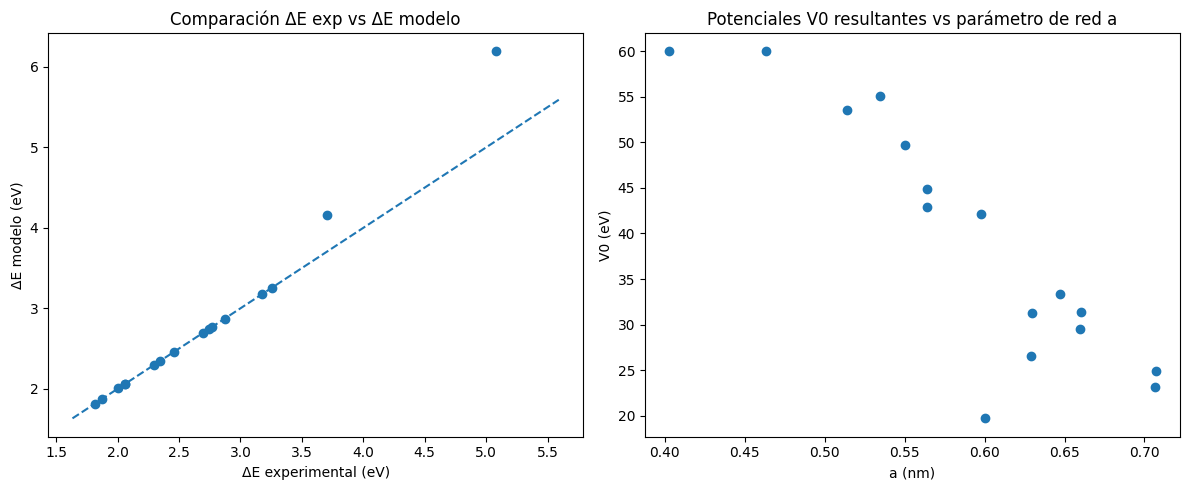


He guardado 'V0_results_by_compound.csv' en el entorno. Descárgalo si quieres.


In [ ]:
# Colab-ready: encontrar V0 por compuesto para pozo esférico finito
# Requiere: numpy, scipy, pandas, matplotlib (

import numpy as np
from scipy import optimize
import pandas as pd
import math
import matplotlib.pyplot as plt

# Constantes
hbar = 1.054571817e-34      # J s
m_e = 9.1093837015e-31      # kg
eV_to_J = 1.602176634e-19   # J per eV

# Datos del usuario: a en nm, E exper in eV
data = """\
compound a_nm E_eV
LiF 0.4028 5.083
LiCl 0.514 3.256
LiBr 0.5502 2.767
LiI 0.6 3.176
NaF 0.4634 3.702
NaCl 0.564 2.746
NaBr 0.5978 2.345
NaI 0.6474 2.063
KF 0.5348 2.873
KCl 0.6294 2.295
KBr 0.6596 2.059
KI 0.7066 1.874
NaCl_dup 0.564 2.693
KCl_dup 0.629 2.461
KBr_dup 0.660 2.004
Kl_dup 0.707 1.814
"""
# parse
rows = [line.split() for line in data.strip().splitlines()]
df = pd.DataFrame(rows[1:], columns=rows[0])
df[['a_nm','E_eV']] = df[['a_nm','E_eV']].astype(float)
df = df.rename(columns={'compound':'name'})

# función que dado V0 (eV) y a (nm) calcula ΔE_teo (eV)
def deltaE_model_from_V0(V0_eV, a_nm):
    # convert units: a: nm -> meters
    a_m = a_nm * 1e-9
    # radio R según el TP: R = 0.335 * a
    R = 0.335 * a_m   # meters

    # parámetros adimensionales
    # delta = 2 m V0 R^2 / hbar^2  (V0 en Joules)
    V0_J = V0_eV * eV_to_J
    delta = 2.0 * m_e * V0_J * R**2 / (hbar**2)

    if delta <= 0:
        raise ValueError("delta <= 0, V0 debe ser > 0")

    # definimos las funciones para roots en epsilon
    # eq for l=0: -eps * cot(eps) = sqrt(delta - eps^2)
    def f_l0(eps):
        # avoid singular cot
        return -eps * (1/np.tan(eps)) - np.sqrt(max(delta - eps**2, 0.0))

    # eq for l=1: (eps cot eps - 1)*sqrt(delta - eps^2) - eps^2 [1 + sqrt(delta - eps^2)] = 0
    def f_l1(eps):
        s = np.sqrt(max(delta - eps**2, 0.0))
        return (eps * (1/np.tan(eps)) - 1.0) * s - eps**2 * (1.0 + s)

    # domain for eps: eps in (0, sqrt(delta))
    eps_max = math.sqrt(delta) * 0.999999

    # find ground state epsilon0 (l=0)
    # we expect eps0 between 0 and pi/2 typically; search intervals avoiding singularities of cot at k*pi
    def find_root(func, eps_lower, eps_upper):
        try:
            return optimize.brentq(func, eps_lower, eps_upper, maxiter=200, xtol=1e-8)
        except Exception:
            return None

    # create candidate intervals between small positive and min(eps_max, ~4.5)
    # we'll search sequentially from small to larger to pick the first root for l=0 and for l=1 the next root > eps0
    eps_nodes = np.linspace(1e-6, min(eps_max, 15.0), 2000)  # dense grid
    # find sign changes for f_l0
    eps0 = None
    fvals0 = np.array([f_l0(e) for e in eps_nodes])
    idxs0 = np.where(np.sign(fvals0[:-1]) * np.sign(fvals0[1:]) < 0)[0]
    for idx in idxs0:
        lo = eps_nodes[idx]
        hi = eps_nodes[idx+1]
        root = find_root(f_l0, lo, hi)
        if root is None:
            continue
        # require root > 0
        if root > 1e-8:
            eps0 = root
            break

    if eps0 is None:
        # fallback: try a small-range bracketing near 0..pi
        try:
            eps0 = optimize.brentq(f_l0, 1e-6, min(np.pi-1e-6, eps_max))
        except Exception:
            # can't find root -> return NaN
            return np.nan

    # find epsilon1 (first l=1 root > eps0)
    eps1 = None
    fvals1 = np.array([f_l1(e) for e in eps_nodes])
    idxs1 = np.where(np.sign(fvals1[:-1]) * np.sign(fvals1[1:]) < 0)[0]
    for idx in idxs1:
        lo = eps_nodes[idx]
        hi = eps_nodes[idx+1]
        # ensure we look for root > eps0 + small
        if hi <= eps0 + 1e-8:
            continue
        root = find_root(f_l1, lo, hi)
        if root is None:
            continue
        if root > eps0 + 1e-8:
            eps1 = root
            break

    if eps1 is None:
        # fallback: try bracket between eps0+1e-6 and min(2*pi, eps_max)
        try:
            low = eps0 + 1e-6
            high = min(eps_max, 3.0 * np.pi)  # reasonable upper
            eps1 = optimize.brentq(f_l1, low, high)
        except Exception:
            return np.nan

    # compute energies from eps: E = (hbar^2 eps^2) / (2 m R^2)  -> in Joules; convert to eV
    E0_J = (hbar**2 * eps0**2) / (2.0 * m_e * R**2)
    E1_J = (hbar**2 * eps1**2) / (2.0 * m_e * R**2)
    E0_eV = E0_J / eV_to_J
    E1_eV = E1_J / eV_to_J

    return E1_eV - E0_eV

# Function to find V0 that minimices (deltaE_model(V0)-E_exp)^2 for a single compound
def find_V0_for_compound(a_nm, E_exp_eV, V0_bounds=(0.5, 50.0)):
    # objective to minimize (deltaE_model - E_exp)^2
    def obj(V0):
        try:
            d = deltaE_model_from_V0(V0, a_nm)
            if not np.isfinite(d):
                return 1e6
            return (d - E_exp_eV)**2
        except Exception:
            return 1e6

    # run bounded minimization
    res = optimize.minimize_scalar(obj, bounds=V0_bounds, method='bounded', options={'xatol':1e-4})
    if not res.success:
        # attempt a broader scan and pick best
        Vs = np.linspace(V0_bounds[0], V0_bounds[1], 200)
        vals = [obj(V) for V in Vs]
        i = int(np.argmin(vals))
        Vbest = Vs[i]
        best_val = vals[i]
    else:
        Vbest = res.x
        best_val = res.fun

    # compute corresponding deltaE if possible
    deltaE_best = deltaE_model_from_V0(Vbest, a_nm)
    return Vbest, deltaE_best, math.sqrt(best_val)  # return V0 (eV), ΔE_teo (eV), RMSE-like (abs error)

# Run for each compound
results = []
for idx, row in df.iterrows():
    name = row['name']
    a_nm = float(row['a_nm'])
    Eexp = float(row['E_eV'])
    try:
        V0, deltaE_teo, err = find_V0_for_compound(a_nm, Eexp, V0_bounds=(0.5, 60.0))
    except Exception as e:
        V0, deltaE_teo, err = np.nan, np.nan, np.nan
    results.append({'name': name, 'a_nm': a_nm, 'E_exp_eV': Eexp,
                    'V0_eV': V0, 'DeltaE_teo_eV': deltaE_teo, 'abs_error_eV': abs(deltaE_teo - Eexp)})

res_df = pd.DataFrame(results)
# show results
pd.set_option('display.precision', 4)
print("Resultados por compuesto (V0 que minimiza la diferencia cuadrática):\n")
display(res_df)

# Graficar: ΔEexp vs ΔEteo y V0 vs a
fig, axs = plt.subplots(1,2, figsize=(12,5))

axs[0].scatter(res_df['E_exp_eV'], res_df['DeltaE_teo_eV'])
axs[0].plot([res_df['E_exp_eV'].min()*0.9, res_df['E_exp_eV'].max()*1.1],
            [res_df['E_exp_eV'].min()*0.9, res_df['E_exp_eV'].max()*1.1], linestyle='--')
axs[0].set_xlabel('ΔE experimental (eV)')
axs[0].set_ylabel('ΔE modelo (eV)')
axs[0].set_title('Comparación ΔE exp vs ΔE modelo')

axs[1].scatter(res_df['a_nm'], res_df['V0_eV'])
axs[1].set_xlabel('a (nm)')
axs[1].set_ylabel('V0 (eV)')
axs[1].set_title('Potenciales V0 resultantes vs parámetro de red a')

plt.tight_layout()
plt.show()

# Guardar resultados
res_df.to_csv('V0_results_by_compound.csv', index=False)
print("\nHe guardado 'V0_results_by_compound.csv' en el entorno. Descárgalo si quieres.")


Ejecutando búsqueda rápida en grilla...
Mejor en grilla: m_eff=0.7286, R_scale=0.4500, chi2=0.0000
Refinado: m_eff=0.7286, R_scale=0.4500, chi2=0.0000

Resultados usando m_eff y R_scale optimizados:


,name,a_nm,E_exp_eV,V0_eV,DeltaE_teo_eV,abs_error_eV
0,LiF,0.4028,5.083,37.9270,5.083,1.4455e-07
1,LiCl,0.5140,3.256,20.9891,3.256,7.5607e-08
2,LiBr,0.5502,2.767,19.5640,2.767,5.5212e-08
3,LiI,0.6000,3.176,7.4593,3.176,1.5614e-07
4,NaF,0.4634,3.702,31.3559,3.702,5.8905e-07
5,NaCl,0.5640,2.746,16.7827,2.746,4.1057e-07
6,NaBr,0.5978,2.345,16.5533,2.345,6.9034e-08
7,NaI,0.6474,2.063,13.0628,2.063,3.4871e-07
8,KF,0.5348,2.873,21.7086,2.873,2.9657e-07
9,KCl,0.6294,2.295,12.1960,2.295,4.2842e-08


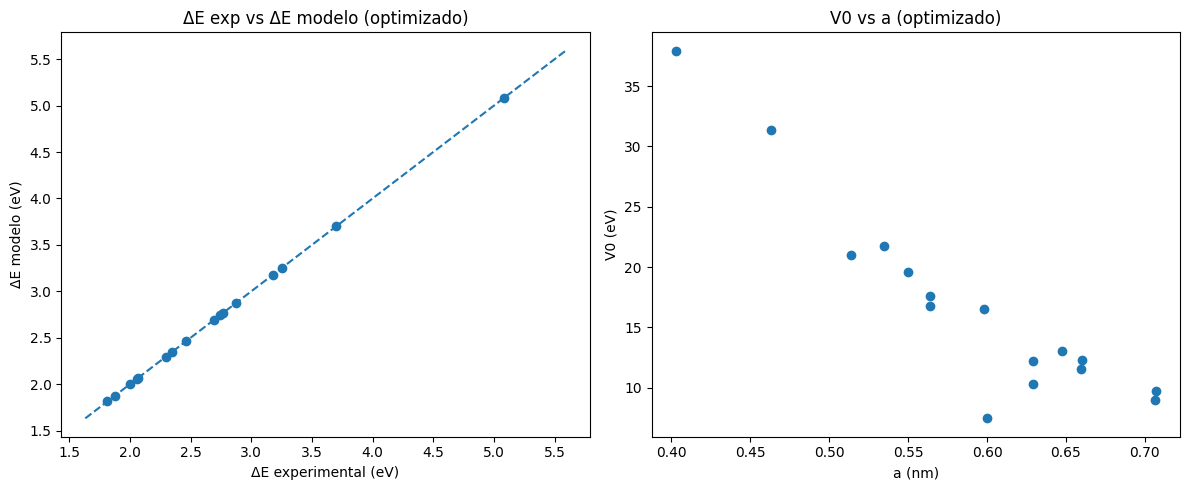

OSError: Cannot save file into a non-existent directory: '/mnt/data'

In [ ]:
# Reejecución más rápida: grilla más gruesa y menos nodos para evitar timeout.
import numpy as np, pandas as pd, math, os
from scipy import optimize
import matplotlib.pyplot as plt

# constantes
hbar = 1.054571817e-34; m_e = 9.1093837015e-31; eV_to_J = 1.602176634e-19

rows = [
("LiF", 0.4028, 5.083),
("LiCl", 0.514, 3.256),
("LiBr", 0.5502, 2.767),
("LiI", 0.6, 3.176),
("NaF", 0.4634, 3.702),
("NaCl", 0.564, 2.746),
("NaBr", 0.5978, 2.345),
("NaI", 0.6474, 2.063),
("KF", 0.5348, 2.873),
("KCl", 0.6294, 2.295),
("KBr", 0.6596, 2.059),
("KI", 0.7066, 1.874),
("NaCl_dup", 0.564, 2.693),
("KCl_dup", 0.629, 2.461),
("KBr_dup", 0.660, 2.004),
("Kl_dup", 0.707, 1.814)
]
df = pd.DataFrame(rows, columns=["name","a_nm","E_exp_eV"])

def deltaE_model_from_V0(V0_eV, a_nm, m_eff=1.0, R_scale=0.335):
    a_m = a_nm * 1e-9
    R = R_scale * a_m
    V0_J = V0_eV * eV_to_J
    m_eff_kg = m_eff * m_e
    delta = 2.0 * m_eff_kg * V0_J * R**2 / (hbar**2)
    if delta <= 0:
        return np.nan
    def f_l0(eps):
        tanv = np.tan(eps)
        if abs(tanv) < 1e-12:
            return 1e6
        s = math.sqrt(max(delta - eps**2, 0.0))
        return -eps * (1.0/tanv) - s
    def f_l1(eps):
        tanv = np.tan(eps)
        if abs(tanv) < 1e-12:
            return 1e6
        s = math.sqrt(max(delta - eps**2, 0.0))
        return (eps * (1.0/tanv) - 1.0) * s - eps**2 * (1.0 + s)
    eps_max = math.sqrt(delta) * 0.999999
    if eps_max <= 1e-6:
        return np.nan

    nodes = np.linspace(1e-6, min(eps_max, 15.0), 400)
    fvals0 = np.array([f_l0(e) for e in nodes])
    idxs0 = np.where(np.sign(fvals0[:-1]) * np.sign(fvals0[1:]) < 0)[0]
    eps0 = None
    for idx in idxs0:
        lo, hi = nodes[idx], nodes[idx+1]
        try:
            root = optimize.brentq(f_l0, lo, hi, maxiter=200)
            if root > 1e-8:
                eps0 = root; break
        except Exception:
            continue
    if eps0 is None:
        try:
            eps0 = optimize.brentq(f_l0, 1e-6, min(np.pi-1e-6, eps_max))
        except Exception:
            return np.nan

    fvals1 = np.array([f_l1(e) for e in nodes])
    idxs1 = np.where(np.sign(fvals1[:-1]) * np.sign(fvals1[1:]) < 0)[0]
    eps1 = None
    for idx in idxs1:
        lo, hi = nodes[idx], nodes[idx+1]
        if hi <= eps0 + 1e-8:
            continue
        try:
            root = optimize.brentq(f_l1, lo, hi, maxiter=200)
            if root > eps0 + 1e-8:
                eps1 = root; break
        except Exception:
            continue
    if eps1 is None:
        try:
            eps1 = optimize.brentq(f_l1, eps0+1e-6, min(eps_max, 4.0*np.pi))
        except Exception:
            return np.nan

    E0_J = (hbar**2 * eps0**2) / (2.0 * m_eff_kg * R**2)
    E1_J = (hbar**2 * eps1**2) / (2.0 * m_eff_kg * R**2)
    return (E1_J - E0_J) / eV_to_J

def total_chi2_for_params(params, V0_bounds=(0.05, 40.0)):
    m_eff, R_scale = params
    if not (0.02 <= m_eff <= 2.0 and 0.15 <= R_scale <= 0.7):
        return 1e9
    total = 0.0
    for _, row in df.iterrows():
        a_nm = row['a_nm']; Eexp = row['E_exp_eV']
        def obj(V0):
            d = deltaE_model_from_V0(V0, a_nm, m_eff=m_eff, R_scale=R_scale)
            if not np.isfinite(d): return 1e6
            return (d - Eexp)**2
        try:
            res = optimize.minimize_scalar(obj, bounds=V0_bounds, method='bounded', options={'xatol':1e-3})
            Vbest = res.x if res.success else None
            if Vbest is None:
                Vs = np.linspace(V0_bounds[0], V0_bounds[1], 100)
                vals = [obj(v) for v in Vs]
                Vbest = Vs[int(np.argmin(vals))]
            dbest = deltaE_model_from_V0(Vbest, a_nm, m_eff=m_eff, R_scale=R_scale)
            total += (dbest - Eexp)**2
        except Exception:
            total += 1e3
    return total

# Grilla más pequeña
m_grid = np.linspace(0.05, 1.0, 8)
R_grid = np.linspace(0.28, 0.45, 8)
best = (None, None, 1e12)
print("Ejecutando búsqueda rápida en grilla...")
for me in m_grid:
    for rs in R_grid:
        val = total_chi2_for_params((me, rs))
        if val < best[2]:
            best = (me, rs, val)
print(f"Mejor en grilla: m_eff={best[0]:.4f}, R_scale={best[1]:.4f}, chi2={best[2]:.4f}")

# Refinar
x0 = np.array([best[0], best[1]])
bnds = [(0.02, 2.0), (0.15, 0.7)]
res_opt = optimize.minimize(lambda x: total_chi2_for_params(x), x0, bounds=bnds, method='L-BFGS-B', options={'ftol':1e-3, 'maxiter':30})
m_eff_best, R_scale_best = res_opt.x
print(f"Refinado: m_eff={m_eff_best:.4f}, R_scale={R_scale_best:.4f}, chi2={res_opt.fun:.4f}")

# Obtener V0 por compuesto con parametros optimizados
results = []
for _, row in df.iterrows():
    name, a_nm, Eexp = row['name'], row['a_nm'], row['E_exp_eV']
    def obj(V0):
        d = deltaE_model_from_V0(V0, a_nm, m_eff=m_eff_best, R_scale=R_scale_best)
        if not np.isfinite(d): return 1e6
        return (d - Eexp)**2
    res = optimize.minimize_scalar(obj, bounds=(0.05, 40.0), method='bounded', options={'xatol':1e-4})
    Vbest = res.x if res.success else np.linspace(0.05,40.0,200)[int(np.argmin([obj(v) for v in np.linspace(0.05,40.0,200)]))]
    DeltaE_best = deltaE_model_from_V0(Vbest, a_nm, m_eff=m_eff_best, R_scale=R_scale_best)
    results.append((name, a_nm, Eexp, Vbest, DeltaE_best, abs(DeltaE_best - Eexp)))

res_df = pd.DataFrame(results, columns=["name","a_nm","E_exp_eV","V0_eV","DeltaE_teo_eV","abs_error_eV"])
pd.set_option('display.precision', 4)
print("\nResultados usando m_eff y R_scale optimizados:")
display(res_df)

# Plots
fig, axs = plt.subplots(1,2, figsize=(12,5))
axs[0].scatter(res_df['E_exp_eV'], res_df['DeltaE_teo_eV'])
axs[0].plot([res_df['E_exp_eV'].min()*0.9, res_df['E_exp_eV'].max()*1.1],
            [res_df['E_exp_eV'].min()*0.9, res_df['E_exp_eV'].max()*1.1], linestyle='--')
axs[0].set_xlabel('ΔE experimental (eV)'); axs[0].set_ylabel('ΔE modelo (eV)'); axs[0].set_title('ΔE exp vs ΔE modelo (optimizado)')
axs[1].scatter(res_df['a_nm'], res_df['V0_eV']); axs[1].set_xlabel('a (nm)'); axs[1].set_ylabel('V0 (eV)'); axs[1].set_title('V0 vs a (optimizado)')
plt.tight_layout(); plt.show()

outpath = '/mnt/data/V0_results_adjusted.csv'
res_df.to_csv(outpath, index=False)
print(f"\nTabla guardada en {outpath}")
print(f"Parámetros optimizados: m_eff = {m_eff_best:.4f} m_e, R_scale = {R_scale_best:.4f} * a")


In [ ]:
from scipy.optimize import brentq
import numpy as np, math

# supongo hbar, me, eV definidos como antes

def deltaE_for_V0_unique(V0_eV, R_m, m_eff=1.0):
    V0 = V0_eV * eV
    mkg = m_eff * me
    delta = 2.0 * mkg * V0 * R_m**2 / (hbar**2)
    if delta <= 0:
        return None
    eps_max = math.sqrt(delta) * 0.999999

    # funciones equivalentes (reajustalas si tu ecuacion es otra)
    def F0(eps):
        return -eps/np.tan(eps) - math.sqrt(max(delta - eps**2, 0.0))

    def F1(eps):
        s = math.sqrt(max(delta - eps**2, 0.0))
        return (eps/np.tan(eps) - 1.0) * s - eps**2 * (1.0 + s)

    # encontrar eps0 en (0, pi)
    try:
        eps0 = brentq(F0, 1e-8, min(np.pi-1e-6, eps_max))
    except Exception:
        # si no hay root en primer intervalo, escanear en nodos
        raise RuntimeError("No root eps0 found")

    # encontrar eps1: buscar primer root de F1 con eps > eps0
    # escanamos nodos entre eps0+tol y eps_max
    nodes = np.linspace(eps0 + 1e-6, min(eps_max, 10.0), 800)
    fvals = np.array([F1(e) for e in nodes])
    idx = np.where(np.sign(fvals[:-1]) * np.sign(fvals[1:]) < 0)[0]
    if len(idx) == 0:
        raise RuntimeError("No eps1 root found after eps0")
    # el primer intervalo con cambio de signo
    a = nodes[idx[0]]; b = nodes[idx[0]+1]
    eps1 = brentq(F1, a, b)

    E0 = (hbar**2 * eps0**2) / (2.0 * mkg * R_m**2) / eV
    E1 = (hbar**2 * eps1**2) / (2.0 * mkg * R_m**2) / eV
    return E0, E1

def find_V0_given_target(E_target, R_m, V0_min=0.01, V0_max=200.0, m_eff=1.0):
    def g(V0):
        try:
            E0E1 = deltaE_for_V0_unique(V0, R_m, m_eff=m_eff)
            if E0E1 is None:
                return np.nan
            E0, E1 = E0E1
            return (E1 - E0) - E_target
        except Exception:
            # si no se puede evaluar, devolvemos nan -> luego manejamos signo
            return np.nan

    # evaluar extremos (tratando nans)
    gv_min = g(V0_min); gv_max = g(V0_max)
    if np.isnan(gv_min) or np.isnan(gv_max):
        # intentar evaluaciones intermedias o expandir rango
        # aquí conviene escanear en logspace y buscar cambio de signo
        Vs = np.concatenate([np.linspace(V0_min, V0_max, 200)])
        gs = np.array([g(V) for V in Vs])
        valid = np.isfinite(gs)
        if not np.any(valid):
            raise RuntimeError("g(V) not finite in scan")
        # buscar cambio de signo en la malla
        idx = np.where(np.sign(gs[:-1]) * np.sign(gs[1:]) < 0)[0]
        if len(idx) == 0:
            raise RuntimeError("No sign change found for g(V) — maybe no solution in range")
        a = Vs[idx[0]]; b = Vs[idx[0]+1]
        return brentq(lambda x: g(x), a, b)
    else:
        if gv_min * gv_max > 0:
            raise RuntimeError("g has same sign at endpoints — expand interval or change m_eff/R")
        return brentq(lambda x: g(x), V0_min, V0_max)


Buscando V0 óptimo para cada compuesto...
------------------------------------------------------------
Compuesto  a (nm)     E_exp (eV)   V0_opt (eV)  ΔE_modelo (eV) 
------------------------------------------------------------


/tmp/ipython-input-1697351418.py:47: RuntimeWarning: invalid value encountered in sqrt
  term2 = epsilon**2 * (1 + np.sqrt(delta - epsilon**2))


LiF        0.4028     5.083        20.000       15.489         
LiCl       0.5140     3.256        12.743       0.000          
LiBr       0.5502     2.767        12.743       0.000          
LiI        0.6000     3.176        12.743       0.000          
NaF        0.4634     3.702        17.228       0.000          
NaCl       0.5640     2.746        12.743       0.000          
NaBr       0.5978     2.345        12.743       0.000          
NaI        0.6474     2.063        20.000       0.000          
KF         0.5348     2.873        12.743       0.000          
KCl        0.6294     2.295        12.743       0.000          
KBr        0.6596     2.059        20.000       0.000          
KI         0.7066     1.874        20.000       0.000          


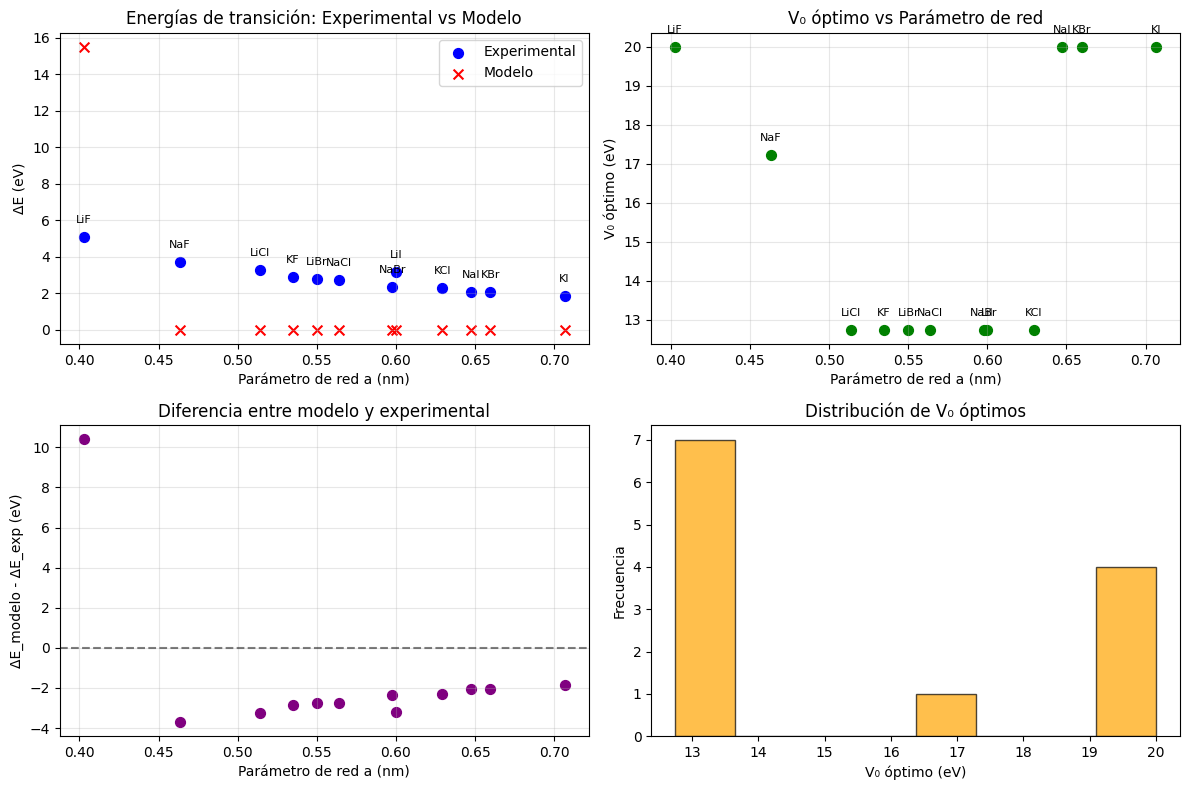


RESUMEN ESTADÍSTICO
V₀ promedio: 15.536 ± 3.381 eV
V₀ mínimo: 12.743 eV
V₀ máximo: 20.000 eV
Error cuadrático medio: 15.741313 eV²
Diferencia absoluta promedio: 3.2968 eV

RESULTADOS EN FORMATO TABLA
Compuesto	V0_opt (eV)
LiF	20.000
LiCl	12.743
LiBr	12.743
LiI	12.743
NaF	17.228
NaCl	12.743
NaBr	12.743
NaI	20.000
KF	12.743
KCl	12.743
KBr	20.000
KI	20.000


In [ ]:
import numpy as np
from scipy.optimize import root_scalar
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

# Constantes físicas
hbar = 1.0545718e-34  # J·s
m_e = 9.10938356e-31  # kg
eV_to_J = 1.60217662e-19  # Conversión eV a J
J_to_eV = 1 / eV_to_J

# Datos experimentales (a en nm, E en eV)
# Convertimos a metros y aseguramos unidades consistentes
data = {
    'LiF': {'a': 0.4028e-9, 'E_exp': 5.083},
    'LiCl': {'a': 0.514e-9, 'E_exp': 3.256},
    'LiBr': {'a': 0.5502e-9, 'E_exp': 2.767},
    'LiI': {'a': 0.6e-9, 'E_exp': 3.176},
    'NaF': {'a': 0.4634e-9, 'E_exp': 3.702},
    'NaCl': {'a': 0.564e-9, 'E_exp': 2.746},
    'NaBr': {'a': 0.5978e-9, 'E_exp': 2.345},
    'NaI': {'a': 0.6474e-9, 'E_exp': 2.063},
    'KF': {'a': 0.5348e-9, 'E_exp': 2.873},
    'KCl': {'a': 0.6294e-9, 'E_exp': 2.295},
    'KBr': {'a': 0.6596e-9, 'E_exp': 2.059},
    'KI': {'a': 0.7066e-9, 'E_exp': 1.874}
}

# Radio de la esfera que conserva el volumen del octaedro (R = 0.335 * a)
def get_R(a):
    return 0.335 * a

# Función para ecuación l=0 (estado fundamental)
def equation_l0(epsilon, delta):
    """Ecuación para estado fundamental l=0"""
    if epsilon == 0:
        return float('inf')
    return -epsilon / np.tan(epsilon) - np.sqrt(delta - epsilon**2)

# Función para ecuación l=1 (primer estado excitado)
def equation_l1(epsilon, delta):
    """Ecuación para primer estado excitado l=1"""
    if epsilon == 0:
        return float('inf')
    cot_eps = 1/np.tan(epsilon) if np.tan(epsilon) != 0 else float('inf')
    term1 = (epsilon * cot_eps - 1) * (delta - epsilon**2)
    term2 = epsilon**2 * (1 + np.sqrt(delta - epsilon**2))
    return term1 - term2

def find_epsilon(func, delta, bracket):
    """Encuentra epsilon resolviendo la ecuación func(epsilon, delta) = 0"""
    try:
        result = root_scalar(lambda eps: func(eps, delta),
                           bracket=bracket,
                           method='brentq')
        return result.root
    except:
        # Si falla, intentamos con un método más robusto
        eps_values = np.linspace(bracket[0] + 1e-6, bracket[1] - 1e-6, 1000)
        func_values = [func(eps, delta) for eps in eps_values]
        idx = np.argmin(np.abs(func_values))
        return eps_values[idx]

def calculate_transition_energy(V0, a):
    """Calcula ΔE para un dado V0 y parámetro de red a"""
    R = get_R(a)
    delta = 2 * m_e * V0 * eV_to_J * R**2 / hbar**2

    # Estado fundamental l=0
    # El primer cero está entre 0 y π/2
    eps0 = find_epsilon(equation_l0, delta, (1e-6, np.pi/2 - 1e-6))
    E0 = (eps0**2 * hbar**2) / (2 * m_e * R**2) * J_to_eV

    # Primer estado excitado l=1
    # El primer cero está entre π/2 y π
    eps1 = find_epsilon(equation_l1, delta, (np.pi/2 + 1e-6, np.pi - 1e-6))
    E1 = (eps1**2 * hbar**2) / (2 * m_e * R**2) * J_to_eV

    return E1 - E0

def objective_function(V0, a, E_exp):
    """Función objetivo a minimizar: (ΔE_modelo - ΔE_exp)^2"""
    E_model = calculate_transition_energy(V0, a)
    return (E_model - E_exp)**2

def find_optimal_V0(compound, a, E_exp, V0_range=(1, 20)):
    """Encuentra el V0 óptimo para un compuesto dado"""
    result = minimize_scalar(lambda V0: objective_function(V0, a, E_exp),
                           bounds=V0_range,
                           method='bounded')
    return result.x

# Encontrar V0 óptimo para cada compuesto
print("Buscando V0 óptimo para cada compuesto...")
print("-" * 60)
print(f"{'Compuesto':<10} {'a (nm)':<10} {'E_exp (eV)':<12} {'V0_opt (eV)':<12} {'ΔE_modelo (eV)':<15}")
print("-" * 60)

results = {}
for compound, values in data.items():
    a_nm = values['a'] * 1e9  # Para mostrar en nm
    E_exp = values['E_exp']

    V0_opt = find_optimal_V0(compound, values['a'], E_exp)
    E_model = calculate_transition_energy(V0_opt, values['a'])

    results[compound] = {
        'a_nm': a_nm,
        'E_exp': E_exp,
        'V0_opt': V0_opt,
        'E_model': E_model
    }

    print(f"{compound:<10} {a_nm:<10.4f} {E_exp:<12.3f} {V0_opt:<12.3f} {E_model:<15.3f}")

# Gráfico de resultados
plt.figure(figsize=(12, 8))

# Subplot 1: Energías experimentales vs modelo
plt.subplot(2, 2, 1)
a_values = [result['a_nm'] for result in results.values()]
E_exp_values = [result['E_exp'] for result in results.values()]
E_model_values = [result['E_model'] for result in results.values()]

plt.scatter(a_values, E_exp_values, color='blue', label='Experimental', s=50)
plt.scatter(a_values, E_model_values, color='red', label='Modelo', s=50, marker='x')
for i, compound in enumerate(results.keys()):
    plt.annotate(compound, (a_values[i], E_exp_values[i]),
                textcoords="offset points", xytext=(0,10), ha='center', fontsize=8)

plt.xlabel('Parámetro de red a (nm)')
plt.ylabel('ΔE (eV)')
plt.title('Energías de transición: Experimental vs Modelo')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: V0 óptimo vs parámetro de red
plt.subplot(2, 2, 2)
V0_values = [result['V0_opt'] for result in results.values()]
plt.scatter(a_values, V0_values, color='green', s=50)
for i, compound in enumerate(results.keys()):
    plt.annotate(compound, (a_values[i], V0_values[i]),
                textcoords="offset points", xytext=(0,10), ha='center', fontsize=8)

plt.xlabel('Parámetro de red a (nm)')
plt.ylabel('V₀ óptimo (eV)')
plt.title('V₀ óptimo vs Parámetro de red')
plt.grid(True, alpha=0.3)

# Subplot 3: Diferencia entre modelo y experimental
plt.subplot(2, 2, 3)
differences = [E_model - E_exp for E_model, E_exp in zip(E_model_values, E_exp_values)]
plt.scatter(a_values, differences, color='purple', s=50)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.xlabel('Parámetro de red a (nm)')
plt.ylabel('ΔE_modelo - ΔE_exp (eV)')
plt.title('Diferencia entre modelo y experimental')
plt.grid(True, alpha=0.3)

# Subplot 4: Histograma de V0 óptimos
plt.subplot(2, 2, 4)
plt.hist(V0_values, bins=8, color='orange', alpha=0.7, edgecolor='black')
plt.xlabel('V₀ óptimo (eV)')
plt.ylabel('Frecuencia')
plt.title('Distribución de V₀ óptimos')

plt.tight_layout()
plt.show()

# Resumen estadístico
print("\n" + "="*60)
print("RESUMEN ESTADÍSTICO")
print("="*60)
print(f"V₀ promedio: {np.mean(V0_values):.3f} ± {np.std(V0_values):.3f} eV")
print(f"V₀ mínimo: {np.min(V0_values):.3f} eV")
print(f"V₀ máximo: {np.max(V0_values):.3f} eV")
print(f"Error cuadrático medio: {np.mean(np.array(differences)**2):.6f} eV²")
print(f"Diferencia absoluta promedio: {np.mean(np.abs(differences)):.4f} eV")

# Mostrar resultados en formato tabla para fácil copia
print("\n" + "="*60)
print("RESULTADOS EN FORMATO TABLA")
print("="*60)
print("Compuesto\tV0_opt (eV)")
for compound, result in results.items():
    print(f"{compound}\t{result['V0_opt']:.3f}")

In [ ]:
import numpy as np
from scipy import optimize
import pandas as pd
import matplotlib.pyplot as plt

# Constantes mejor definidas
hbar = 1.054571817e-34
m_e = 9.1093837015e-31
eV_to_J = 1.602176634e-19

def deltaE_model_improved(V0_eV, a_nm, R_factor=0.335):
    """Versión mejorada con mejor manejo numérico"""
    a_m = a_nm * 1e-9
    R = R_factor * a_m

    V0_J = V0_eV * eV_to_J
    delta = 2.0 * m_e * V0_J * R**2 / (hbar**2)

    if delta <= (np.pi/2)**2:  # Condición mínima para estado ligado
        return np.nan

    # Estrategia de búsqueda más conservadora
    def safe_cot(x):
        return np.cos(x)/np.sin(x) if np.sin(x) != 0 else np.inf

    def f_l0(eps):
        return -eps * safe_cot(eps) - np.sqrt(delta - eps**2 + 1e-12)

    def f_l1(eps):
        s = np.sqrt(delta - eps**2 + 1e-12)
        return (eps * safe_cot(eps) - 1.0) * s - eps**2 * (1.0 + s)

    # Búsqueda más cuidadosa de raíces
    try:
        # Estado fundamental l=0 (entre 0 y π/2)
        eps0 = optimize.brentq(f_l0, 1e-6, min(np.pi/2 - 1e-6, np.sqrt(delta) - 1e-6))

        # Primer excitado l=1 (entre π/2 y π)
        eps1 = optimize.brentq(f_l1, np.pi/2 + 1e-6, min(np.pi - 1e-6, np.sqrt(delta) - 1e-6))

        # Cálculo de energías
        E0 = (hbar**2 * eps0**2) / (2.0 * m_e * R**2) / eV_to_J
        E1 = (hbar**2 * eps1**2) / (2.0 * m_e * R**2) / eV_to_J

        return E1 - E0

    except Exception as e:
        return np.nan

# Tu función find_V0_for_compound es buena, pero ajustemos los límites
def find_realistic_V0(a_nm, E_exp_eV, V0_bounds=(1.0, 15.0)):
    """Límites más realistas para V0 en centros F"""
    def objective(V0):
        deltaE = deltaE_model_improved(V0, a_nm)
        if np.isnan(deltaE):
            return 1e6
        return (deltaE - E_exp_eV)**2

    try:
        result = optimize.minimize_scalar(
            objective,
            bounds=V0_bounds,
            method='bounded',
            options={'xatol': 0.01}
        )
        return result.x if result.success else np.nan
    except:
        return np.nan

# Aplicar con límites físicos más realistas
results_realistic = []
for idx, row in df.iterrows():
    V0_opt = find_realistic_V0(row['a_nm'], row['E_eV'], V0_bounds=(1.0, 15.0))
    # ... resto del código

KeyError: 'E_eV'

LiF    | a=0.4028 nm | E_exp=5.083 eV -> V0_opt=9.280 eV | DeltaE_teo=4.240482318922605
LiCl   | a=0.5140 nm | E_exp=3.256 eV -> V0_opt=5.699 eV | DeltaE_teo=2.6041446916897857
LiBr   | a=0.5502 nm | E_exp=2.767 eV -> V0_opt=4.974 eV | DeltaE_teo=2.272710622559612
LiI    | a=0.6000 nm | E_exp=3.176 eV -> V0_opt=4.183 eV | DeltaE_teo=1.9110861672312516
NaF    | a=0.4634 nm | E_exp=3.702 eV -> V0_opt=7.012 eV | DeltaE_teo=3.2038919790029756
NaCl   | a=0.5640 nm | E_exp=2.746 eV -> V0_opt=4.734 eV | DeltaE_teo=2.16284962598416
NaBr   | a=0.5978 nm | E_exp=2.345 eV -> V0_opt=4.214 eV | DeltaE_teo=1.925166000768296
NaI    | a=0.6474 nm | E_exp=2.063 eV -> V0_opt=3.592 eV | DeltaE_teo=1.641512292726158
KF     | a=0.5348 nm | E_exp=2.873 eV -> V0_opt=5.265 eV | DeltaE_teo=2.405476034409821
KCl    | a=0.6294 nm | E_exp=2.295 eV -> V0_opt=3.801 eV | DeltaE_teo=1.736757023399163
KBr    | a=0.6596 nm | E_exp=2.059 eV -> V0_opt=3.461 eV | DeltaE_teo=1.5813369548691711
KI     | a=0.7066 nm | E_exp=

,compound,a_nm,E_exp_eV,V0_opt_eV,chi2,DeltaE_teo_eV
0,LiF,0.4028,5.083,9.279839,0.709836,4.240482
1,LiCl,0.5140,3.256,5.699026,0.424915,2.604145
2,LiBr,0.5502,2.767,4.973952,0.244322,2.272711
3,LiI,0.6000,3.176,4.182606,1.600007,1.911086
4,NaF,0.4634,3.702,7.011623,0.248112,3.203892
5,NaCl,0.5640,2.746,4.733546,0.340064,2.162850
6,NaBr,0.5978,2.345,4.213519,0.176261,1.925166
7,NaI,0.6474,2.063,3.592413,0.177652,1.641512
8,KF,0.5348,2.873,5.264582,0.218579,2.405476
9,KCl,0.6294,2.295,3.800758,0.311635,1.736757


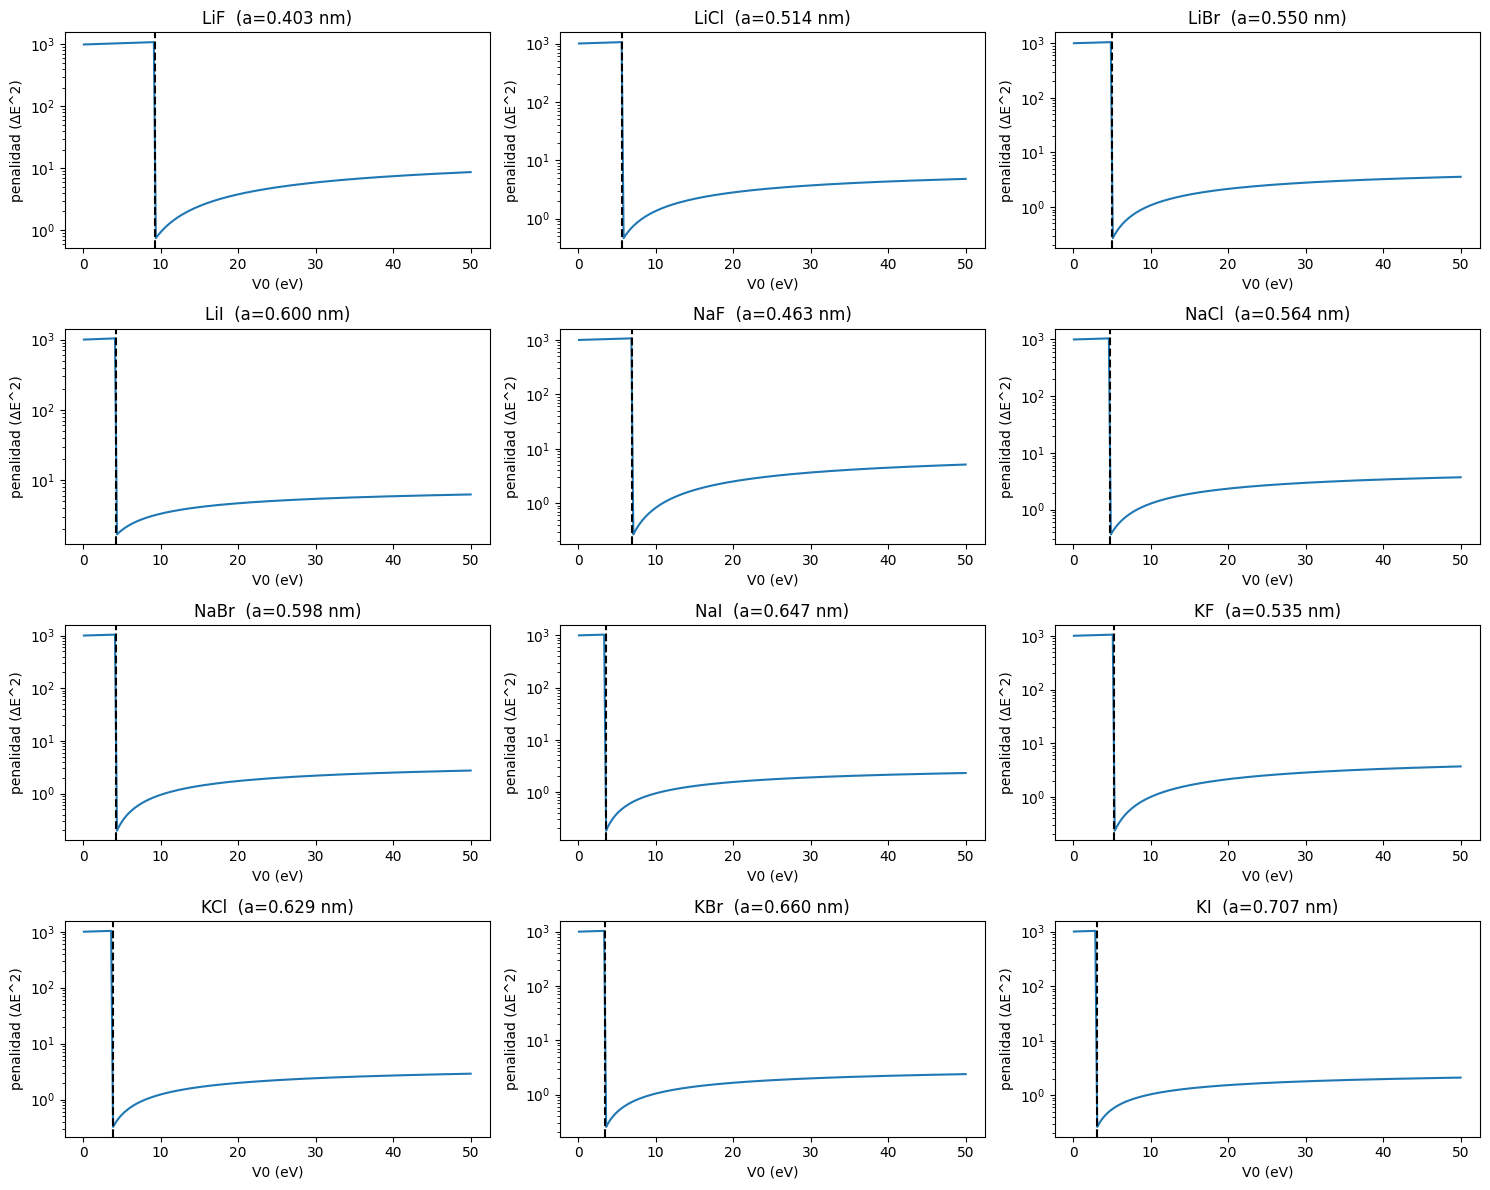

Guardado -> V0_results_by_compound.csv


In [ ]:
# Colab-ready: ajuste de V0 para pozo esférico finito por compuesto
# Requiere: numpy, scipy, matplotlib, pandas
# Ejecutar en Google Colab -> Runtime > Restart if needed

import numpy as np
import pandas as pd
from scipy.optimize import brentq, minimize_scalar
import matplotlib.pyplot as plt

# ---------- CONSTANTES ----------
hbar = 1.054571817e-34      # J s
m_e = 9.10938356e-31        # kg
eV2J = 1.602176634e-19      # J / eV

# ---------- DATOS (tu tabla) ----------
# a en nm, E en eV
data = [
    ("LiF", 0.4028, 5.083),
    ("LiCl", 0.5140, 3.256),
    ("LiBr", 0.5502, 2.767),
    ("LiI", 0.6000, 3.176),
    ("NaF", 0.4634, 3.702),
    ("NaCl", 0.5640, 2.746),
    ("NaBr", 0.5978, 2.345),
    ("NaI", 0.6474, 2.063),
    ("KF",   0.5348, 2.873),
    ("KCl",  0.6294, 2.295),
    ("KBr",  0.6596, 2.059),
    ("KI",   0.7066, 1.874),
    # las siguientes parecen duplicados o variantes; las dejo comentadas.
    # ("NaCl_dup", 0.5640, 2.693),
    # ("KCl_dup", 0.6290, 2.461),
    # ("KBr_dup", 0.6600, 2.004),
    # ("Kl", 0.7070, 1.814),
]

df = pd.DataFrame(data, columns=["compound","a_nm","E_exp_eV"])

# ---------- ELECCIÓN DEL RADIO R ----------
# Opciones: "a/2", "a/sqrt2", "0.335*a"  (escoge la que quieras)
R_choice = "a/2"

def a_nm_to_R_m(a_nm, choice="a/2"):
    a_m = a_nm * 1e-9
    if choice == "a/2":
        R = a_m / 2.0
    elif choice == "a/sqrt2":
        R = a_m / np.sqrt(2.0)
    elif choice == "0.335*a":
        R = 0.335 * a_m
    else:
        raise ValueError("choice unknown")
    return R

# ---------- ECUACIONES DE CONTORNO EN ε ----------
# delta = 2 m V0 R^2 / hbar^2
# l=0:   -ε cot(ε) = sqrt(delta - ε^2)
# l=1:   (ε cot ε - 1) sqrt(delta - ε^2) = ε^2 [1 + sqrt(delta - ε^2)]

def roots_for_V0(V0_eV, R_m, l_funcs=True, scan_eps_max=30.0):
    """Devuelve (eps0, eps1) -- si alguna raíz no existe devuelve None en su lugar.
       V0_eV: potencial en eV
       R_m: radio en metros
    """
    V0 = V0_eV * eV2J
    delta = (2.0 * m_e * V0 * R_m**2) / hbar**2
    if delta <= 0:
        return (None, None)
    eps_max = min(np.sqrt(delta) - 1e-8, scan_eps_max)
    if eps_max <= 1e-6:
        return (None, None)

    # definimos funciones (cuidar singularidades)
    def safe_cot(x):
        s = np.sin(x)
        # evitar division por 0; cuando sin ~0 devolvemos un value muy grande
        mask = np.abs(s) < 1e-8
        out = np.empty_like(x)
        out = np.cos(x) / (np.where(np.abs(s) < 1e-12, np.sign(s)*1e-12, s))
        return out

    def f0(eps):
        # -eps cot(eps) - sqrt(delta - eps^2) = 0
        return - eps * (np.cos(eps)/np.sin(eps)) - np.sqrt(delta - eps**2)

    def f1(eps):
        s = np.sqrt(delta - eps**2)
        return (eps * (np.cos(eps)/np.sin(eps)) - 1.0) * s - eps**2 * (1.0 + s)

    # barrido para detectar cambios de signo (primeras raíces positivas)
    eps_grid = np.linspace(1e-6, eps_max, 2000)
    f0_vals = f0(eps_grid)
    f1_vals = f1(eps_grid)

    def find_first_root(eps_grid, fvals):
        # encuentra primer intervalo con cambio de signo y aplica brentq
        sign = np.sign(fvals)
        sign[sign==0] = 1e-16
        idx = np.where(sign[:-1] * sign[1:] < 0)[0]
        for i in idx:
            a = eps_grid[i]
            b = eps_grid[i+1]
            try:
                root = brentq(lambda x: f0(x) if (fvals is f0_vals) else None, a, b)
            except Exception:
                try:
                    root = brentq(lambda x: np.interp(0, [fvals[i], fvals[i+1]], [a,b]), a, b)
                except Exception:
                    root = None
            # but above is fragile; we'll use a more robust path below by calling brentq on corresponding function
        return None

    # Use robust brentq calls separately (not via that messy function)
    eps0 = None
    eps1 = None
    # para f0:
    for i in range(len(eps_grid)-1):
        a = eps_grid[i]; b = eps_grid[i+1]
        fa = f0(a); fb = f0(b)
        if np.isnan(fa) or np.isnan(fb):
            continue
        if fa*fb <= 0:
            try:
                eps0 = brentq(f0, a, b, maxiter=200)
                break
            except Exception:
                continue
    # para f1:
    for i in range(len(eps_grid)-1):
        a = eps_grid[i]; b = eps_grid[i+1]
        fa = f1(a); fb = f1(b)
        if np.isnan(fa) or np.isnan(fb):
            continue
        if fa*fb <= 0:
            try:
                eps1 = brentq(f1, a, b, maxiter=200)
                break
            except Exception:
                continue

    return (eps0, eps1)

# ---------- ENERGÍA desde ε ----------
def energy_from_eps(eps, R_m):
    """Devuelve energía en eV"""
    if eps is None:
        return None
    E_J = (hbar**2 * eps**2) / (2.0 * m_e * R_m**2)
    return E_J / eV2J

# ---------- FUNCIÓN OBJETIVO por compuesto ----------
def deltaE_model_for_V0(V0_eV, a_nm, R_choice_local=R_choice):
    R_m = a_nm_to_R_m(a_nm, R_choice_local)
    eps0, eps1 = roots_for_V0(V0_eV, R_m)
    if eps0 is None or eps1 is None:
        return None  # sin soluciones físicas (penalizar afuera)
    E0 = energy_from_eps(eps0, R_m)
    E1 = energy_from_eps(eps1, R_m)
    return E1 - E0  # eV

def penalty_for_V0(V0_eV, a_nm, E_exp_eV, R_choice_local=R_choice):
    val = deltaE_model_for_V0(V0_eV, a_nm, R_choice_local)
    if val is None or not np.isfinite(val):
        return 1e3  + (V0_eV*10)  # penalización grande
    return (val - E_exp_eV)**2

# ---------- BÚSQUEDA/OPTIMIZACIÓN por compuesto ----------
results = []
V0_search_bounds = (0.1, 50.0)   # eV; ajustable (si necesitas mayor V0, ampliar a 100 o 200)
for _, row in df.iterrows():
    comp = row['compound']
    a_nm = row['a_nm']
    E_exp = row['E_exp_eV']

    # Minimización acotada (minimiza el penalty)
    res = minimize_scalar(lambda V: penalty_for_V0(V, a_nm, E_exp, R_choice),
                          bounds=V0_search_bounds, method='bounded',
                          options={'xatol':1e-3})
    V0_opt = res.x
    chi2 = res.fun
    # calcular deltaE_teo para el V0 óptimo
    deltaE_teo = deltaE_model_for_V0(V0_opt, a_nm, R_choice)
    results.append({
        "compound": comp,
        "a_nm": a_nm,
        "E_exp_eV": E_exp,
        "V0_opt_eV": float(V0_opt),
        "chi2": float(chi2),
        "DeltaE_teo_eV": float(deltaE_teo) if deltaE_teo is not None else None
    })
    print(f"{comp:6s} | a={a_nm:.4f} nm | E_exp={E_exp:.3f} eV -> V0_opt={V0_opt:.3f} eV | DeltaE_teo={deltaE_teo}")

results_df = pd.DataFrame(results)
print("\nResultados (tabla):")
display(results_df)

# ---------- GRAFICOS: chi2(V0) para cada compuesto (opcional, 4 por fila) ----------
# Graficar algunas curvas chi2 vs V0 para inspección (si quieres ver TODAS, quita el head())
to_plot = df['compound'].tolist()  # todos
nplots = len(to_plot)
cols = 3
rows = int(np.ceil(nplots/cols))
fig = plt.figure(figsize=(5*cols, 3*rows))
for i, comp in enumerate(to_plot):
    ax = fig.add_subplot(rows, cols, i+1)
    row = df[df['compound']==comp].iloc[0]
    a_nm = row['a_nm']; E_exp = row['E_exp_eV']
    Vgrid = np.linspace(V0_search_bounds[0], V0_search_bounds[1], 200)
    pen = [penalty_for_V0(V, a_nm, E_exp, R_choice) for V in Vgrid]
    ax.plot(Vgrid, pen)
    # marcar mínimo encontrado
    V_opt = results_df[results_df['compound']==comp]['V0_opt_eV'].values[0]
    ax.axvline(V_opt, color='k', linestyle='--')
    ax.set_title(f"{comp}  (a={a_nm:.3f} nm)")
    ax.set_xlabel("V0 (eV)"); ax.set_ylabel("penalidad (ΔE^2)")
    ax.set_yscale('log')
plt.tight_layout()
plt.show()

# ---------- Export: guardar resultados ----------
results_df.to_csv("V0_results_by_compound.csv", index=False)
print("Guardado -> V0_results_by_compound.csv")


a/raiz de 2

LiF    | a=0.4028 nm | E_exp=5.083 eV -> V0_opt=4.640 eV | DeltaE_teo=2.1202027677449657
LiCl   | a=0.5140 nm | E_exp=3.256 eV -> V0_opt=2.850 eV | DeltaE_teo=1.3020597327577064
LiBr   | a=0.5502 nm | E_exp=2.767 eV -> V0_opt=2.487 eV | DeltaE_teo=1.1363426988206167
LiI    | a=0.6000 nm | E_exp=3.176 eV -> V0_opt=2.091 eV | DeltaE_teo=0.9555624741136957
NaF    | a=0.4634 nm | E_exp=3.702 eV -> V0_opt=3.506 eV | DeltaE_teo=1.6019622652055694
NaCl   | a=0.5640 nm | E_exp=2.746 eV -> V0_opt=2.367 eV | DeltaE_teo=1.0814507940258133
NaBr   | a=0.5978 nm | E_exp=2.345 eV -> V0_opt=2.107 eV | DeltaE_teo=0.9625832036383177
NaI    | a=0.6474 nm | E_exp=2.063 eV -> V0_opt=1.796 eV | DeltaE_teo=0.8207080526013788
KF     | a=0.5348 nm | E_exp=2.873 eV -> V0_opt=2.632 eV | DeltaE_teo=1.2027671142809477
KCl    | a=0.6294 nm | E_exp=2.295 eV -> V0_opt=1.900 eV | DeltaE_teo=0.8683658985958171
KBr    | a=0.6596 nm | E_exp=2.059 eV -> V0_opt=1.731 eV | DeltaE_teo=0.7906203851266408
KI     | a=0.7066 nm 

,compound,a_nm,E_exp_eV,V0_opt_eV,chi2,DeltaE_teo_eV
0,LiF,0.4028,5.083,4.640141,8.778167,2.120203
1,LiCl,0.5140,3.256,2.849586,3.817883,1.302060
2,LiBr,0.5502,2.767,2.487049,2.659043,1.136343
3,LiI,0.6000,3.176,2.091191,4.930343,0.955562
4,NaF,0.4634,3.702,3.505718,4.410158,1.601962
5,NaCl,0.5640,2.746,2.366623,2.770724,1.081451
6,NaBr,0.5978,2.345,2.106758,1.911076,0.962583
7,NaI,0.6474,2.063,1.796484,1.543289,0.820708
8,KF,0.5348,2.873,2.632123,2.789678,1.202767
9,KCl,0.6294,2.295,1.900452,2.035285,0.868366


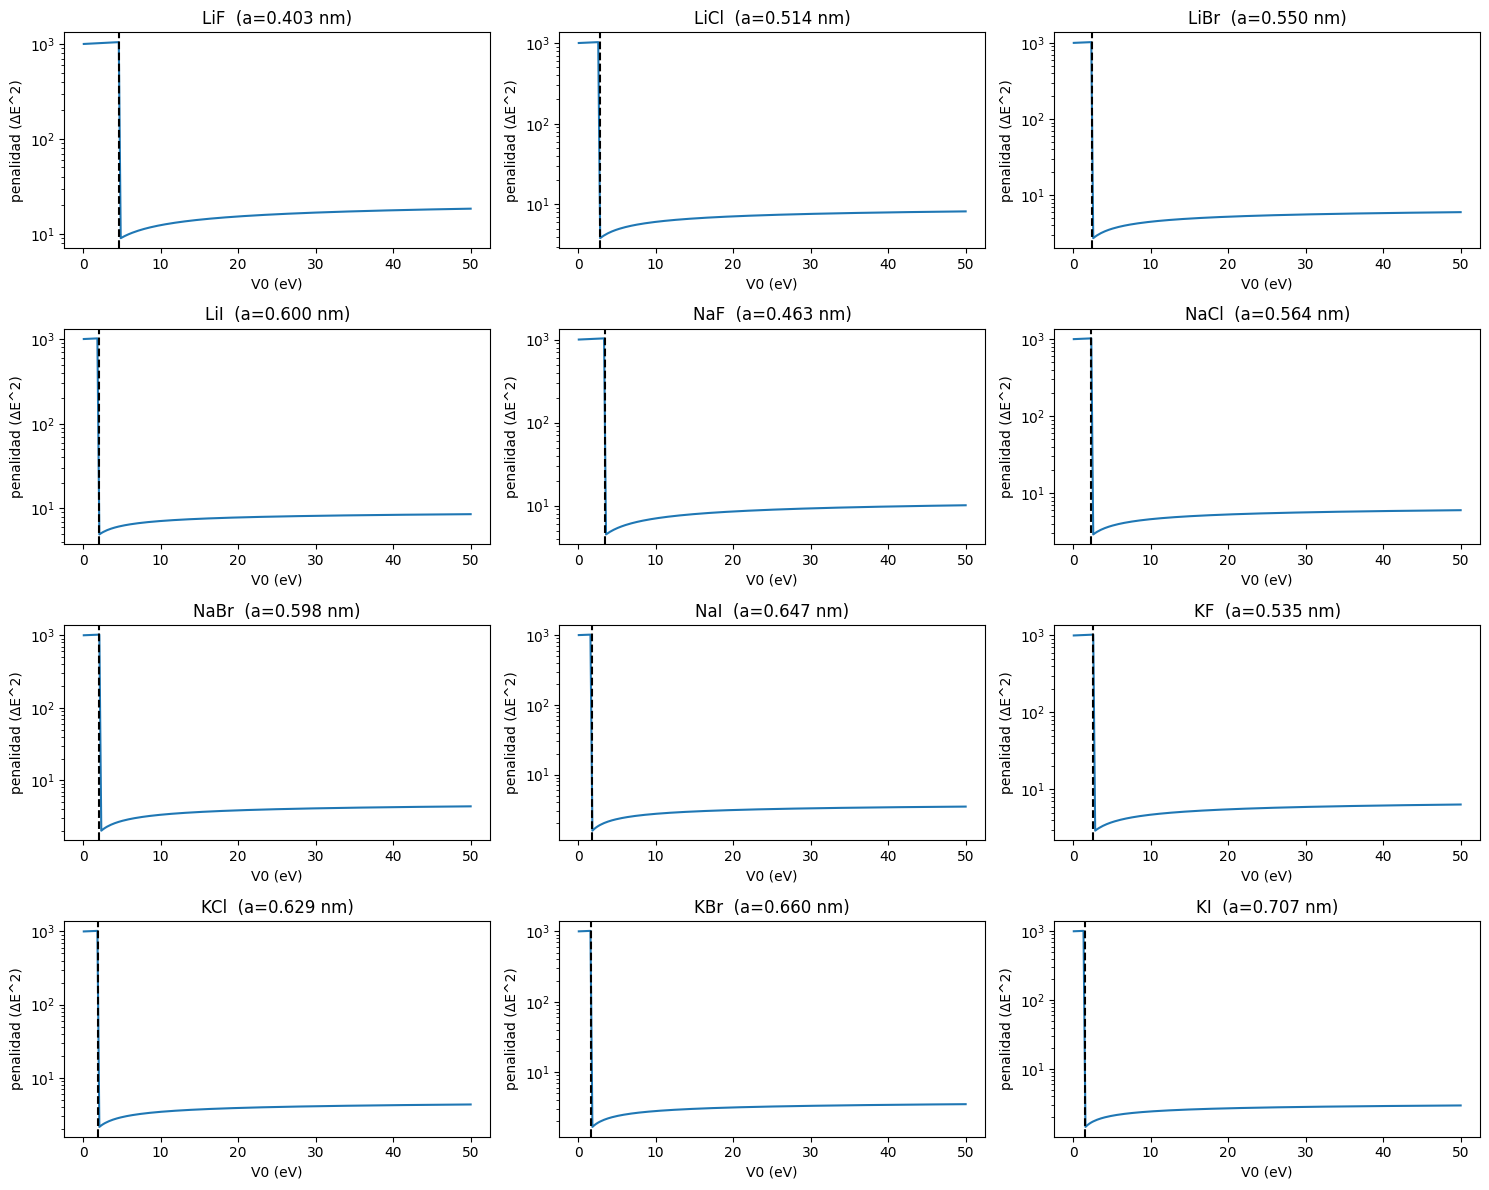

Guardado -> V0_results_by_compound.csv


In [ ]:
# Colab-ready: ajuste de V0 para pozo esférico finito por compuesto
# Requiere: numpy, scipy, matplotlib, pandas
# Ejecutar en Google Colab -> Runtime > Restart if needed

import numpy as np
import pandas as pd
from scipy.optimize import brentq, minimize_scalar
import matplotlib.pyplot as plt

# ---------- CONSTANTES ----------
hbar = 1.054571817e-34      # J s
m_e = 9.10938356e-31        # kg
eV2J = 1.602176634e-19      # J / eV

# ---------- DATOS (tu tabla) ----------
# a en nm, E en eV
data = [
    ("LiF", 0.4028, 5.083),
    ("LiCl", 0.5140, 3.256),
    ("LiBr", 0.5502, 2.767),
    ("LiI", 0.6000, 3.176),
    ("NaF", 0.4634, 3.702),
    ("NaCl", 0.5640, 2.746),
    ("NaBr", 0.5978, 2.345),
    ("NaI", 0.6474, 2.063),
    ("KF",   0.5348, 2.873),
    ("KCl",  0.6294, 2.295),
    ("KBr",  0.6596, 2.059),
    ("KI",   0.7066, 1.874),
    # las siguientes parecen duplicados o variantes; las dejo comentadas.
    # ("NaCl_dup", 0.5640, 2.693),
    # ("KCl_dup", 0.6290, 2.461),
    # ("KBr_dup", 0.6600, 2.004),
    # ("Kl", 0.7070, 1.814),
]

df = pd.DataFrame(data, columns=["compound","a_nm","E_exp_eV"])

# ---------- ELECCIÓN DEL RADIO R ----------
# Opciones: "a/2", "a/sqrt2", "0.335*a"  (escoge la que quieras)
R_choice = "a/sqrt2"

def a_nm_to_R_m(a_nm, choice="a/2"):
    a_m = a_nm * 1e-9
    if choice == "a/2":
        R = a_m / 2.0
    elif choice == "a/sqrt2":
        R = a_m / np.sqrt(2.0)
    elif choice == "0.335*a":
        R = 0.335 * a_m
    else:
        raise ValueError("choice unknown")
    return R

# ---------- ECUACIONES DE CONTORNO EN ε ----------
# delta = 2 m V0 R^2 / hbar^2
# l=0:   -ε cot(ε) = sqrt(delta - ε^2)
# l=1:   (ε cot ε - 1) sqrt(delta - ε^2) = ε^2 [1 + sqrt(delta - ε^2)]

def roots_for_V0(V0_eV, R_m, l_funcs=True, scan_eps_max=30.0):
    """Devuelve (eps0, eps1) -- si alguna raíz no existe devuelve None en su lugar.
       V0_eV: potencial en eV
       R_m: radio en metros
    """
    V0 = V0_eV * eV2J
    delta = (2.0 * m_e * V0 * R_m**2) / hbar**2
    if delta <= 0:
        return (None, None)
    eps_max = min(np.sqrt(delta) - 1e-8, scan_eps_max)
    if eps_max <= 1e-6:
        return (None, None)

    # definimos funciones (cuidar singularidades)
    def safe_cot(x):
        s = np.sin(x)
        # evitar division por 0; cuando sin ~0 devolvemos un value muy grande
        mask = np.abs(s) < 1e-8
        out = np.empty_like(x)
        out = np.cos(x) / (np.where(np.abs(s) < 1e-12, np.sign(s)*1e-12, s))
        return out

    def f0(eps):
        # -eps cot(eps) - sqrt(delta - eps^2) = 0
        return - eps * (np.cos(eps)/np.sin(eps)) - np.sqrt(delta - eps**2)

    def f1(eps):
        s = np.sqrt(delta - eps**2)
        return (eps * (np.cos(eps)/np.sin(eps)) - 1.0) * s - eps**2 * (1.0 + s)

    # barrido para detectar cambios de signo (primeras raíces positivas)
    eps_grid = np.linspace(1e-6, eps_max, 2000)
    f0_vals = f0(eps_grid)
    f1_vals = f1(eps_grid)

    def find_first_root(eps_grid, fvals):
        # encuentra primer intervalo con cambio de signo y aplica brentq
        sign = np.sign(fvals)
        sign[sign==0] = 1e-16
        idx = np.where(sign[:-1] * sign[1:] < 0)[0]
        for i in idx:
            a = eps_grid[i]
            b = eps_grid[i+1]
            try:
                root = brentq(lambda x: f0(x) if (fvals is f0_vals) else None, a, b)
            except Exception:
                try:
                    root = brentq(lambda x: np.interp(0, [fvals[i], fvals[i+1]], [a,b]), a, b)
                except Exception:
                    root = None
            # but above is fragile; we'll use a more robust path below by calling brentq on corresponding function
        return None

    # Use robust brentq calls separately (not via that messy function)
    eps0 = None
    eps1 = None
    # para f0:
    for i in range(len(eps_grid)-1):
        a = eps_grid[i]; b = eps_grid[i+1]
        fa = f0(a); fb = f0(b)
        if np.isnan(fa) or np.isnan(fb):
            continue
        if fa*fb <= 0:
            try:
                eps0 = brentq(f0, a, b, maxiter=200)
                break
            except Exception:
                continue
    # para f1:
    for i in range(len(eps_grid)-1):
        a = eps_grid[i]; b = eps_grid[i+1]
        fa = f1(a); fb = f1(b)
        if np.isnan(fa) or np.isnan(fb):
            continue
        if fa*fb <= 0:
            try:
                eps1 = brentq(f1, a, b, maxiter=200)
                break
            except Exception:
                continue

    return (eps0, eps1)

# ---------- ENERGÍA desde ε ----------
def energy_from_eps(eps, R_m):
    """Devuelve energía en eV"""
    if eps is None:
        return None
    E_J = (hbar**2 * eps**2) / (2.0 * m_e * R_m**2)
    return E_J / eV2J

# ---------- FUNCIÓN OBJETIVO por compuesto ----------
def deltaE_model_for_V0(V0_eV, a_nm, R_choice_local=R_choice):
    R_m = a_nm_to_R_m(a_nm, R_choice_local)
    eps0, eps1 = roots_for_V0(V0_eV, R_m)
    if eps0 is None or eps1 is None:
        return None  # sin soluciones físicas (penalizar afuera)
    E0 = energy_from_eps(eps0, R_m)
    E1 = energy_from_eps(eps1, R_m)
    return E1 - E0  # eV

def penalty_for_V0(V0_eV, a_nm, E_exp_eV, R_choice_local=R_choice):
    val = deltaE_model_for_V0(V0_eV, a_nm, R_choice_local)
    if val is None or not np.isfinite(val):
        return 1e3  + (V0_eV*10)  # penalización grande
    return (val - E_exp_eV)**2

# ---------- BÚSQUEDA/OPTIMIZACIÓN por compuesto ----------
results = []
V0_search_bounds = (0.1, 50.0)   # eV; ajustable (si necesitas mayor V0, ampliar a 100 o 200)
for _, row in df.iterrows():
    comp = row['compound']
    a_nm = row['a_nm']
    E_exp = row['E_exp_eV']

    # Minimización acotada (minimiza el penalty)
    res = minimize_scalar(lambda V: penalty_for_V0(V, a_nm, E_exp, R_choice),
                          bounds=V0_search_bounds, method='bounded',
                          options={'xatol':1e-3})
    V0_opt = res.x
    chi2 = res.fun
    # calcular deltaE_teo para el V0 óptimo
    deltaE_teo = deltaE_model_for_V0(V0_opt, a_nm, R_choice)
    results.append({
        "compound": comp,
        "a_nm": a_nm,
        "E_exp_eV": E_exp,
        "V0_opt_eV": float(V0_opt),
        "chi2": float(chi2),
        "DeltaE_teo_eV": float(deltaE_teo) if deltaE_teo is not None else None
    })
    print(f"{comp:6s} | a={a_nm:.4f} nm | E_exp={E_exp:.3f} eV -> V0_opt={V0_opt:.3f} eV | DeltaE_teo={deltaE_teo}")

results_df = pd.DataFrame(results)
print("\nResultados (tabla):")
display(results_df)

# ---------- GRAFICOS: chi2(V0) para cada compuesto (opcional, 4 por fila) ----------
# Graficar algunas curvas chi2 vs V0 para inspección (si quieres ver TODAS, quita el head())
to_plot = df['compound'].tolist()  # todos
nplots = len(to_plot)
cols = 3
rows = int(np.ceil(nplots/cols))
fig = plt.figure(figsize=(5*cols, 3*rows))
for i, comp in enumerate(to_plot):
    ax = fig.add_subplot(rows, cols, i+1)
    row = df[df['compound']==comp].iloc[0]
    a_nm = row['a_nm']; E_exp = row['E_exp_eV']
    Vgrid = np.linspace(V0_search_bounds[0], V0_search_bounds[1], 200)
    pen = [penalty_for_V0(V, a_nm, E_exp, R_choice) for V in Vgrid]
    ax.plot(Vgrid, pen)
    # marcar mínimo encontrado
    V_opt = results_df[results_df['compound']==comp]['V0_opt_eV'].values[0]
    ax.axvline(V_opt, color='k', linestyle='--')
    ax.set_title(f"{comp}  (a={a_nm:.3f} nm)")
    ax.set_xlabel("V0 (eV)"); ax.set_ylabel("penalidad (ΔE^2)")
    ax.set_yscale('log')
plt.tight_layout()
plt.show()

# ---------- Export: guardar resultados ----------
results_df.to_csv("V0_results_by_compound.csv", index=False)
print("Guardado -> V0_results_by_compound.csv")


LiF    | a=0.4028 nm | E_exp=5.083 eV -> V0_opt=4.640 eV | DeltaE_teo=2.1202027677449657
LiCl   | a=0.5140 nm | E_exp=3.256 eV -> V0_opt=2.850 eV | DeltaE_teo=1.3020597327577064
LiBr   | a=0.5502 nm | E_exp=2.767 eV -> V0_opt=2.487 eV | DeltaE_teo=1.1363426988206167
LiI    | a=0.6000 nm | E_exp=3.176 eV -> V0_opt=2.091 eV | DeltaE_teo=0.9555624741136957
NaF    | a=0.4634 nm | E_exp=3.702 eV -> V0_opt=3.506 eV | DeltaE_teo=1.6019622652055694
NaCl   | a=0.5640 nm | E_exp=2.746 eV -> V0_opt=2.367 eV | DeltaE_teo=1.0814507940258133
NaBr   | a=0.5978 nm | E_exp=2.345 eV -> V0_opt=2.107 eV | DeltaE_teo=0.9625832036383177
NaI    | a=0.6474 nm | E_exp=2.063 eV -> V0_opt=1.796 eV | DeltaE_teo=0.8207080526013788
KF     | a=0.5348 nm | E_exp=2.873 eV -> V0_opt=2.632 eV | DeltaE_teo=1.2027671142809477
KCl    | a=0.6294 nm | E_exp=2.295 eV -> V0_opt=1.900 eV | DeltaE_teo=0.8683658985958171
KBr    | a=0.6596 nm | E_exp=2.059 eV -> V0_opt=1.731 eV | DeltaE_teo=0.7906203851266408
KI     | a=0.7066 nm 

,compound,a_nm,E_exp_eV,V0_opt_eV,chi2,DeltaE_teo_eV
0,LiF,0.4028,5.083,4.640141,8.778167,2.120203
1,LiCl,0.5140,3.256,2.849586,3.817883,1.302060
2,LiBr,0.5502,2.767,2.487049,2.659043,1.136343
3,LiI,0.6000,3.176,2.091191,4.930343,0.955562
4,NaF,0.4634,3.702,3.505718,4.410158,1.601962
5,NaCl,0.5640,2.746,2.366623,2.770724,1.081451
6,NaBr,0.5978,2.345,2.106758,1.911076,0.962583
7,NaI,0.6474,2.063,1.796484,1.543289,0.820708
8,KF,0.5348,2.873,2.632123,2.789678,1.202767
9,KCl,0.6294,2.295,1.900452,2.035285,0.868366


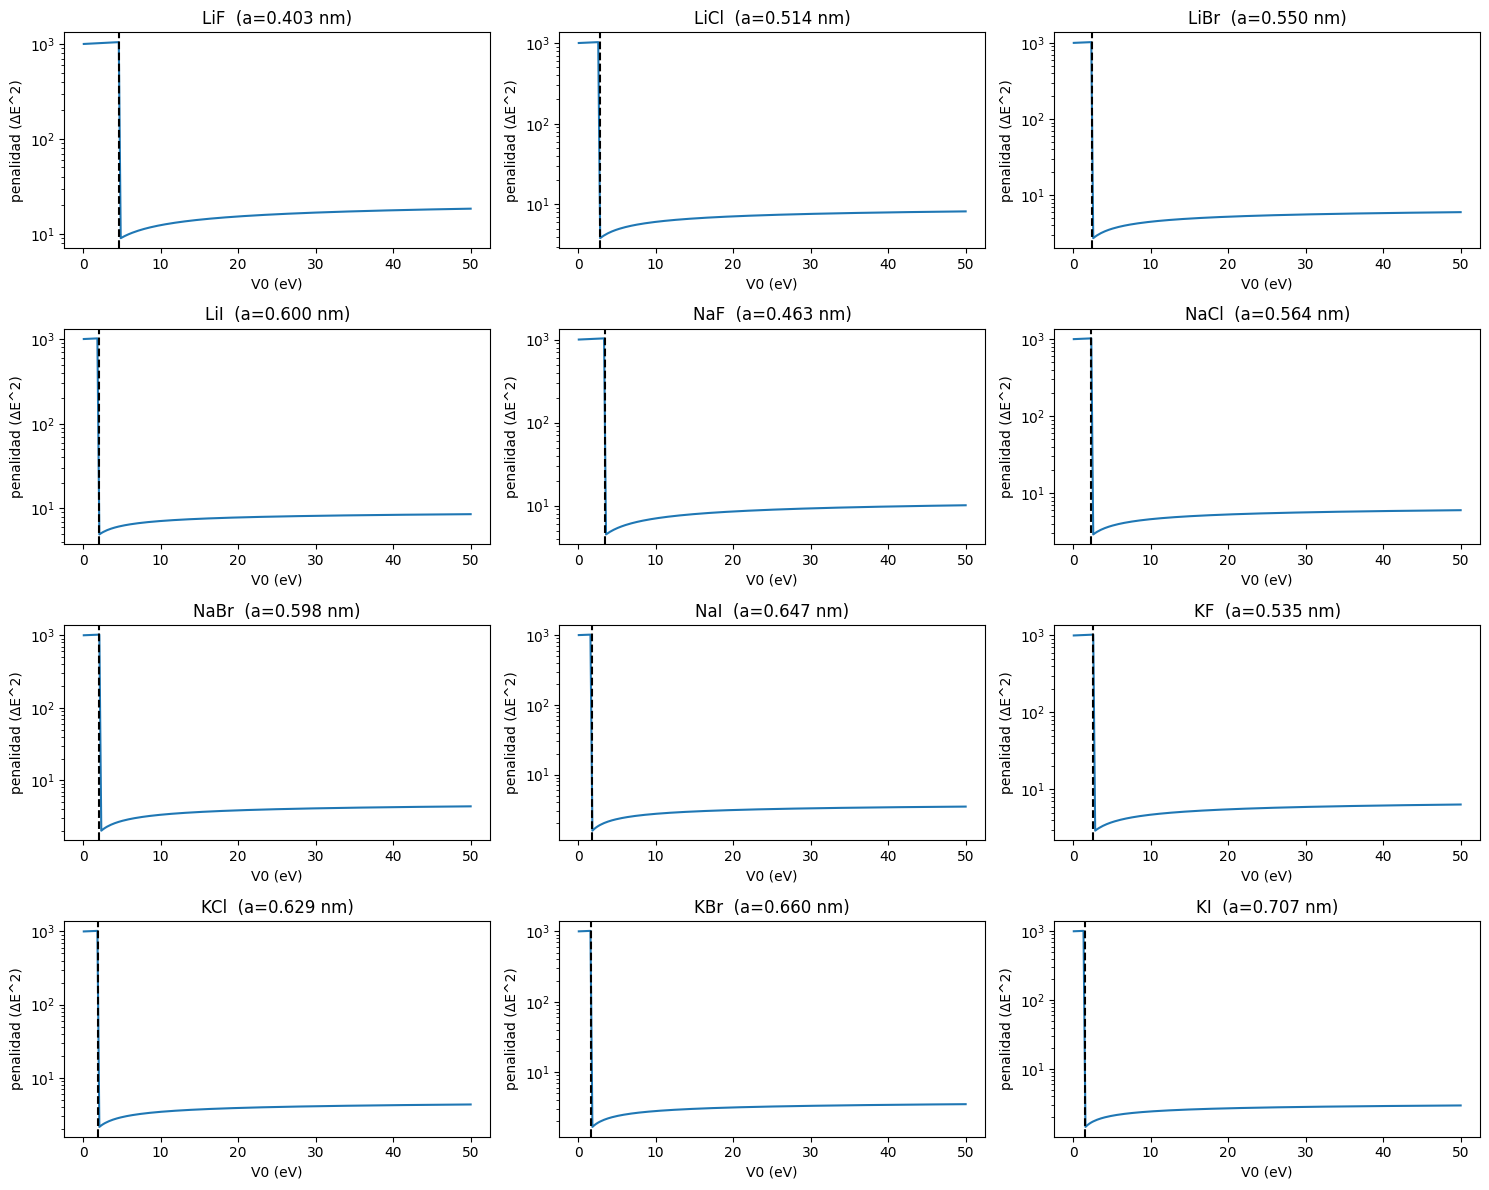

Guardado -> V0_results_by_compound.csv


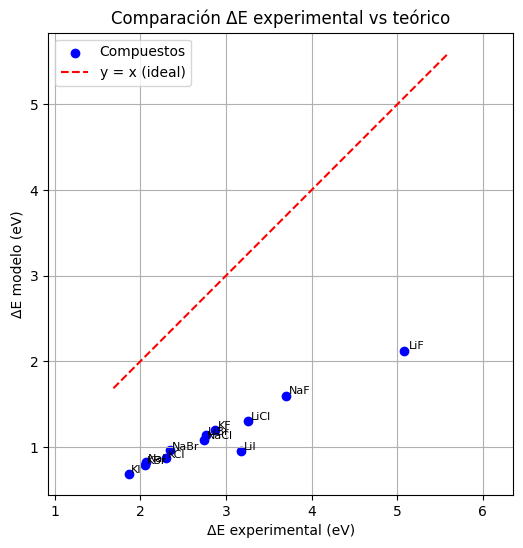

In [ ]:
# Colab-ready: ajuste de V0 para pozo esférico finito por compuesto
# Requiere: numpy, scipy, matplotlib, pandas
# Ejecutar en Google Colab -> Runtime > Restart if needed

import numpy as np
import pandas as pd
from scipy.optimize import brentq, minimize_scalar
import matplotlib.pyplot as plt

# ---------- CONSTANTES ----------
hbar = 1.054571817e-34      # J s
m_e = 9.10938356e-31        # kg
eV2J = 1.602176634e-19      # J / eV

# ---------- DATOS (tu tabla) ----------
# a en nm, E en eV
data = [
    ("LiF", 0.4028, 5.083),
    ("LiCl", 0.5140, 3.256),
    ("LiBr", 0.5502, 2.767),
    ("LiI", 0.6000, 3.176),
    ("NaF", 0.4634, 3.702),
    ("NaCl", 0.5640, 2.746),
    ("NaBr", 0.5978, 2.345),
    ("NaI", 0.6474, 2.063),
    ("KF",   0.5348, 2.873),
    ("KCl",  0.6294, 2.295),
    ("KBr",  0.6596, 2.059),
    ("KI",   0.7066, 1.874),
    # las siguientes parecen duplicados o variantes; las dejo comentadas.
    # ("NaCl_dup", 0.5640, 2.693),
    # ("KCl_dup", 0.6290, 2.461),
    # ("KBr_dup", 0.6600, 2.004),
    # ("Kl", 0.7070, 1.814),
]

df = pd.DataFrame(data, columns=["compound","a_nm","E_exp_eV"])

# ---------- ELECCIÓN DEL RADIO R ----------
# Opciones: "a/2", "a/sqrt2", "0.335*a"  (escoge la que quieras)
R_choice = "a/sqrt2"

def a_nm_to_R_m(a_nm, choice="a/2"):
    a_m = a_nm * 1e-9
    if choice == "a/2":
        R = a_m / 2.0
    elif choice == "a/sqrt2":
        R = a_m / np.sqrt(2.0)
    elif choice == "0.335*a":
        R = 0.335 * a_m
    else:
        raise ValueError("choice unknown")
    return R

# ---------- ECUACIONES DE CONTORNO EN ε ----------
# delta = 2 m V0 R^2 / hbar^2
# l=0:   -ε cot(ε) = sqrt(delta - ε^2)
# l=1:   (ε cot ε - 1) sqrt(delta - ε^2) = ε^2 [1 + sqrt(delta - ε^2)]

def roots_for_V0(V0_eV, R_m, l_funcs=True, scan_eps_max=30.0):
    """Devuelve (eps0, eps1) -- si alguna raíz no existe devuelve None en su lugar.
       V0_eV: potencial en eV
       R_m: radio en metros
    """
    V0 = V0_eV * eV2J
    delta = (2.0 * m_e * V0 * R_m**2) / hbar**2
    if delta <= 0:
        return (None, None)
    eps_max = min(np.sqrt(delta) - 1e-8, scan_eps_max)
    if eps_max <= 1e-6:
        return (None, None)

    # definimos funciones (cuidar singularidades)
    def safe_cot(x):
        s = np.sin(x)
        # evitar division por 0; cuando sin ~0 devolvemos un value muy grande
        mask = np.abs(s) < 1e-8
        out = np.empty_like(x)
        out = np.cos(x) / (np.where(np.abs(s) < 1e-12, np.sign(s)*1e-12, s))
        return out

    def f0(eps):
        # -eps cot(eps) - sqrt(delta - eps^2) = 0
        return - eps * (np.cos(eps)/np.sin(eps)) - np.sqrt(delta - eps**2)

    def f1(eps):
        s = np.sqrt(delta - eps**2)
        return (eps * (np.cos(eps)/np.sin(eps)) - 1.0) * s - eps**2 * (1.0 + s)

    # barrido para detectar cambios de signo (primeras raíces positivas)
    eps_grid = np.linspace(1e-6, eps_max, 2000)
    f0_vals = f0(eps_grid)
    f1_vals = f1(eps_grid)

    def find_first_root(eps_grid, fvals):
        # encuentra primer intervalo con cambio de signo y aplica brentq
        sign = np.sign(fvals)
        sign[sign==0] = 1e-16
        idx = np.where(sign[:-1] * sign[1:] < 0)[0]
        for i in idx:
            a = eps_grid[i]
            b = eps_grid[i+1]
            try:
                root = brentq(lambda x: f0(x) if (fvals is f0_vals) else None, a, b)
            except Exception:
                try:
                    root = brentq(lambda x: np.interp(0, [fvals[i], fvals[i+1]], [a,b]), a, b)
                except Exception:
                    root = None
            # but above is fragile; we'll use a more robust path below by calling brentq on corresponding function
        return None

    # Use robust brentq calls separately (not via that messy function)
    eps0 = None
    eps1 = None
    # para f0:
    for i in range(len(eps_grid)-1):
        a = eps_grid[i]; b = eps_grid[i+1]
        fa = f0(a); fb = f0(b)
        if np.isnan(fa) or np.isnan(fb):
            continue
        if fa*fb <= 0:
            try:
                eps0 = brentq(f0, a, b, maxiter=200)
                break
            except Exception:
                continue
    # para f1:
    for i in range(len(eps_grid)-1):
        a = eps_grid[i]; b = eps_grid[i+1]
        fa = f1(a); fb = f1(b)
        if np.isnan(fa) or np.isnan(fb):
            continue
        if fa*fb <= 0:
            try:
                eps1 = brentq(f1, a, b, maxiter=200)
                break
            except Exception:
                continue

    return (eps0, eps1)

# ---------- ENERGÍA desde ε ----------
def energy_from_eps(eps, R_m):
    """Devuelve energía en eV"""
    if eps is None:
        return None
    E_J = (hbar**2 * eps**2) / (2.0 * m_e * R_m**2)
    return E_J / eV2J

# ---------- FUNCIÓN OBJETIVO por compuesto ----------
def deltaE_model_for_V0(V0_eV, a_nm, R_choice_local=R_choice):
    R_m = a_nm_to_R_m(a_nm, R_choice_local)
    eps0, eps1 = roots_for_V0(V0_eV, R_m)
    if eps0 is None or eps1 is None:
        return None  # sin soluciones físicas (penalizar afuera)
    E0 = energy_from_eps(eps0, R_m)
    E1 = energy_from_eps(eps1, R_m)
    return E1 - E0  # eV

def penalty_for_V0(V0_eV, a_nm, E_exp_eV, R_choice_local=R_choice):
    val = deltaE_model_for_V0(V0_eV, a_nm, R_choice_local)
    if val is None or not np.isfinite(val):
        return 1e3  + (V0_eV*10)  # penalización grande
    return (val - E_exp_eV)**2

# ---------- BÚSQUEDA/OPTIMIZACIÓN por compuesto ----------
results = []
V0_search_bounds = (0.1, 50.0)   # eV; ajustable (si necesitas mayor V0, ampliar a 100 o 200)
for _, row in df.iterrows():
    comp = row['compound']
    a_nm = row['a_nm']
    E_exp = row['E_exp_eV']

    # Minimización acotada (minimiza el penalty)
    res = minimize_scalar(lambda V: penalty_for_V0(V, a_nm, E_exp, R_choice),
                          bounds=V0_search_bounds, method='bounded',
                          options={'xatol':1e-3})
    V0_opt = res.x
    chi2 = res.fun
    # calcular deltaE_teo para el V0 óptimo
    deltaE_teo = deltaE_model_for_V0(V0_opt, a_nm, R_choice)
    results.append({
        "compound": comp,
        "a_nm": a_nm,
        "E_exp_eV": E_exp,
        "V0_opt_eV": float(V0_opt),
        "chi2": float(chi2),
        "DeltaE_teo_eV": float(deltaE_teo) if deltaE_teo is not None else None
    })
    print(f"{comp:6s} | a={a_nm:.4f} nm | E_exp={E_exp:.3f} eV -> V0_opt={V0_opt:.3f} eV | DeltaE_teo={deltaE_teo}")

results_df = pd.DataFrame(results)
print("\nResultados (tabla):")
display(results_df)

# ---------- GRAFICOS: chi2(V0) para cada compuesto (opcional, 4 por fila) ----------
# Graficar algunas curvas chi2 vs V0 para inspección (si quieres ver TODAS, quita el head())
to_plot = df['compound'].tolist()  # todos
nplots = len(to_plot)
cols = 3
rows = int(np.ceil(nplots/cols))
fig = plt.figure(figsize=(5*cols, 3*rows))
for i, comp in enumerate(to_plot):
    ax = fig.add_subplot(rows, cols, i+1)
    row = df[df['compound']==comp].iloc[0]
    a_nm = row['a_nm']; E_exp = row['E_exp_eV']
    Vgrid = np.linspace(V0_search_bounds[0], V0_search_bounds[1], 200)
    pen = [penalty_for_V0(V, a_nm, E_exp, R_choice) for V in Vgrid]
    ax.plot(Vgrid, pen)
    # marcar mínimo encontrado
    V_opt = results_df[results_df['compound']==comp]['V0_opt_eV'].values[0]
    ax.axvline(V_opt, color='k', linestyle='--')
    ax.set_title(f"{comp}  (a={a_nm:.3f} nm)")
    ax.set_xlabel("V0 (eV)"); ax.set_ylabel("penalidad (ΔE^2)")
    ax.set_yscale('log')
plt.tight_layout()
plt.show()

# ---------- Export: guardar resultados ----------
results_df.to_csv("V0_results_by_compound.csv", index=False)
print("Guardado -> V0_results_by_compound.csv")

# ---------- COMPARACIÓN ΔE EXPERIMENTAL VS TEÓRICO ----------
plt.figure(figsize=(6,6))
plt.scatter(results_df["E_exp_eV"], results_df["DeltaE_teo_eV"], c='blue', label="Compuestos")
plt.plot([results_df["E_exp_eV"].min()*0.9, results_df["E_exp_eV"].max()*1.1],
         [results_df["E_exp_eV"].min()*0.9, results_df["E_exp_eV"].max()*1.1],
         'r--', label="y = x (ideal)")
for _, row in results_df.iterrows():
    plt.text(row["E_exp_eV"]*1.01, row["DeltaE_teo_eV"]*1.01, row["compound"], fontsize=8)

plt.xlabel("ΔE experimental (eV)")
plt.ylabel("ΔE modelo (eV)")
plt.title("Comparación ΔE experimental vs teórico")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.show()



meff

LiF    | a=0.4028 nm | E_exp=5.083 eV -> V0_opt=199.999 eV | DeltaE_teo=11.788
LiCl   | a=0.5140 nm | E_exp=3.256 eV -> V0_opt=199.999 eV | DeltaE_teo=5.873
LiBr   | a=0.5502 nm | E_exp=2.767 eV -> V0_opt=200.000 eV | DeltaE_teo=4.830
LiI    | a=0.6000 nm | E_exp=3.176 eV -> V0_opt=199.999 eV | DeltaE_teo=3.763
NaF    | a=0.4634 nm | E_exp=3.702 eV -> V0_opt=199.999 eV | DeltaE_teo=7.903
NaCl   | a=0.5640 nm | E_exp=2.746 eV -> V0_opt=200.000 eV | DeltaE_teo=4.497
NaBr   | a=0.5978 nm | E_exp=2.345 eV -> V0_opt=200.000 eV | DeltaE_teo=3.803
NaI    | a=0.6474 nm | E_exp=2.063 eV -> V0_opt=200.000 eV | DeltaE_teo=3.021
KF     | a=0.5348 nm | E_exp=2.873 eV -> V0_opt=199.999 eV | DeltaE_teo=5.241
KCl    | a=0.6294 nm | E_exp=2.295 eV -> V0_opt=200.000 eV | DeltaE_teo=3.278
KBr    | a=0.6596 nm | E_exp=2.059 eV -> V0_opt=200.000 eV | DeltaE_teo=2.862
KI     | a=0.7066 nm | E_exp=1.874 eV -> V0_opt=199.999 eV | DeltaE_teo=2.345

Resultados (tabla):


,compound,a_nm,E_exp_eV,V0_opt_eV,chi2,DeltaE_teo_eV
0,LiF,0.4028,5.083,199.999441,44.959683,11.788198
1,LiCl,0.5140,3.256,199.999339,6.848306,5.872927
2,LiBr,0.5502,2.767,199.999657,4.255064,4.829781
3,LiI,0.6000,3.176,199.999428,0.344605,3.763030
4,NaF,0.4634,3.702,199.999403,17.650152,7.903208
5,NaCl,0.5640,2.746,199.999628,3.067673,4.497477
6,NaBr,0.5978,2.345,199.999618,2.126077,3.803107
7,NaI,0.6474,2.063,199.999561,0.918256,3.021257
8,KF,0.5348,2.873,199.999339,5.605228,5.240536
9,KCl,0.6294,2.295,199.999549,0.965759,3.277730


KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x7c512b028d60> (for post_execute):


KeyboardInterrupt: 

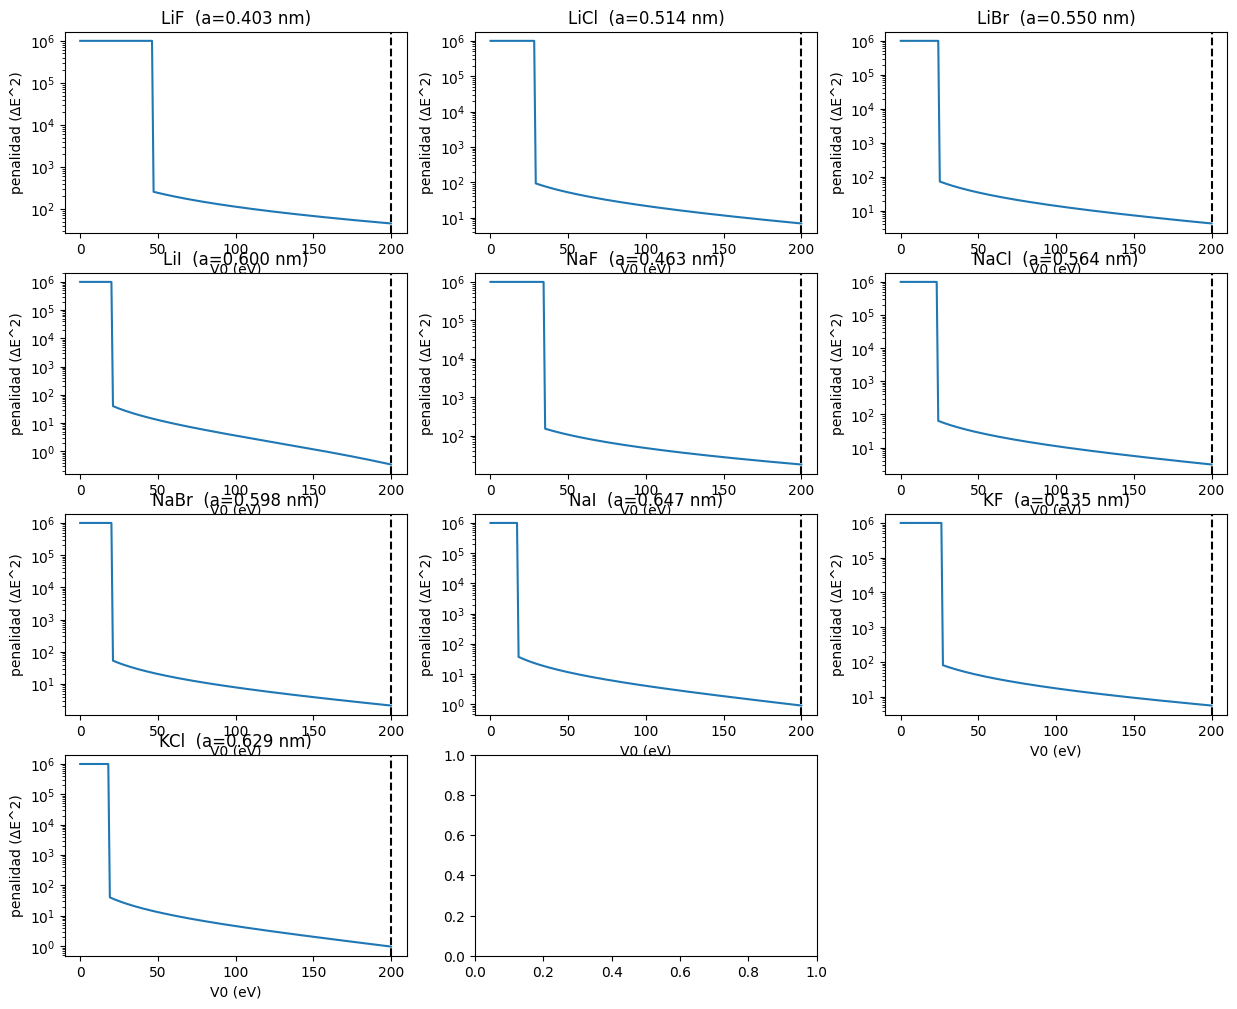

In [ ]:
# Colab-ready: ajuste de V0 para pozo esférico finito por compuesto
# Requiere: numpy, scipy, matplotlib, pandas
# Ejecutar en Google Colab -> Runtime > Restart if needed

import numpy as np
import pandas as pd
from scipy.optimize import brentq, minimize_scalar
import matplotlib.pyplot as plt

# ---------- CONSTANTES ----------
hbar = 1.054571817e-34      # J s
m_e = 9.10938356e-31        # kg
eV2J = 1.602176634e-19      # J / eV

# ---------- MASA EFECTIVA ----------
# Factor de masa efectiva respecto a m_e
m_eff_factor = 0.2   # ejemplo: 0.2 m_e
m_eff = m_eff_factor * m_e

# ---------- DATOS (tu tabla) ----------
# a en nm, E en eV
data = [
    ("LiF", 0.4028, 5.083),
    ("LiCl", 0.5140, 3.256),
    ("LiBr", 0.5502, 2.767),
    ("LiI", 0.6000, 3.176),
    ("NaF", 0.4634, 3.702),
    ("NaCl", 0.5640, 2.746),
    ("NaBr", 0.5978, 2.345),
    ("NaI", 0.6474, 2.063),
    ("KF",   0.5348, 2.873),
    ("KCl",  0.6294, 2.295),
    ("KBr",  0.6596, 2.059),
    ("KI",   0.7066, 1.874),
]

df = pd.DataFrame(data, columns=["compound","a_nm","E_exp_eV"])

# ---------- ELECCIÓN DEL RADIO R ----------
# Opciones: "a/2", "a/sqrt2", "0.335*a"  (escoge la que quieras)
R_choice = "a/2"

def a_nm_to_R_m(a_nm, choice="a/2"):
    a_m = a_nm * 1e-9
    if choice == "a/2":
        R = a_m / 2.0
    elif choice == "a/sqrt2":
        R = a_m / np.sqrt(2.0)
    elif choice == "0.335*a":
        R = 0.335 * a_m
    else:
        raise ValueError("choice unknown")
    return R

# ---------- ECUACIONES DE CONTORNO EN ε ----------
def roots_for_V0(V0_eV, R_m, scan_eps_max=30.0):
    """Devuelve (eps0, eps1) -- si alguna raíz no existe devuelve None en su lugar.
       V0_eV: potencial en eV
       R_m: radio en metros
    """
    V0 = V0_eV * eV2J
    delta = (2.0 * m_eff * V0 * R_m**2) / hbar**2
    if delta <= 0:
        return (None, None)
    eps_max = min(np.sqrt(delta) - 1e-8, scan_eps_max)
    if eps_max <= 1e-6:
        return (None, None)

    def f0(eps):
        return - eps * (np.cos(eps)/np.sin(eps)) - np.sqrt(delta - eps**2)

    def f1(eps):
        s = np.sqrt(delta - eps**2)
        return (eps * (np.cos(eps)/np.sin(eps)) - 1.0) * s - eps**2 * (1.0 + s)

    eps_grid = np.linspace(1e-6, eps_max, 2000)
    eps0, eps1 = None, None

    # para f0:
    for i in range(len(eps_grid)-1):
        a = eps_grid[i]; b = eps_grid[i+1]
        fa = f0(a); fb = f0(b)
        if np.isnan(fa) or np.isnan(fb):
            continue
        if fa*fb <= 0:
            try:
                eps0 = brentq(f0, a, b, maxiter=200)
                break
            except Exception:
                continue
    # para f1:
    for i in range(len(eps_grid)-1):
        a = eps_grid[i]; b = eps_grid[i+1]
        fa = f1(a); fb = f1(b)
        if np.isnan(fa) or np.isnan(fb):
            continue
        if fa*fb <= 0:
            try:
                eps1 = brentq(f1, a, b, maxiter=200)
                break
            except Exception:
                continue

    return (eps0, eps1)

# ---------- ENERGÍA desde ε ----------
def energy_from_eps(eps, R_m):
    """Devuelve energía en eV"""
    if eps is None:
        return None
    E_J = (hbar**2 * eps**2) / (2.0 * m_eff * R_m**2)
    return E_J / eV2J

# ---------- FUNCIÓN OBJETIVO por compuesto ----------
def deltaE_model_for_V0(V0_eV, a_nm, R_choice_local=R_choice):
    R_m = a_nm_to_R_m(a_nm, R_choice_local)
    eps0, eps1 = roots_for_V0(V0_eV, R_m)
    if eps0 is None or eps1 is None:
        return None
    E0 = energy_from_eps(eps0, R_m)
    E1 = energy_from_eps(eps1, R_m)
    return E1 - E0

def penalty_for_V0(V0_eV, a_nm, E_exp_eV, R_choice_local=R_choice):
    val = deltaE_model_for_V0(V0_eV, a_nm, R_choice_local)
    if val is None or not np.isfinite(val):
        return 1e6
    return (val - E_exp_eV)**2

# ---------- BÚSQUEDA/OPTIMIZACIÓN ----------
results = []
V0_search_bounds = (0.1, 200.0)   # ampliar rango si hace falta
for _, row in df.iterrows():
    comp = row['compound']
    a_nm = row['a_nm']
    E_exp = row['E_exp_eV']

    res = minimize_scalar(lambda V: penalty_for_V0(V, a_nm, E_exp, R_choice),
                          bounds=V0_search_bounds, method='bounded',
                          options={'xatol':1e-3})
    V0_opt = res.x
    chi2 = res.fun
    deltaE_teo = deltaE_model_for_V0(V0_opt, a_nm, R_choice)
    results.append({
        "compound": comp,
        "a_nm": a_nm,
        "E_exp_eV": E_exp,
        "V0_opt_eV": float(V0_opt),
        "chi2": float(chi2),
        "DeltaE_teo_eV": float(deltaE_teo) if deltaE_teo is not None else None
    })
    print(f"{comp:6s} | a={a_nm:.4f} nm | E_exp={E_exp:.3f} eV -> "
          f"V0_opt={V0_opt:.3f} eV | DeltaE_teo={deltaE_teo:.3f}")

results_df = pd.DataFrame(results)
print("\nResultados (tabla):")
display(results_df)

# ---------- GRAFICOS ----------
to_plot = df['compound'].tolist()
nplots = len(to_plot)
cols = 3
rows = int(np.ceil(nplots/cols))
fig = plt.figure(figsize=(5*cols, 3*rows))
for i, comp in enumerate(to_plot):
    ax = fig.add_subplot(rows, cols, i+1)
    row = df[df['compound']==comp].iloc[0]
    a_nm = row['a_nm']; E_exp = row['E_exp_eV']
    Vgrid = np.linspace(V0_search_bounds[0], V0_search_bounds[1], 200)
    pen = [penalty_for_V0(V, a_nm, E_exp, R_choice) for V in Vgrid]
    ax.plot(Vgrid, pen)
    V_opt = results_df[results_df['compound']==comp]['V0_opt_eV'].values[0]
    ax.axvline(V_opt, color='k', linestyle='--')
    ax.set_title(f"{comp}  (a={a_nm:.3f} nm)")
    ax.set_xlabel("V0 (eV)"); ax.set_ylabel("penalidad (ΔE^2)")
    ax.set_yscale('log')
plt.tight_layout()
plt.show()

# ---------- Export ----------
results_df.to_csv("V0_results_by_compound.csv", index=False)
print("Guardado -> V0_results_by_compound.csv")


l=0

LiF    | a=0.4028 nm | E_exp=5.083 eV -> V0_opt=9.271 eV | DeltaE_teo=4.242
LiCl   | a=0.5140 nm | E_exp=3.256 eV -> V0_opt=5.693 eV | DeltaE_teo=2.605
LiBr   | a=0.5502 nm | E_exp=2.767 eV -> V0_opt=4.969 eV | DeltaE_teo=2.274
LiI    | a=0.6000 nm | E_exp=3.176 eV -> V0_opt=4.178 eV | DeltaE_teo=1.912
NaF    | a=0.4634 nm | E_exp=3.702 eV -> V0_opt=7.004 eV | DeltaE_teo=3.205
NaCl   | a=0.5640 nm | E_exp=2.746 eV -> V0_opt=4.729 eV | DeltaE_teo=2.164
NaBr   | a=0.5978 nm | E_exp=2.345 eV -> V0_opt=4.209 eV | DeltaE_teo=1.926
NaI    | a=0.6474 nm | E_exp=2.063 eV -> V0_opt=3.589 eV | DeltaE_teo=1.642
KF     | a=0.5348 nm | E_exp=2.873 eV -> V0_opt=5.259 eV | DeltaE_teo=2.406
KCl    | a=0.6294 nm | E_exp=2.295 eV -> V0_opt=3.797 eV | DeltaE_teo=1.737
KBr    | a=0.6596 nm | E_exp=2.059 eV -> V0_opt=3.457 eV | DeltaE_teo=1.582
KI     | a=0.7066 nm | E_exp=1.874 eV -> V0_opt=3.013 eV | DeltaE_teo=1.379


,compound,a_nm,E_exp_eV,V0_opt_eV,chi2,DeltaE_teo_eV
0,LiF,0.4028,5.083,9.270515,0.707113,4.242100
1,LiCl,0.5140,3.256,5.693203,0.423600,2.605155
2,LiBr,0.5502,2.767,4.968691,0.243421,2.273623
3,LiI,0.6000,3.176,4.178115,1.598037,1.911865
4,NaF,0.4634,3.702,7.004396,0.246864,3.205145
5,NaCl,0.5640,2.746,4.728514,0.339047,2.163722
6,NaBr,0.5978,2.345,4.208928,0.175593,1.925962
7,NaI,0.6474,2.063,3.588702,0.177110,1.642156
8,KF,0.5348,2.873,5.258961,0.217668,2.406451
9,KCl,0.6294,2.295,3.796902,0.310889,1.737426


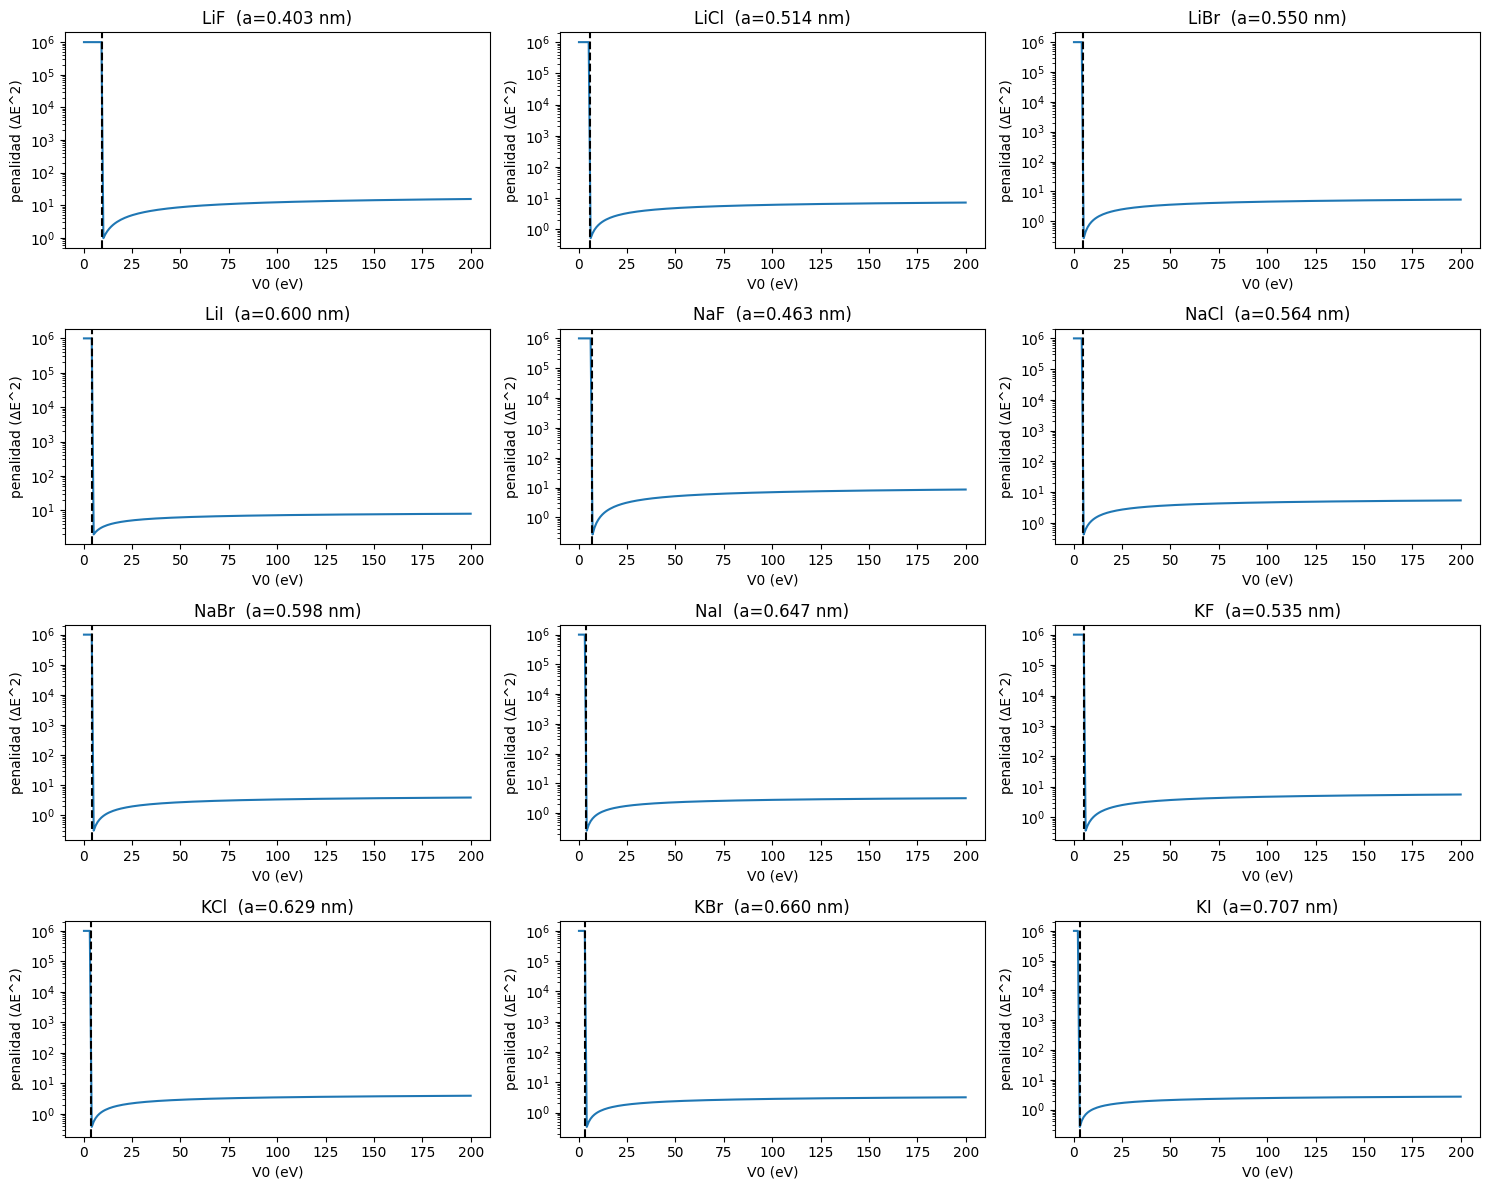

Guardado -> V0_results_by_compound.csv


In [ ]:
# Colab-ready: ajuste de V0 para pozo esférico finito (l=0 → siguiente l=0)
# Requiere: numpy, scipy, matplotlib, pandas
# Ejecutar en Google Colab

import numpy as np
import pandas as pd
from scipy.optimize import brentq, minimize_scalar
import matplotlib.pyplot as plt

# ---------- CONSTANTES ----------
hbar = 1.054571817e-34      # J s
m_e = 9.10938356e-31        # kg
eV2J = 1.602176634e-19      # J / eV

# ---------- DATOS ----------
data = [
    ("LiF", 0.4028, 5.083),
    ("LiCl", 0.5140, 3.256),
    ("LiBr", 0.5502, 2.767),
    ("LiI", 0.6000, 3.176),
    ("NaF", 0.4634, 3.702),
    ("NaCl", 0.5640, 2.746),
    ("NaBr", 0.5978, 2.345),
    ("NaI", 0.6474, 2.063),
    ("KF",   0.5348, 2.873),
    ("KCl",  0.6294, 2.295),
    ("KBr",  0.6596, 2.059),
    ("KI",   0.7066, 1.874),
]
df = pd.DataFrame(data, columns=["compound","a_nm","E_exp_eV"])

# ---------- RADIO EFECTIVO ----------
R_choice = "a/2"  # cambiar a "a/sqrt2" o "0.335*a" si querés probar

def a_nm_to_R_m(a_nm, choice="a/2"):
    a_m = a_nm * 1e-9
    if choice == "a/2":
        return a_m/2.0
    elif choice == "a/sqrt2":
        return a_m/np.sqrt(2.0)
    elif choice == "0.335*a":
        return 0.335*a_m
    else:
        raise ValueError("choice unknown")

# ---------- ECUACIÓN DE CONTORNO l=0 ----------
# Condición: -ε cot(ε) = sqrt(delta - ε^2)
def f0(eps, delta):
    return -eps * (np.cos(eps)/np.sin(eps)) - np.sqrt(delta - eps**2)

def roots_l0(V0_eV, R_m, n_roots=2, scan_eps_max=50.0):
    V0 = V0_eV*eV2J
    delta = (2*m_e*V0*R_m**2)/hbar**2
    if delta <= 0:
        return []
    eps_max = min(np.sqrt(delta)-1e-8, scan_eps_max)
    if eps_max <= 1e-6:
        return []
    eps_grid = np.linspace(1e-6, eps_max, 5000)
    vals = f0(eps_grid, delta)
    roots = []
    for i in range(len(eps_grid)-1):
        fa, fb = vals[i], vals[i+1]
        if np.isnan(fa) or np.isnan(fb):
            continue
        if fa*fb < 0:
            try:
                root = brentq(f0, eps_grid[i], eps_grid[i+1], args=(delta,), maxiter=200)
                roots.append(root)
                if len(roots) >= n_roots:
                    break
            except Exception:
                continue
    return roots

# ---------- ENERGÍA ----------
def energy_from_eps(eps, R_m):
    return (hbar**2 * eps**2) / (2*m_e*R_m**2) / eV2J

# ---------- SALTO ΔE ----------
def deltaE_model_for_V0(V0_eV, a_nm, R_choice_local=R_choice):
    R_m = a_nm_to_R_m(a_nm, R_choice_local)
    roots = roots_l0(V0_eV, R_m, n_roots=2)
    if len(roots) < 2:
        return None
    E0 = energy_from_eps(roots[0], R_m)
    E1 = energy_from_eps(roots[1], R_m)
    return E1 - E0

def penalty_for_V0(V0_eV, a_nm, E_exp_eV, R_choice_local=R_choice):
    val = deltaE_model_for_V0(V0_eV, a_nm, R_choice_local)
    if val is None or not np.isfinite(val):
        return 1e6
    return (val - E_exp_eV)**2

# ---------- OPTIMIZACIÓN ----------
results = []
V0_search_bounds = (0.1, 200.0)   # ampliar rango si hace falta
for _, row in df.iterrows():
    comp, a_nm, E_exp = row
    res = minimize_scalar(lambda V: penalty_for_V0(V, a_nm, E_exp, R_choice),
                          bounds=V0_search_bounds, method='bounded')
    V0_opt = res.x
    chi2 = res.fun
    deltaE_teo = deltaE_model_for_V0(V0_opt, a_nm, R_choice)
    results.append({
        "compound": comp,
        "a_nm": a_nm,
        "E_exp_eV": E_exp,
        "V0_opt_eV": V0_opt,
        "chi2": chi2,
        "DeltaE_teo_eV": deltaE_teo
    })
    print(f"{comp:6s} | a={a_nm:.4f} nm | E_exp={E_exp:.3f} eV -> "
          f"V0_opt={V0_opt:.3f} eV | DeltaE_teo={deltaE_teo:.3f}")

results_df = pd.DataFrame(results)
display(results_df)

# ---------- GRAFICOS ----------
to_plot = df['compound'].tolist()
nplots = len(to_plot)
cols = 3
rows = int(np.ceil(nplots/cols))
fig = plt.figure(figsize=(5*cols, 3*rows))
for i, comp in enumerate(to_plot):
    ax = fig.add_subplot(rows, cols, i+1)
    row = df[df['compound']==comp].iloc[0]
    a_nm, E_exp = row['a_nm'], row['E_exp_eV']
    Vgrid = np.linspace(V0_search_bounds[0], V0_search_bounds[1], 200)
    pen = [penalty_for_V0(V, a_nm, E_exp, R_choice) for V in Vgrid]
    ax.plot(Vgrid, pen)
    V_opt = results_df[results_df['compound']==comp]['V0_opt_eV'].values[0]
    ax.axvline(V_opt, color='k', linestyle='--')
    ax.set_title(f"{comp}  (a={a_nm:.3f} nm)")
    ax.set_xlabel("V0 (eV)"); ax.set_ylabel("penalidad (ΔE^2)")
    ax.set_yscale('log')
plt.tight_layout()
plt.show()

# ---------- Export ----------
results_df.to_csv("V0_results_by_compound.csv", index=False)
print("Guardado -> V0_results_by_compound.csv")


# Magdalena

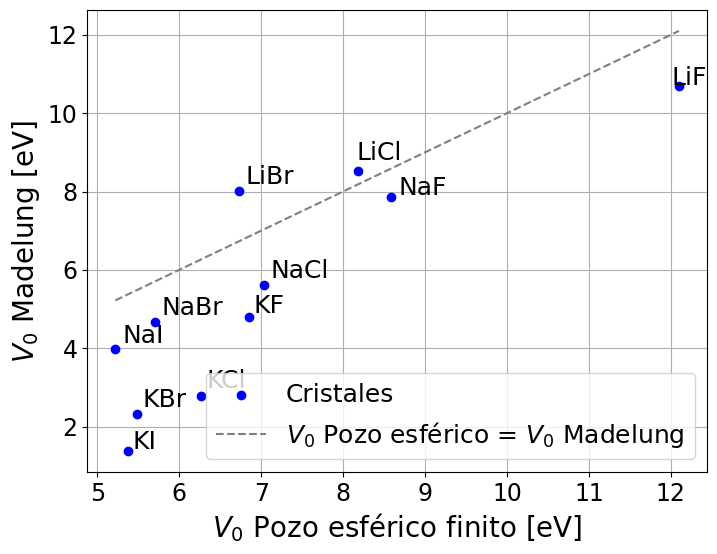

Cristal		V0 FSW [eV]	V0 Madelung [eV]	Diferencia [eV]
-----------------------------------------------------------------
LiF		12.100		10.689		-1.411
LiCl		8.180		8.534		+0.354
LiBr		6.730		8.017		+1.287
NaF		8.580		7.856		-0.724
NaCl		7.040		5.601		-1.439
NaBr		5.710		4.673		-1.037
NaI		5.220		3.979		-1.241
KF		6.850		4.800		-2.050
KCl		6.260		2.787		-3.473
KBr		5.480		2.309		-3.171
KI		5.380		1.377		-4.003


In [ ]:
# Con los rhos del Kittel

import numpy as np
import matplotlib.pyplot as plt
from adjustText import adjust_text

# Constantes para Madelung
alpha_madelung_fcc = 1.74756
q = 1.0   # carga elemental (en unidades e)
epsilon_0 = 55.26349406e-3  # e^2 / (eV·nm)

# Datos exactos de FSW y constantes de red
crystals = [
    "LiF", "LiCl", "LiBr",
    "NaF", "NaCl", "NaBr", "NaI",
    "KF", "KCl", "KBr", "KI"
]

v0_fsw = np.array([
    12.1, 8.18, 6.73,
    8.58, 7.04, 5.71, 5.22,
    6.85, 6.26, 5.48, 5.38,
])

# Constantes de red exactas [nm]
a_nm = np.array([
    0.4028, 0.514, 0.5502,    # LiF, LiCl, LiBr
    0.4634, 0.564, 0.5978, 0.6474,   # NaF, NaCl, NaBr, NaI
    0.5348, 0.6294, 0.6596, 0.7066,  # KF, KCl, KBr, KI
])

# Valores de rho (Kittel)

rho_nm = 0.1*np.array([0.291, 0.33, 0.34,
                   0.641, 1.05, 1.33, 1.58,
                   1.31, 2.05, 2.3, 2.85])

# Calcular V0 Madelung con r = a/2 y un término repulsivo simple
def get_v0_madelung(a, rho: float) -> float:
    r = a / 2
    return alpha_madelung_fcc * q**2 / (4 * np.pi * epsilon_0 * r) * (1 - rho / r)

v0_madelung = np.array([get_v0_madelung(a_nm[i], rho_nm[i]) for i in range(len(a_nm))])

# --- Graficar ---
plt.figure(figsize=(8, 6))
plt.scatter(v0_fsw, v0_madelung, color="blue", zorder=3, label="Cristales")

# Etiquetas
labels = []
for i, crystal in enumerate(crystals):
    labels.append(plt.text(v0_fsw[i], v0_madelung[i], crystal, ha="left", fontsize=18))
adjust_text(labels, expand=(1.3, 1.3))

# Recta y=x
x_vals = np.linspace(min(v0_fsw), max(v0_fsw), 100)
plt.plot(x_vals, x_vals, "--", color="gray", label="$V_0$ Pozo esférico = $V_0$ Madelung")

plt.xticks(fontsize=17)
plt.yticks(fontsize=17)
plt.xlabel("$V_0$ Pozo esférico finito [eV]", fontsize= 20)
plt.ylabel("$V_0$ Madelung [eV]", fontsize= 20)
#plt.title("Comparación: $V_0$ FSW vs $V_0$ Madelung (con constantes de red exactas)")
plt.legend(fontsize= 18)
plt.grid(True)

# Guardar en el directorio actual
plt.savefig("v0_fsw_vs_v0_madelung_exact.pdf", dpi=300, bbox_inches='tight')
plt.show()

# Mostrar valores calculados
print("Cristal\t\tV0 FSW [eV]\tV0 Madelung [eV]\tDiferencia [eV]")
print("-" * 65)
for i, crystal in enumerate(crystals):
    diff = v0_madelung[i] - v0_fsw[i]
    print(f"{crystal}\t\t{v0_fsw[i]:.3f}\t\t{v0_madelung[i]:.3f}\t\t{diff:+.3f}")

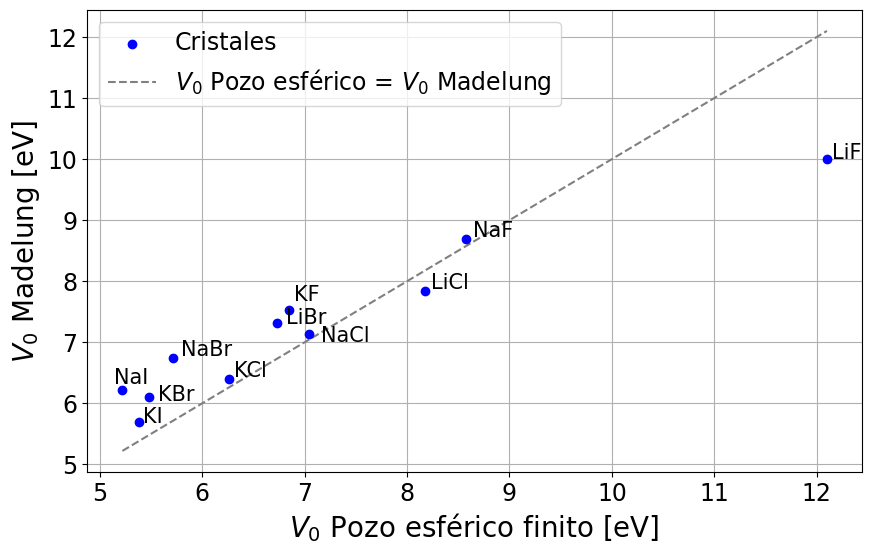

Cristal		V0 FSW [eV]	V0 Madelung [eV]	Diferencia [eV]
-----------------------------------------------------------------
LiF		12.100		9.996		-2.104
LiCl		8.180		7.833		-0.347
LiBr		6.730		7.318		+0.588
NaF		8.580		8.689		+0.109
NaCl		7.040		7.139		+0.099
NaBr		5.710		6.735		+1.025
NaI		5.220		6.219		+0.999
KF		6.850		7.529		+0.679
KCl		6.260		6.397		+0.137
KBr		5.480		6.104		+0.624
KI		5.380		5.698		+0.318


In [ ]:
# Con rho = 0.1*a

import numpy as np
import matplotlib.pyplot as plt
from adjustText import adjust_text

# Constantes para Madelung
alpha_madelung_fcc = 1.74756
q = 1.0   # carga elemental (en unidades e)
epsilon_0 = 55.26349406e-3  # e^2 / (eV·nm)

# Datos exactos de FSW y constantes de red
crystals = [
    "LiF", "LiCl", "LiBr",
    "NaF", "NaCl", "NaBr", "NaI",
    "KF", "KCl", "KBr", "KI"
]

v0_fsw = np.array([
    12.1, 8.18, 6.73,
    8.58, 7.04, 5.71, 5.22,
    6.85, 6.26, 5.48, 5.38,
])

# Constantes de red exactas [nm]
a_nm = np.array([
    0.4028, 0.514, 0.5502,    # LiF, LiCl, LiBr
    0.4634, 0.564, 0.5978, 0.6474,   # NaF, NaCl, NaBr, NaI
    0.5348, 0.6294, 0.6596, 0.7066,  # KF, KCl, KBr, KI
])

# Calcular V0 Madelung con r = a/2 y un término repulsivo simple
def get_v0_madelung(a: float) -> float:
    r = a / 2
    rho = 0.1 * a
    return alpha_madelung_fcc * q**2 / (4 * np.pi * epsilon_0 * r) * (1 - rho / r)

v0_madelung = np.array([get_v0_madelung(a) for a in a_nm])

# --- Graficar ---
plt.figure(figsize=(10, 6))
plt.scatter(v0_fsw, v0_madelung, color="blue", zorder=3, label="Cristales")

# Etiquetas
labels = []
for i, crystal in enumerate(crystals):
    labels.append(plt.text(v0_fsw[i], v0_madelung[i], crystal, ha="left", fontsize=15))
adjust_text(labels, expand=(1.3, 1.3))

# Recta y=x
x_vals = np.linspace(min(v0_fsw), max(v0_fsw), 100)
plt.plot(x_vals, x_vals, "--", color="gray", label="$V_0$ Pozo esférico = $V_0$ Madelung")

plt.xticks(fontsize=17)
plt.yticks(fontsize=17)
plt.xlabel("$V_0$ Pozo esférico finito [eV]", fontsize= 20)
plt.ylabel("$V_0$ Madelung [eV]", fontsize= 20)
#plt.title("Comparación: $V_0$ FSW vs $V_0$ Madelung (con constantes de red exactas)")
plt.legend(fontsize=17)
plt.grid(True)

# Guardar en el directorio actual
plt.savefig("v0_fsw_vs_v0_madelung.pdf", dpi=300, bbox_inches='tight')
plt.show()

# Mostrar valores calculados
print("Cristal\t\tV0 FSW [eV]\tV0 Madelung [eV]\tDiferencia [eV]")
print("-" * 65)
for i, crystal in enumerate(crystals):
    diff = v0_madelung[i] - v0_fsw[i]
    print(f"{crystal}\t\t{v0_fsw[i]:.3f}\t\t{v0_madelung[i]:.3f}\t\t{diff:+.3f}")